# **COMPREHENSIVE MODEL TRAINING WITH BALANCED DATA**


## **0. Library import**

This section imports all necessary libraries and modules for comprehensive model training with balanced data. The imports include:

- **Data Processing**: pandas for data manipulation and NumPy for numerical operations
- **Scikit-learn**: MinMaxScaler for feature normalization and various evaluation metrics
- **Custom Modules**: Our project-specific modules for configuration, data utilities, visualization, evaluation, and model implementations
- **Machine Learning Models**: Six different algorithms including SGD, Logistic Regression, Random Forest, Naive Bayes, XGBoost, and LightGBM

The configuration imports contain all hyperparameters and file paths needed for consistent model training across all balancing methods.


In [1]:
import os
import sys

# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [99]:
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from src.config import LOG_DIR, \
    RANDOM_OVER_SAMPLING_DATA_FILE_PATH, SMOTE_DATA_FILE_PATH, ADASYN_DATA_FILE_PATH, \
    RANDOM_UNDER_SAMPLING_DATA_FILE_PATH, TOMEK_LINKS_DATA_FILE_PATH, EDITED_NEIGHBORS_DATA_FILE_PATH, \
    SMOTE_TOMEK_LINKS_DATA_FILE_PATH, SMOTE_ENN_DATA_FILE_PATH, ADASYN_TOMEK_DATA_FILE_PATH, \
    TESTING_DATA_FILE_PATH, RANDOM_STATE, N_JOBS, \
    SGD_ALPHA, SGD_MAX_ITER, SGD_LOSS, SGD_PENALTY, SGD_LEARNING_RATE, \
    LR_C, LR_PENALTY, LR_CLASS_WEIGHT, LR_VERBOSE, LR_MAX_ITER, LR_SOLVER, \
    RF_N_ESTIMATORS, RF_MAX_DEPTH, RF_MIN_SAMPLES_SPLIT, RF_MIN_SAMPLES_LEAF, RF_CLASS_WEIGHT, \
    NB_ALPHA, NB_TYPE, NB_BINARIZE, NB_VAR_SMOOTHING, \
    XGB_N_ESTIMATORS, XGB_MAX_DEPTH, XGB_LEARNING_RATE, XGB_SUBSAMPLE, XGB_COLSAMPLE_BY_TREE, \
    LGBM_N_ESTIMATORS, LGBM_MAX_DEPTH, LGBM_LEARNING_RATE, LGBM_NUM_LEAVES, LGBM_SUBSAMPLE, LGBM_COLSAMPLE_BY_TREE, \
    BEST_ACCURACY_MODEL_FILE_PATH, BEST_ACCURACY_MODEL_SCALER_FILE_PATH, \
    BEST_F1_MODEL_FILE_PATH, BEST_F1_MODEL_SCALER_FILE_PATH, \
    BEST_PRECISION_MODEL_FILE_PATH, BEST_PRECISION_MODEL_SCALER_FILE_PATH, \
    BEST_RECALL_MODEL_FILE_PATH, BEST_RECALL_MODEL_SCALER_FILE_PATH
from src.utils import load_data, save_data
from src.visualization import plot_roc_auc, plot_compare_models
from src.evaluate import compare_models
from src.models import (
    DiabetesSGDClassifier, DiabetesLogisticRegression, 
    DiabetesRandomForest, DiabetesNaiveBayes, 
    DiabetesXGBoostClassifier, DiabetesLightGBMClassifier
)

## **1. Data preparation**

This comprehensive section prepares all balanced datasets created in the previous notebook for model training. We load nine different balanced datasets, each representing a different approach to addressing class imbalance in the diabetes prediction problem.

The preparation process includes:
1. **Loading balanced datasets**: Nine variants created using different balancing techniques
2. **Feature-target separation**: Extracting features (X) and target variables (y) for each dataset
3. **Feature normalization**: Applying MinMaxScaler to ensure all features are on the same scale
4. **Test data preparation**: Ensuring consistent preprocessing across all methods

This standardized preparation ensures fair comparison across all balancing methods and machine learning algorithms.

### **1.1 Load balanced datasets**

Loading all nine balanced datasets created in the data balancing notebook:

**Oversampling Methods:**
- **Random Oversampling**: Simple duplication of minority class samples
- **SMOTE**: Synthetic sample generation using k-nearest neighbors
- **ADASYN**: Adaptive synthetic sampling focused on difficult-to-learn regions

**Undersampling Methods:**
- **Random Undersampling**: Random removal of majority class samples
- **Tomek Links**: Intelligent removal of boundary samples
- **Edited Nearest Neighbors**: Removal of noisy samples from all classes

**Hybrid Methods:**
- **SMOTE + Tomek**: Combines synthetic generation with boundary cleaning
- **SMOTE + ENN**: Combines synthetic generation with comprehensive noise removal
- **ADASYN + Tomek**: Adaptive generation with boundary cleaning

Each dataset represents a different strategy for handling the original class imbalance of approximately 82% No Diabetes, 2% Pre-diabetes, and 16% Diabetes.

In [3]:
# Load all 6 balanced datasets
ros_data = load_data(path=RANDOM_OVER_SAMPLING_DATA_FILE_PATH)
smote_data = load_data(path=SMOTE_DATA_FILE_PATH)
adasyn_data = load_data(path=ADASYN_DATA_FILE_PATH)
rus_data = load_data(path=RANDOM_UNDER_SAMPLING_DATA_FILE_PATH)
tomek_data = load_data(path=TOMEK_LINKS_DATA_FILE_PATH)
enn_data = load_data(path=EDITED_NEIGHBORS_DATA_FILE_PATH)
smote_tomek_data = load_data(path=SMOTE_TOMEK_LINKS_DATA_FILE_PATH)
smote_enn_data = load_data(path=SMOTE_ENN_DATA_FILE_PATH)
adasyn_tomek_data = load_data(path=ADASYN_TOMEK_DATA_FILE_PATH)

### **1.2 Split features and target**

Separating features (X) and target variables (y) for each of the nine balanced datasets. This step is crucial for:

- **Consistent Structure**: Ensuring all datasets follow the same format for downstream processing
- **Model Training**: Preparing data in the format expected by scikit-learn algorithms
- **Memory Efficiency**: Organizing data for optimal memory usage during training

Each dataset maintains the same feature structure (22 engineered features) but with different class distributions based on the balancing method applied. The target variable remains the three-class diabetes classification: 0 (No Diabetes), 1 (Pre-diabetes), 2 (Diabetes).

In [4]:
# Split features and target of each dataset
# Random Oversampling
ros_X_train = ros_data["X"]
ros_y_train = ros_data["y"]
# SMOTE
smote_X_train = smote_data["X"]
smote_y_train = smote_data["y"]
# ADASYN
adasyn_X_train = adasyn_data["X"]
adasyn_y_train = adasyn_data["y"]
# Random Undersampling
rus_X_train = rus_data["X"]
rus_y_train = rus_data["y"]
# Tomek Links
tomek_X_train = tomek_data["X"]
tomek_y_train = tomek_data["y"]
# Edited Nearest Neighbors
enn_X_train = enn_data["X"]
enn_y_train = enn_data["y"]
# SMOTE + Tomek Links
smote_tomek_X_train = smote_tomek_data["X"]
smote_tomek_y_train = smote_tomek_data["y"]
# SMOTE + ENN
smote_enn_X_train = smote_enn_data["X"]
smote_enn_y_train = smote_enn_data["y"]
# ADASYN + Tomek Links
adasyn_tomek_X_train = adasyn_tomek_data["X"]
adasyn_tomek_y_train = adasyn_tomek_data["y"]

### **1.3 Normalize features for each dataset**

Feature normalization is critical for machine learning algorithms, especially those sensitive to feature scales like SGD and Logistic Regression. We apply MinMaxScaler to transform all features to the range [0, 1].

**Why separate scalers for each dataset?**
- **Data Distribution Differences**: Each balancing method changes the underlying data distribution
- **Prevent Data Leakage**: Each scaler is fitted only on its respective training data
- **Consistent Scaling**: Ensures test data is transformed using the same scaling parameters

**Benefits of MinMaxScaler:**
- **Bounded Range**: All features scaled to [0, 1] range
- **Preserves Relationships**: Maintains relative distances between samples
- **Algorithm Compatibility**: Optimal for neural networks and distance-based algorithms
- **Interpretability**: Scaled values remain intuitive and comparable

This approach ensures that each balanced dataset maintains its unique characteristics while being appropriately preprocessed for machine learning algorithms.

In [5]:
# Initialize MinMaxScaler for each dataset
ros_scaler = MinMaxScaler()
smote_scaler = MinMaxScaler()
adasyn_scaler = MinMaxScaler()
rus_scaler = MinMaxScaler()
tomek_scaler = MinMaxScaler()
enn_scaler = MinMaxScaler()
smote_tomek_scaler = MinMaxScaler()
smote_enn_scaler = MinMaxScaler()
adasyn_tomek_scaler = MinMaxScaler()

In [6]:
# Transform training dataset
ros_X_train_scaled = ros_scaler.fit_transform(ros_X_train)
smote_X_train_scaled = smote_scaler.fit_transform(smote_X_train)
adasyn_X_train_scaled = adasyn_scaler.fit_transform(adasyn_X_train)
rus_X_train_scaled = rus_scaler.fit_transform(rus_X_train)
tomek_X_train_scaled = tomek_scaler.fit_transform(tomek_X_train)
enn_X_train_scaled = enn_scaler.fit_transform(enn_X_train)
smote_tomek_X_train_scaled = smote_tomek_scaler.fit_transform(smote_tomek_X_train)
smote_enn_X_train_scaled = smote_enn_scaler.fit_transform(smote_enn_X_train)
adasyn_tomek_X_train_scaled = adasyn_tomek_scaler.fit_transform(adasyn_tomek_X_train)

### **1.4 Prepare test data**

Loading and preparing the test dataset that remains consistent across all experiments. This test set was created during the data balancing phase and represents the original class distribution for unbiased evaluation.

**Key characteristics:**
- **Untouched Data**: Never used during balancing or training phases
- **Original Distribution**: Maintains real-world class imbalance for realistic evaluation
- **Consistent Evaluation**: Same test set used for all 54 model combinations (9 balancing × 6 algorithms)

**Scaling Application:**
Each balanced dataset's scaler is applied to the test data to ensure consistency between training and testing transformations. This prevents scaling-related performance issues and ensures fair comparison across all methods.

The test data serves as our ground truth for evaluating how well each balancing method helps models generalize to real-world data with natural class distribution.

In [7]:
# Load data
test_data = load_data(path=TESTING_DATA_FILE_PATH)

# Get testing features and target
X_test = test_data["X"]
y_test = test_data["y"]

In [8]:
# Apply normalization on test data
ros_X_test_scaled = ros_scaler.transform(X_test)
smote_X_test_scaled = smote_scaler.transform(X_test)
adasyn_X_test_scaled = adasyn_scaler.transform(X_test)
rus_X_test_scaled = rus_scaler.transform(X_test)
tomek_X_test_scaled = tomek_scaler.transform(X_test)
enn_X_test_scaled = enn_scaler.transform(X_test)
smote_tomek_X_test_scaled = smote_tomek_scaler.transform(X_test)
smote_enn_X_test_scaled = smote_enn_scaler.transform(X_test)
adasyn_tomek_X_test_scaled = adasyn_tomek_scaler.transform(X_test)

## **2. Model training by balancing method**

This section implements comprehensive model training using six different machine learning algorithms on nine balanced datasets, resulting in 54 unique model configurations. Each configuration is evaluated using multiple metrics to understand the impact of different balancing strategies.

**Training Strategy:**
- **Systematic Approach**: Same six algorithms applied to each balanced dataset
- **Consistent Hyperparameters**: All models use pre-optimized hyperparameters for fair comparison
- **Comprehensive Evaluation**: Each model evaluated using accuracy, precision, recall, F1-score, and AUC
- **Cross-validation**: 5-fold cross-validation provides robust performance estimates
- **ROC Analysis**: ROC curves visualize model discrimination capability

**Six Machine Learning Algorithms:**
1. **SGD Classifier**: Fast linear classifier suitable for large datasets
2. **Logistic Regression**: Interpretable probabilistic classifier
3. **Naive Bayes**: Simple probabilistic classifier with strong independence assumptions
4. **Random Forest**: Ensemble method robust to overfitting
5. **XGBoost**: Gradient boosting with advanced regularization
6. **LightGBM**: Efficient gradient boosting optimized for speed and memory

Each model is trained and evaluated systematically to identify the optimal combination of balancing method and algorithm for diabetes prediction.

In [9]:
def train_evaluate_all_models(X_train, y_train, X_test, y_test, method_name):
    """
    Train and evaluate all 4 models on the given balanced dataset

    Parameters:
        X_train (np.ndarray): Training features
        y_train (np.ndarray): Training target
        X_test (np.ndarray): Testing features
        y_test (np.ndarray): Testing target
        method_name (str): Name of the balancing method

    Returns:
        results (dict): The evaluation results
        models (dict): The model's names and models
    """
    log_filename = method_name.lower().replace(" ", "_")
    log_filename = log_filename + "_method" if not "_method" in log_filename else log_filename
    log_file_path = f"{LOG_DIR}/5_{log_filename}.log"
    cv_scores = {}
    probabilities = {}

    # Initialize all models
    sgd_model = DiabetesSGDClassifier(
        loss=SGD_LOSS,
        penalty=SGD_PENALTY,
        alpha=SGD_ALPHA,
        max_iter=SGD_MAX_ITER,
        random_state=RANDOM_STATE,
        learning_rate=SGD_LEARNING_RATE,
        n_jobs=N_JOBS,
        log_file=log_file_path,
    )
    lr_model = DiabetesLogisticRegression(
        C=LR_C,
        penalty=LR_PENALTY,
        class_weight=LR_CLASS_WEIGHT,
        max_iter=LR_MAX_ITER,
        solver=LR_SOLVER,
        random_state=RANDOM_STATE,
        verbose=LR_VERBOSE,
        n_jobs=N_JOBS,
        log_file=log_file_path
    )
    nb_model = DiabetesNaiveBayes(
        nb_type=NB_TYPE,
        var_smoothing=NB_VAR_SMOOTHING,
        binarize=NB_BINARIZE,
        alpha=NB_ALPHA,
        log_file=log_file_path,
    )
    rf_model = DiabetesRandomForest(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_split=RF_MIN_SAMPLES_SPLIT,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        class_weight=RF_CLASS_WEIGHT,
        random_state=RANDOM_STATE,
        log_file=log_file_path,
    )
    xgb_model = DiabetesXGBoostClassifier(
        n_estimators=XGB_N_ESTIMATORS, 
        max_depth=XGB_MAX_DEPTH, 
        learning_rate=XGB_LEARNING_RATE, 
        subsample=XGB_SUBSAMPLE, 
        colsample_bytree=XGB_COLSAMPLE_BY_TREE,
        log_file=log_file_path,
    )
    lgbm_model = DiabetesLightGBMClassifier(
        n_estimators=LGBM_N_ESTIMATORS, 
        max_depth=LGBM_MAX_DEPTH, 
        learning_rate=LGBM_LEARNING_RATE, 
        num_leaves=LGBM_NUM_LEAVES, 
        subsample=LGBM_SUBSAMPLE, 
        colsample_bytree=LGBM_COLSAMPLE_BY_TREE,
        log_file=log_file_path, 
    )

    model_dict = {
        "SGDClassifier": sgd_model,
        "LogisticRegression": lr_model,
        "NaiveBayes": nb_model,
        "RandomForest": rf_model,
        "XGBoost": xgb_model, 
        "LightGBM": lgbm_model, 
    }

    # Train and evaluate each model
    for name, model in model_dict.items():
        print(f"Training {name} on {method_name} data...")

        # Train
        model.train(X=X_train, y=y_train)

        # Predict and evaluate
        y_pred = model.predict(X_test)
        model.evaluate(y_test, y_pred)

        # Get class probabilites
        probabilities[name] = model.predict_proba(X_test)

        # Cross-validation
        cv_result = model.cross_validate(X_train, y_train)
        cv_scores[name] = {
            'cv_mean': cv_result.mean(),
            'cv_std': cv_result.std()
        }

    # Get evaluation comparation results
    evaluation_results = compare_models(
        models_dict=model_dict,
        X_test=X_test,
        y_true=y_test
    )

    # Convert cv_scores dict to DataFrame
    cv_df = pd.DataFrame.from_dict(cv_scores, orient='index').reset_index()
    cv_df.columns = ['Model', 'CV Mean', 'CV Std']

    # Merge into evaluation results
    evaluation_results = pd.merge(evaluation_results, cv_df, on='Model', how='left')

    return evaluation_results, probabilities, model_dict

### **2.1 Random Oversampling**

Random Oversampling results demonstrate the baseline performance of the simplest balancing approach. This method duplicates existing minority class samples to achieve balance, increasing dataset size from 562K to 760K samples.

**Expected Characteristics:**
- **Fast Training**: Simple duplication requires minimal computational overhead
- **Potential Overfitting**: Identical duplicates may cause models to memorize rather than generalize
- **Consistent Performance**: Provides stable baseline for comparison with more sophisticated methods

**Key Observations:**
The evaluation results show how different algorithms respond to exact sample duplication. Tree-based models (Random Forest, XGBoost, LightGBM) may be more susceptible to overfitting on duplicated samples, while linear models might show more stable performance.

ROC curves reveal each algorithm's ability to distinguish between the three diabetes classes when trained on duplicated minority samples. This establishes our performance baseline for comparing against synthetic data generation methods.

In [10]:
# Train and get evaluation results with the Random OVersampling method
ros_evaluation_results, ros_class_probabilities, ros_models = train_evaluate_all_models(
    X_train=ros_X_train_scaled, 
    y_train=ros_y_train, 
    X_test=ros_X_test_scaled, 
    y_test=y_test, 
    method_name="Random Oversampling"
)

2025-09-17 22:18:00,998 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 22:18:01,001 - [src.models] - INFO -   loss: log_loss
2025-09-17 22:18:01,005 - [src.models] - INFO -   penalty: l2
2025-09-17 22:18:01,009 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 22:18:01,011 - [src.models] - INFO -   learning_rate: constant
2025-09-17 22:18:01,014 - [src.models] - INFO -   eta0: 0.01
2025-09-17 22:18:01,015 - [src.models] - INFO -   max_iter: 1000
2025-09-17 22:18:01,017 - [src.models] - INFO -   random_state: 42
2025-09-17 22:18:01,020 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 22:18:01,022 - [src.models] - INFO -   C: 1.0
2025-09-17 22:18:01,025 - [src.models] - INFO -   penalty: l2
2025-09-17 22:18:01,028 - [src.models] - INFO -   class_weight: None
2025-09-17 22:18:01,031 - [src.models] - INFO -   solver: saga
2025-09-17 22:18:01,032 - [src.models] - INFO -   max_iter: 100
2025-09-17 22:18:01,034 

Training SGDClassifier on Random Oversampling data...


2025-09-17 22:18:04,563 - [src.models] - INFO - Model training completed. Training samples: 659553
2025-09-17 22:18:04,565 - [src.models] - INFO - Number of iterations: 7
2025-09-17 22:18:04,600 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:18:04,750 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:18:04,754 - [src.models] - INFO - Accuracy: 0.8294
2025-09-17 22:18:04,754 - [src.models] - INFO - Precision: 0.4652
2025-09-17 22:18:04,755 - [src.models] - INFO - Recall: 0.4463
2025-09-17 22:18:04,758 - [src.models] - INFO - F1-Score: 0.4527
2025-09-17 22:18:04,836 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.52      0.40      0.46     22237

    accuracy                           0.83    140504
   macro avg       0.47      0.45      0.45    140504
weighted avg   

Training LogisticRegression on Random Oversampling data...


2025-09-17 22:18:28,470 - [src.models] - INFO - Model training completed. Training samples: 659553
2025-09-17 22:18:28,482 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:18:28,590 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:18:28,593 - [src.models] - INFO - Accuracy: 0.8344
2025-09-17 22:18:28,595 - [src.models] - INFO - Precision: 0.4736
2025-09-17 22:18:28,602 - [src.models] - INFO - Recall: 0.4421
2025-09-17 22:18:28,608 - [src.models] - INFO - F1-Score: 0.4519
2025-09-17 22:18:28,718 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.55      0.38      0.45     22237

    accuracy                           0.83    140504
   macro avg       0.47      0.44      0.45    140504
weighted avg       0.80      0.83      0.81    140504

2025-09-17 22:18:28,788 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 253
[LightGBM] [Info] Number of data points in the train set: 527643, number of used features: 14
[LightGBM] [Info] Start training from score -0.361308
[LightGBM] [Info] Start training from score -2.579540
[LightGBM] [Info] Start training from score -1.480928


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 254
[LightGBM] [Info] Number of data points in the train set: 527643, number of used features: 14
[LightGBM] [Info] Start training from score -0.361308
[LightGBM] [Info] Start training from score -2.579540
[LightGBM] [Info] Start training from score -1.480928


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 22:27:53,796 - [src.models] - INFO - Cross-validation results:
2025-09-17 22:27:53,797 - [src.models] - INFO - Mean accuracy: 0.8181 (+/- 0.0019)
2025-09-17 22:27:53,817 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:27:53,846 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:27:54,111 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:27:54,141 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:27:54,431 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:27:54,475 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:27:57,520 - [src.models] - INFO - Predic

In [11]:
# The evaluation result of all models with the Random Oversampling method
ros_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8294,0.7985,0.4463,0.4527,0.7637,0.8717,1.0000,0.5238,0.9364,0.0000,0.4025,0.9029,0.0000,0.4552,0.747675,0.001667
1,LogisticRegression,0.8344,0.8069,0.4421,0.4519,0.7650,0.8689,1.0000,0.5519,0.9470,0.0000,0.3792,0.9063,0.0000,0.4495,0.745911,0.000794
2,NaiveBayes,0.7708,0.4429,0.4653,0.4472,0.7385,0.8881,0.0526,0.3880,0.8378,0.0192,0.5390,0.8622,0.0282,0.4512,0.707015,0.000665
3,RandomForest,0.7667,0.5042,0.6019,0.5240,0.8464,0.9432,0.0960,0.4733,0.7945,0.3200,0.6913,0.8625,0.1477,0.5619,0.790661,0.005699
4,XGBoost,0.8813,0.7628,0.5701,0.6255,0.8758,0.9004,0.6428,0.7452,0.9720,0.2259,0.5125,0.9348,0.3343,0.6073,0.812770,0.000814
5,LightGBM,0.8833,0.7674,0.5853,0.6401,0.8824,0.9047,0.6594,0.7380,0.9692,0.2510,0.5357,0.9358,0.3636,0.6208,0.818127,0.000937


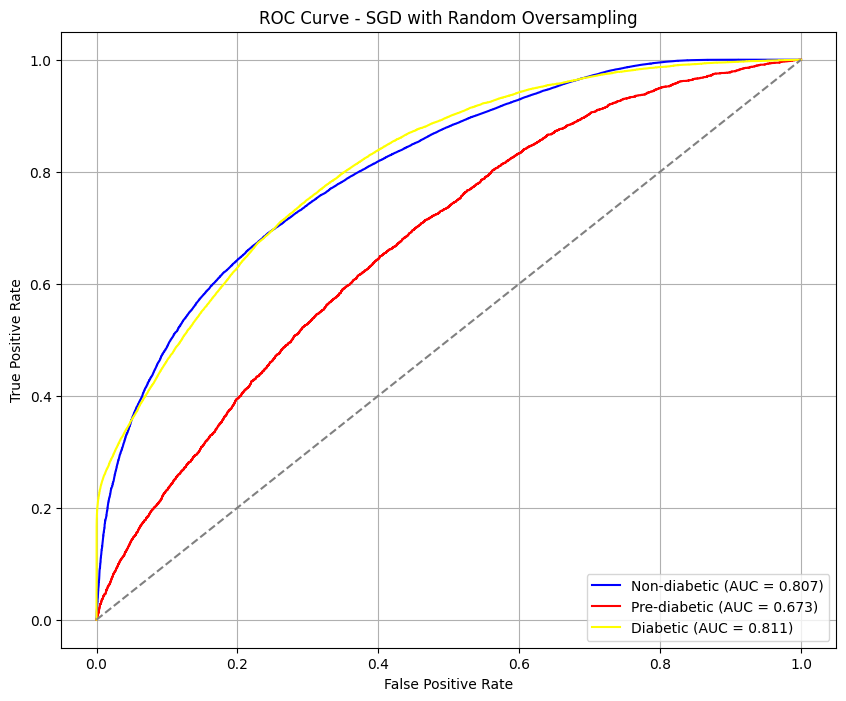

In [12]:
# Plot ROC and AUC of SGD model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["SGDClassifier"],
    model_name="SGD with Random Oversampling"
)

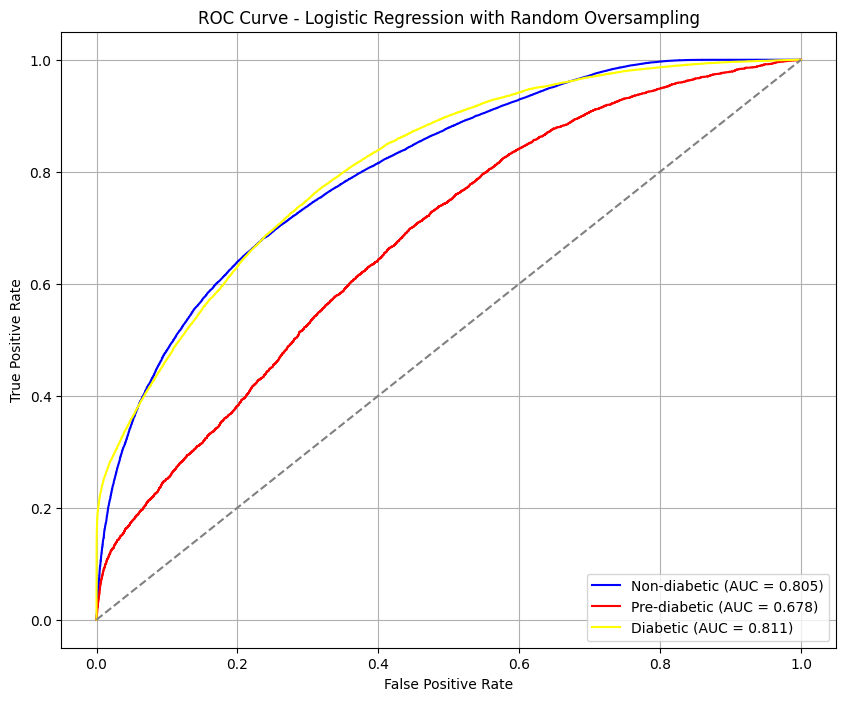

In [13]:
# Plot ROC and AUC of Logistic Regression model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with Random Oversampling"
)

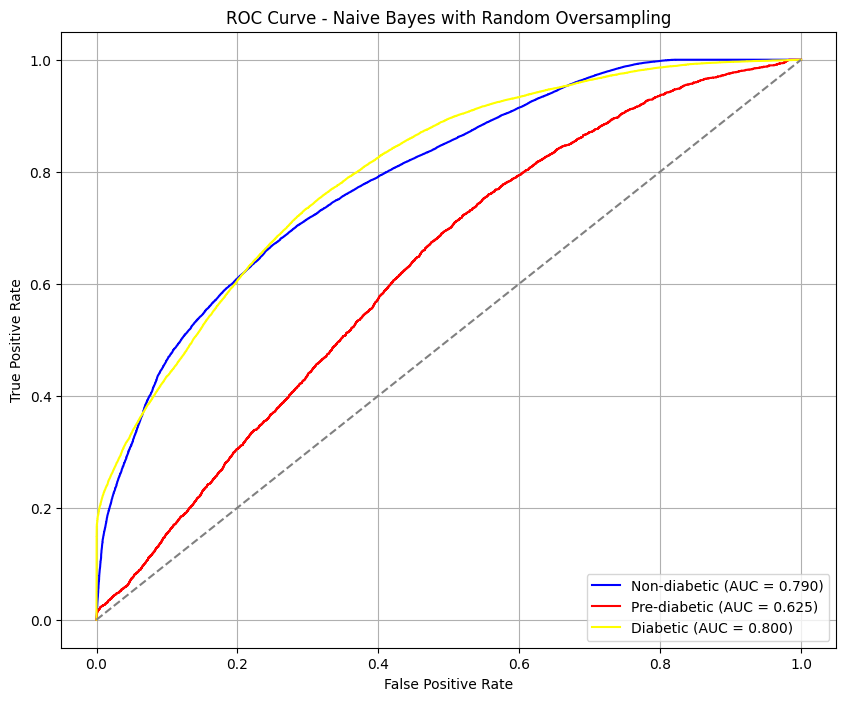

In [14]:
# Plot ROC and AUC of Naive Bayes model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with Random Oversampling"
)

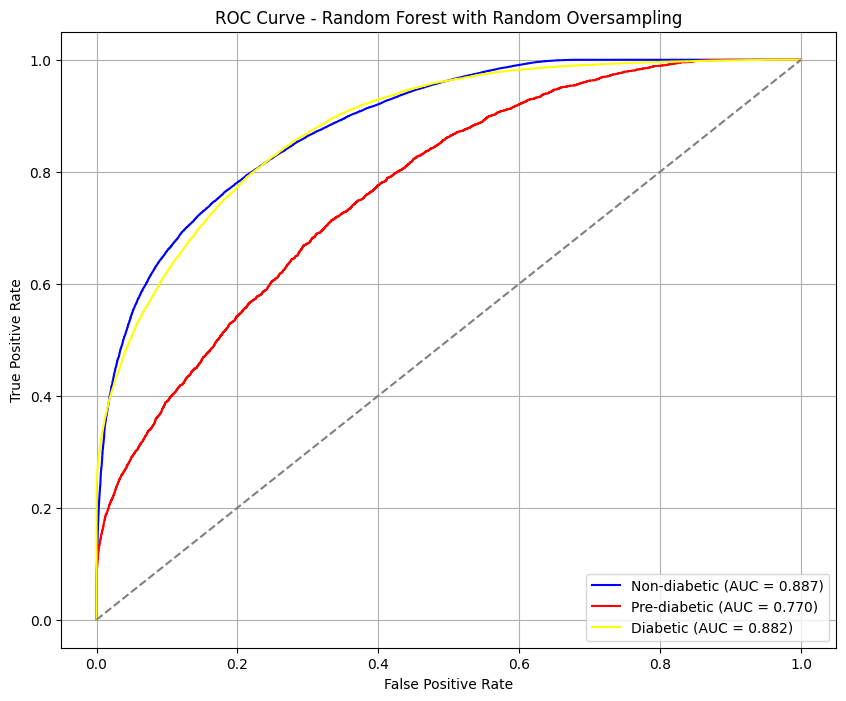

In [15]:
# Plot ROC and AUC of Random Forest model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["RandomForest"],
    model_name="Random Forest with Random Oversampling"
)

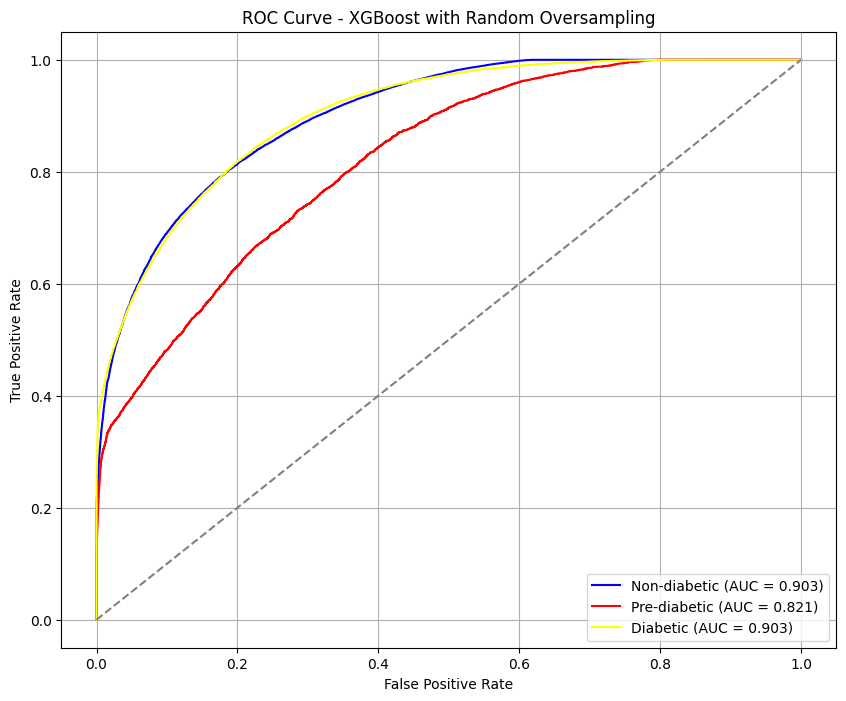

In [16]:
# Plot ROC and AUC of XGBoost model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["XGBoost"],
    model_name="XGBoost with Random Oversampling"
)

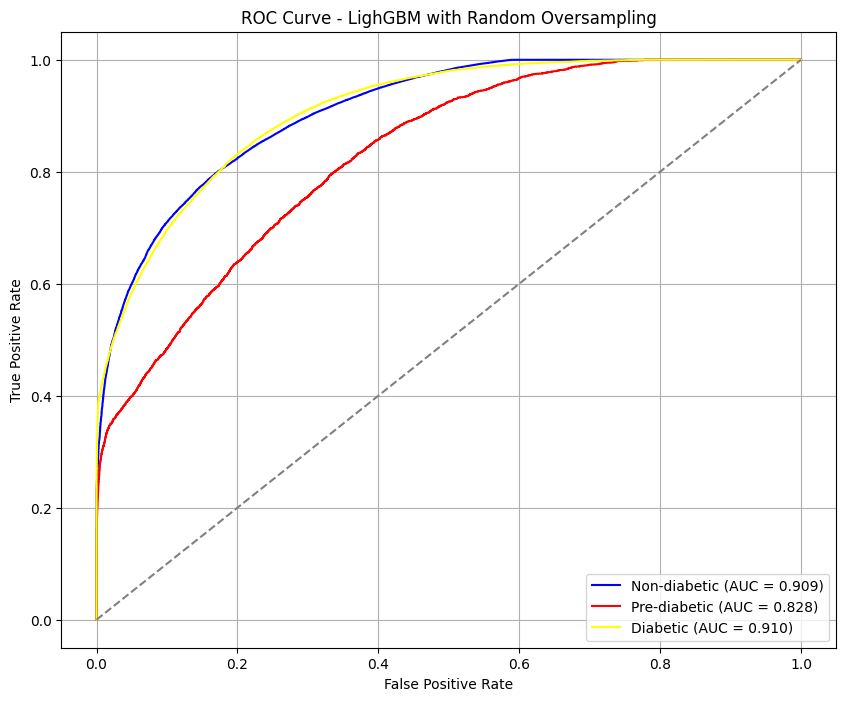

In [17]:
# Plot ROC and AUC of LightGBM model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["LightGBM"],
    model_name="LighGBM with Random Oversampling"
)

### **2.2 SMOTE**

SMOTE (Synthetic Minority Oversampling Technique) represents a significant advancement over random oversampling by generating synthetic samples through interpolation between existing minority class samples and their k-nearest neighbors.

**Key Advantages:**
- **Synthetic Diversity**: Creates new, realistic samples rather than duplicates
- **Reduced Overfitting**: Synthetic samples provide varied training examples
- **Improved Generalization**: Models learn broader patterns rather than memorizing specific cases
- **Medical Relevance**: Generated patient profiles represent plausible health combinations

**Performance Expectations:**
SMOTE typically improves model generalization compared to random oversampling, particularly benefiting algorithms sensitive to overfitting. The synthetic samples help models learn smoother decision boundaries between classes.

**Clinical Interpretation:**
The generated synthetic patients represent realistic combinations of health indicators, helping models understand the continuous spectrum between healthy, pre-diabetic, and diabetic populations. This is particularly valuable for identifying borderline cases in clinical practice.

Results demonstrate whether synthetic sample generation leads to better real-world performance compared to simple duplication strategies.

In [18]:
# Train and get evaluation results with the SMOTE method
smote_evaluation_results, smote_class_probabilities, smote_models = train_evaluate_all_models(
    X_train=smote_X_train_scaled, 
    y_train=smote_y_train, 
    X_test=smote_X_test_scaled, 
    y_test=y_test, 
    method_name="SMOTE"
)

2025-09-17 22:28:05,561 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 22:28:05,561 - [src.models] - INFO -   loss: log_loss
2025-09-17 22:28:05,562 - [src.models] - INFO -   penalty: l2
2025-09-17 22:28:05,563 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 22:28:05,563 - [src.models] - INFO -   learning_rate: constant
2025-09-17 22:28:05,564 - [src.models] - INFO -   eta0: 0.01
2025-09-17 22:28:05,565 - [src.models] - INFO -   max_iter: 1000
2025-09-17 22:28:05,565 - [src.models] - INFO -   random_state: 42
2025-09-17 22:28:05,566 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 22:28:05,567 - [src.models] - INFO -   C: 1.0
2025-09-17 22:28:05,567 - [src.models] - INFO -   penalty: l2
2025-09-17 22:28:05,568 - [src.models] - INFO -   class_weight: None
2025-09-17 22:28:05,569 - [src.models] - INFO -   solver: saga
2025-09-17 22:28:05,570 - [src.models] - INFO -   max_iter: 100
2025-09-17 22:28:05,571 

Training SGDClassifier on SMOTE data...


2025-09-17 22:28:07,616 - [src.models] - INFO - Model training completed. Training samples: 659553
2025-09-17 22:28:07,617 - [src.models] - INFO - Number of iterations: 7
2025-09-17 22:28:07,643 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:28:07,769 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:28:07,770 - [src.models] - INFO - Accuracy: 0.8340
2025-09-17 22:28:07,772 - [src.models] - INFO - Precision: 0.6395
2025-09-17 22:28:07,773 - [src.models] - INFO - Recall: 0.4413
2025-09-17 22:28:07,774 - [src.models] - INFO - F1-Score: 0.4512
2025-09-17 22:28:07,847 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91    114889
         1.0       0.50      0.00      0.00      3378
         2.0       0.55      0.38      0.45     22237

    accuracy                           0.83    140504
   macro avg       0.64      0.44      0.45    140504
weighted avg   

Training LogisticRegression on SMOTE data...


2025-09-17 22:28:24,500 - [src.models] - INFO - Model training completed. Training samples: 659553
2025-09-17 22:28:24,509 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:28:24,558 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:28:24,559 - [src.models] - INFO - Accuracy: 0.8343
2025-09-17 22:28:24,559 - [src.models] - INFO - Precision: 0.4734
2025-09-17 22:28:24,561 - [src.models] - INFO - Recall: 0.4420
2025-09-17 22:28:24,562 - [src.models] - INFO - F1-Score: 0.4518
2025-09-17 22:28:24,611 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.55      0.38      0.45     22237

    accuracy                           0.83    140504
   macro avg       0.47      0.44      0.45    140504
weighted avg       0.80      0.83      0.81    140504

2025-09-17 22:28:24,699 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 527643, number of used features: 14
[LightGBM] [Info] Start training from score -0.361308
[LightGBM] [Info] Start training from score -2.579540
[LightGBM] [Info] Start training from score -1.480928


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023305 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3565
[LightGBM] [Info] Number of data points in the train set: 527643, number of used features: 14
[LightGBM] [Info] Start training from score -0.361308
[LightGBM] [Info] Start training from score -2.579540
[LightGBM] [Info] Start training from score -1.480928


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 22:36:23,064 - [src.models] - INFO - Cross-validation results:
2025-09-17 22:36:23,065 - [src.models] - INFO - Mean accuracy: 0.8477 (+/- 0.0576)
2025-09-17 22:36:23,095 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:36:23,123 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:36:23,391 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:36:23,422 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:36:23,725 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:36:23,767 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:36:26,349 - [src.models] - INFO - Predic

In [19]:
# The evaluation result of all models with the SMOTE method
smote_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8340,0.6395,0.4413,0.4512,0.7616,0.8685,0.5000,0.5501,0.9470,0.0003,0.3765,0.9060,0.0006,0.4471,0.748139,0.000496
1,LogisticRegression,0.8343,0.8067,0.4420,0.4518,0.7640,0.8689,1.0000,0.5513,0.9469,0.0000,0.3791,0.9062,0.0000,0.4493,0.746762,0.000863
2,NaiveBayes,0.7674,0.4426,0.4674,0.4502,0.7364,0.8894,0.0483,0.3900,0.8337,0.0317,0.5368,0.8607,0.0383,0.4518,0.703058,0.001525
3,RandomForest,0.7934,0.5161,0.5908,0.5400,0.8471,0.9379,0.1416,0.4688,0.8256,0.2353,0.7114,0.8782,0.1768,0.5652,0.783898,0.011350
4,XGBoost,0.8807,0.7951,0.5248,0.5749,0.8684,0.8926,0.7153,0.7773,0.9810,0.1146,0.4787,0.9348,0.1975,0.5925,0.824612,0.017866
5,LightGBM,0.8871,0.8532,0.5480,0.6104,0.8786,0.8952,0.8522,0.8123,0.9850,0.1690,0.4900,0.9380,0.2821,0.6113,0.847726,0.028797


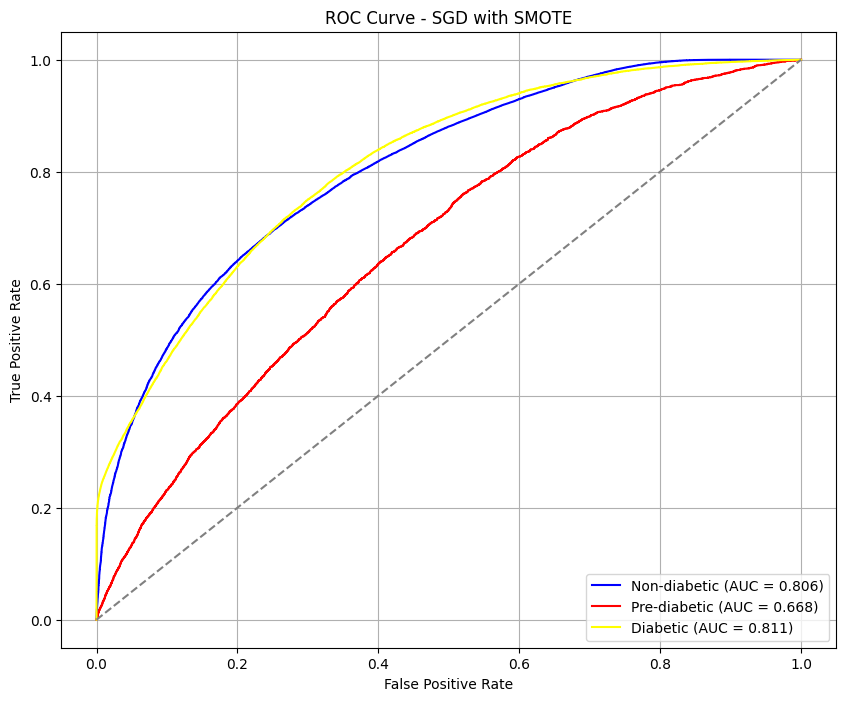

In [20]:
# Plot ROC and AUC of SGD model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["SGDClassifier"],
    model_name="SGD with SMOTE"
)

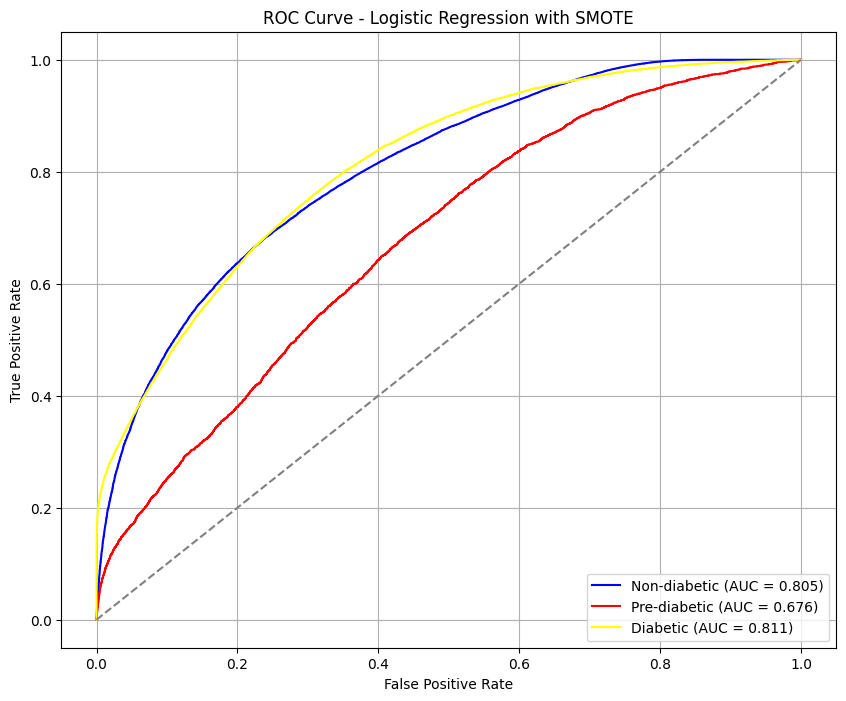

In [21]:
# Plot ROC and AUC of Logistic Regression model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with SMOTE"
)

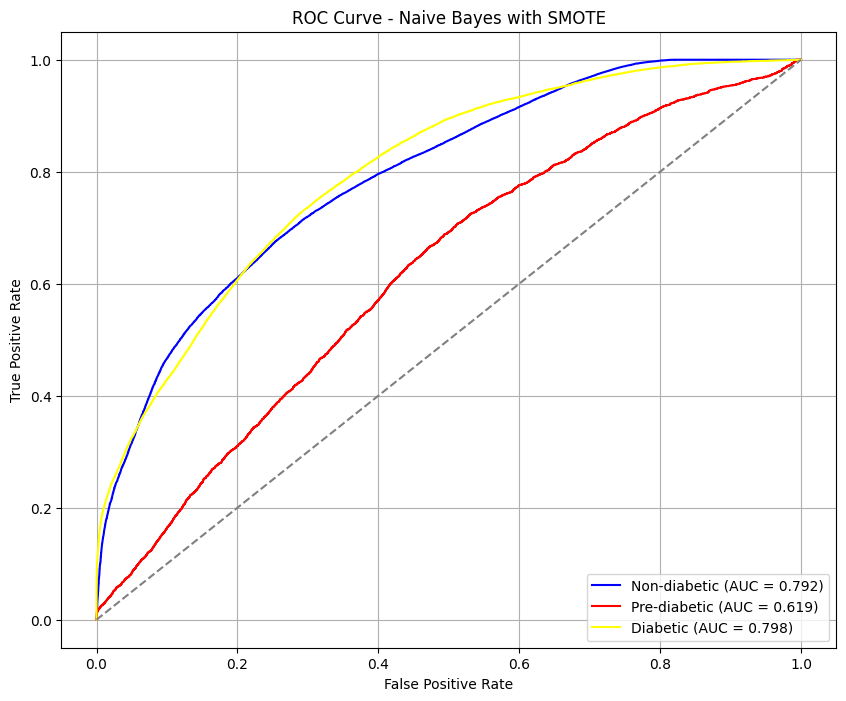

In [22]:
# Plot ROC and AUC of Naive Bayes model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with SMOTE"
)

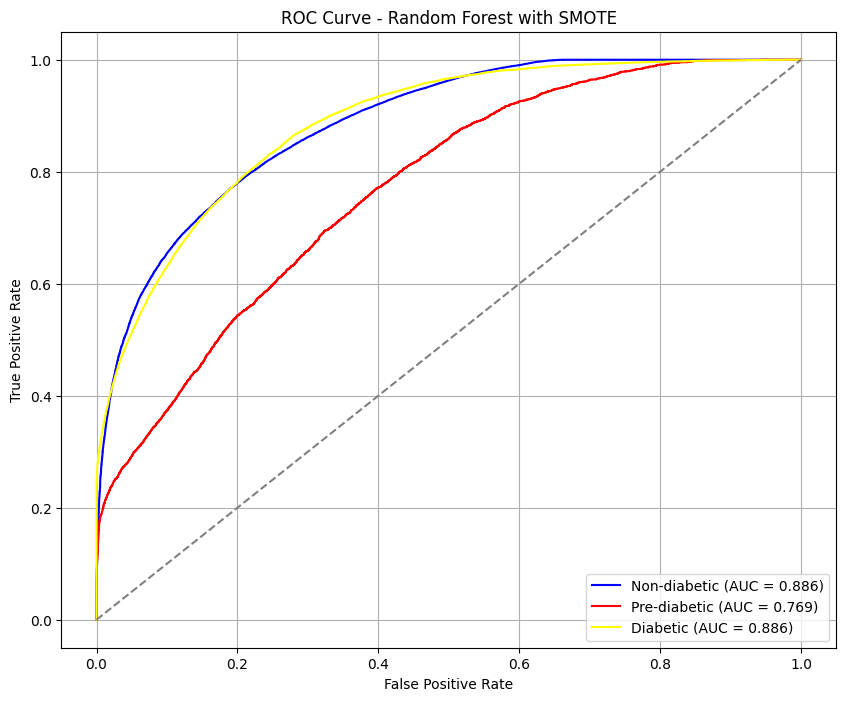

In [23]:
# Plot ROC and AUC of Random Forest model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["RandomForest"],
    model_name="Random Forest with SMOTE"
)

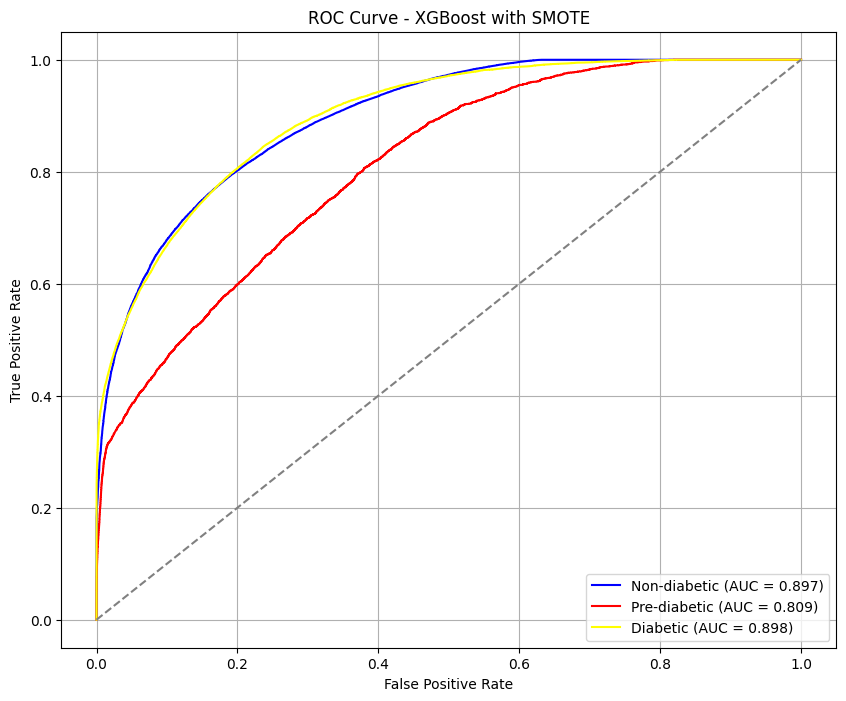

In [24]:
# Plot ROC and AUC of XGBoost model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["XGBoost"],
    model_name="XGBoost with SMOTE"
)

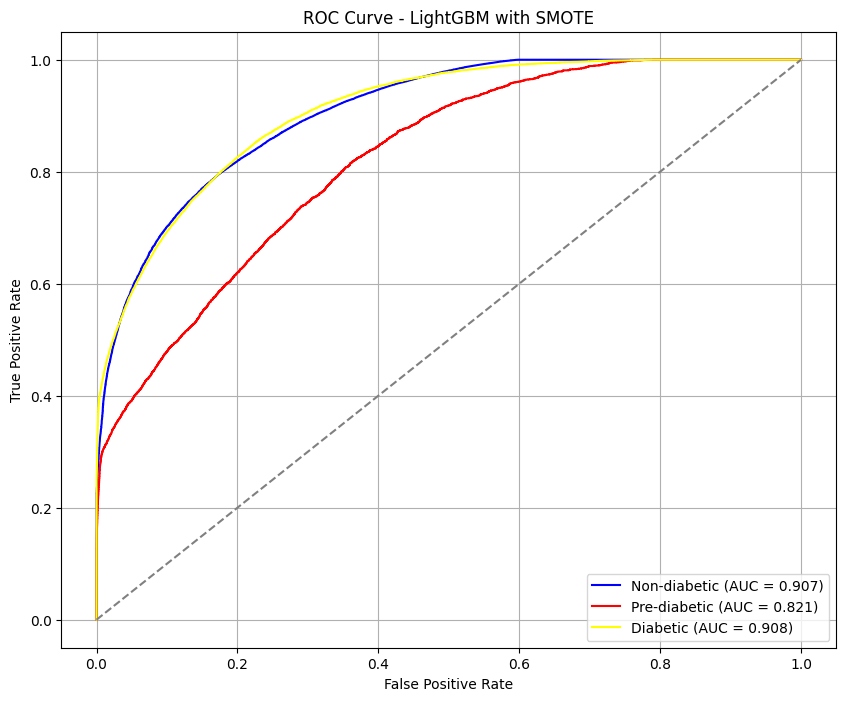

In [25]:
# Plot ROC and AUC of LightGBM model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["LightGBM"],
    model_name="LightGBM with SMOTE"
)

### **2.3 ADASYN**

ADASYN (ADAptive SYNthetic sampling) enhances SMOTE by adaptively generating more synthetic samples in regions where minority class samples are harder to learn, focusing computational resources where they're most needed.

**Adaptive Strategy:**
- **Density-based Generation**: More samples created in sparse minority regions
- **Learning Difficulty Assessment**: Identifies challenging areas based on neighborhood analysis
- **Focused Improvement**: Concentrates on regions most likely to cause misclassification
- **Medical Relevance**: Emphasizes rare but important clinical presentations

**Expected Benefits:**
ADASYN should particularly excel at identifying pre-diabetes cases (the smallest class) by creating more synthetic samples in regions where pre-diabetic patients are isolated among healthy or diabetic populations.

**Clinical Impact:**
This approach is especially valuable for diabetes screening where catching pre-diabetes early can prevent progression to full diabetes. The adaptive generation helps ensure that uncommon but medically significant patient profiles are adequately represented in training data.

Performance evaluation reveals whether the adaptive approach provides meaningful improvements over uniform synthetic generation, particularly for the challenging pre-diabetes classification task.

In [26]:
# Train and get evaluation results with the ADASYN method
adasyn_evaluation_results, adasyn_class_probabilities, adasyn_models = train_evaluate_all_models(
    X_train=adasyn_X_train_scaled, 
    y_train=adasyn_y_train, 
    X_test=adasyn_X_test_scaled, 
    y_test=y_test, 
    method_name="ADASYN"
)

2025-09-17 22:36:34,781 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 22:36:34,782 - [src.models] - INFO -   loss: log_loss
2025-09-17 22:36:34,784 - [src.models] - INFO -   penalty: l2
2025-09-17 22:36:34,785 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 22:36:34,787 - [src.models] - INFO -   learning_rate: constant
2025-09-17 22:36:34,788 - [src.models] - INFO -   eta0: 0.01
2025-09-17 22:36:34,789 - [src.models] - INFO -   max_iter: 1000
2025-09-17 22:36:34,789 - [src.models] - INFO -   random_state: 42
2025-09-17 22:36:34,790 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 22:36:34,791 - [src.models] - INFO -   C: 1.0
2025-09-17 22:36:34,791 - [src.models] - INFO -   penalty: l2
2025-09-17 22:36:34,792 - [src.models] - INFO -   class_weight: None
2025-09-17 22:36:34,793 - [src.models] - INFO -   solver: saga
2025-09-17 22:36:34,793 - [src.models] - INFO -   max_iter: 100
2025-09-17 22:36:34,793 

Training SGDClassifier on ADASYN data...


2025-09-17 22:36:36,933 - [src.models] - INFO - Model training completed. Training samples: 657638
2025-09-17 22:36:36,934 - [src.models] - INFO - Number of iterations: 7
2025-09-17 22:36:36,946 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:36:37,003 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:36:37,004 - [src.models] - INFO - Accuracy: 0.8400
2025-09-17 22:36:37,005 - [src.models] - INFO - Precision: 0.4901
2025-09-17 22:36:37,006 - [src.models] - INFO - Recall: 0.4295
2025-09-17 22:36:37,008 - [src.models] - INFO - F1-Score: 0.4443
2025-09-17 22:36:37,071 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.96      0.91    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.61      0.32      0.42     22237

    accuracy                           0.84    140504
   macro avg       0.49      0.43      0.44    140504
weighted avg   

Training LogisticRegression on ADASYN data...


2025-09-17 22:36:55,147 - [src.models] - INFO - Model training completed. Training samples: 657638
2025-09-17 22:36:55,155 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:36:55,199 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:36:55,200 - [src.models] - INFO - Accuracy: 0.8321
2025-09-17 22:36:55,201 - [src.models] - INFO - Precision: 0.4699
2025-09-17 22:36:55,202 - [src.models] - INFO - Recall: 0.4441
2025-09-17 22:36:55,203 - [src.models] - INFO - F1-Score: 0.4525
2025-09-17 22:36:55,255 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.54      0.39      0.45     22237

    accuracy                           0.83    140504
   macro avg       0.47      0.44      0.45    140504
weighted avg       0.80      0.83      0.81    140504

2025-09-17 22:36:55,349 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3431
[LightGBM] [Info] Number of data points in the train set: 526111, number of used features: 14
[LightGBM] [Info] Start training from score -0.358403
[LightGBM] [Info] Start training from score -2.566212
[LightGBM] [Info] Start training from score -1.494404


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3430
[LightGBM] [Info] Number of data points in the train set: 526111, number of used features: 14
[LightGBM] [Info] Start training from score -0.358403
[LightGBM] [Info] Start training from score -2.566212
[LightGBM] [Info] Start training from score -1.494404


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 22:45:23,774 - [src.models] - INFO - Cross-validation results:
2025-09-17 22:45:23,775 - [src.models] - INFO - Mean accuracy: 0.8359 (+/- 0.0371)
2025-09-17 22:45:23,800 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:45:23,844 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:45:24,184 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:45:24,211 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:45:24,489 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:45:24,528 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:45:27,163 - [src.models] - INFO - Predic

In [27]:
# The evaluation result of all models with the ADASYN method
adasyn_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8400,0.8234,0.4295,0.4443,0.7630,0.8612,1.0000,0.6091,0.9646,0.0000,0.3239,0.9100,0.0000,0.4229,0.723719,0.024256
1,LogisticRegression,0.8321,0.8032,0.4441,0.4525,0.7653,0.8699,1.0000,0.5399,0.9422,0.0000,0.3900,0.9046,0.0000,0.4529,0.724137,0.025017
2,NaiveBayes,0.7641,0.4374,0.4687,0.4426,0.7347,0.8935,0.0422,0.3766,0.8235,0.0104,0.5722,0.8570,0.0166,0.4542,0.683867,0.023110
3,RandomForest,0.7793,0.5124,0.5916,0.5347,0.8471,0.9426,0.1568,0.4377,0.8024,0.2291,0.7434,0.8669,0.1862,0.5510,0.761991,0.019246
4,XGBoost,0.8794,0.7960,0.5296,0.5763,0.8682,0.8960,0.7466,0.7456,0.9752,0.1125,0.5011,0.9339,0.1955,0.5993,0.808638,0.004173
5,LightGBM,0.8867,0.8726,0.5445,0.6049,0.8782,0.8957,0.9189,0.8031,0.9840,0.1542,0.4953,0.9378,0.2641,0.6128,0.835892,0.018569


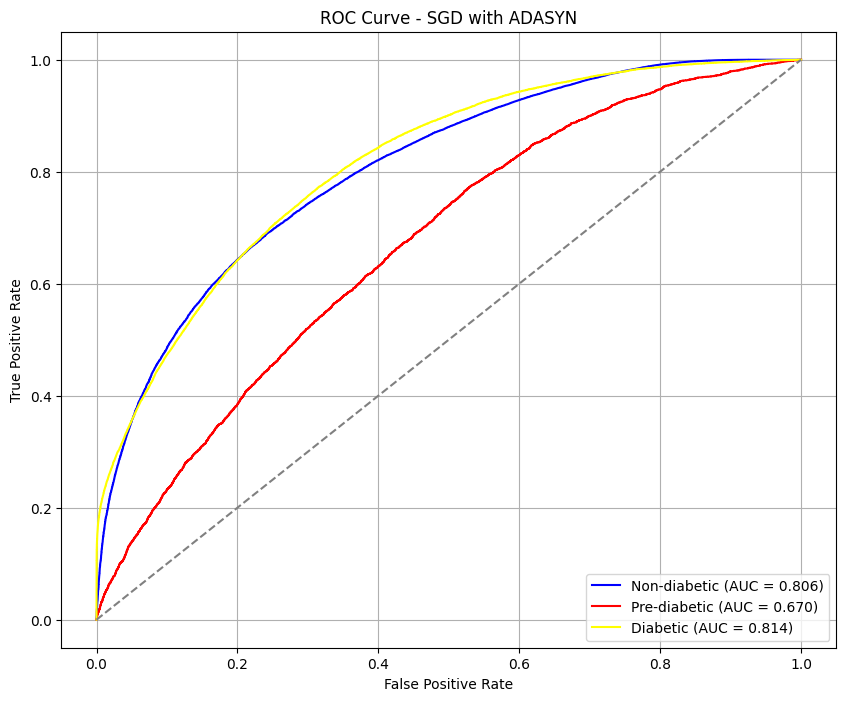

In [28]:
# Plot ROC and AUC of SGD model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["SGDClassifier"],
    model_name="SGD with ADASYN"
)

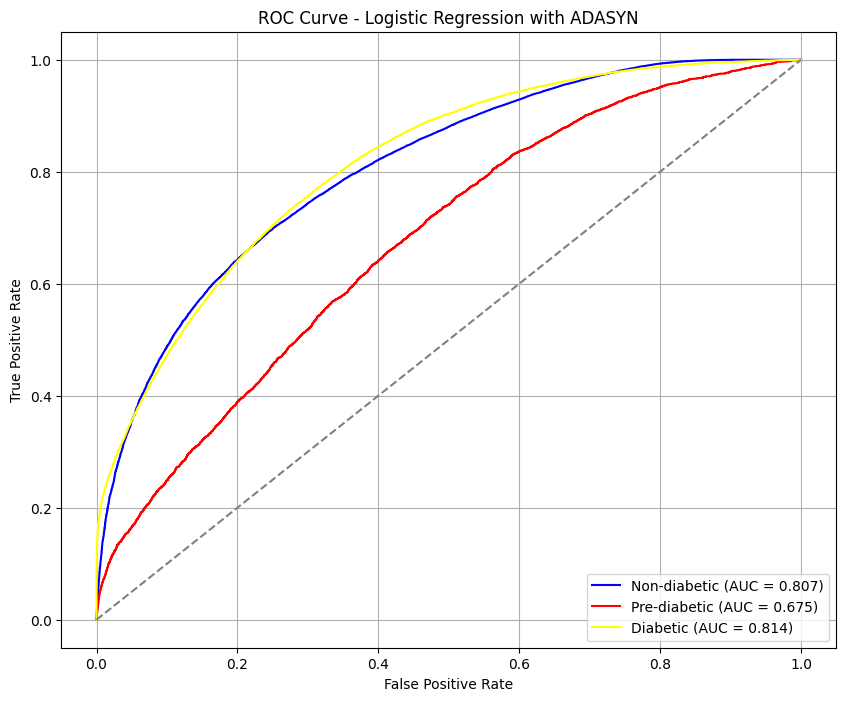

In [29]:
# Plot ROC and AUC of Logistic Regression model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with ADASYN"
)

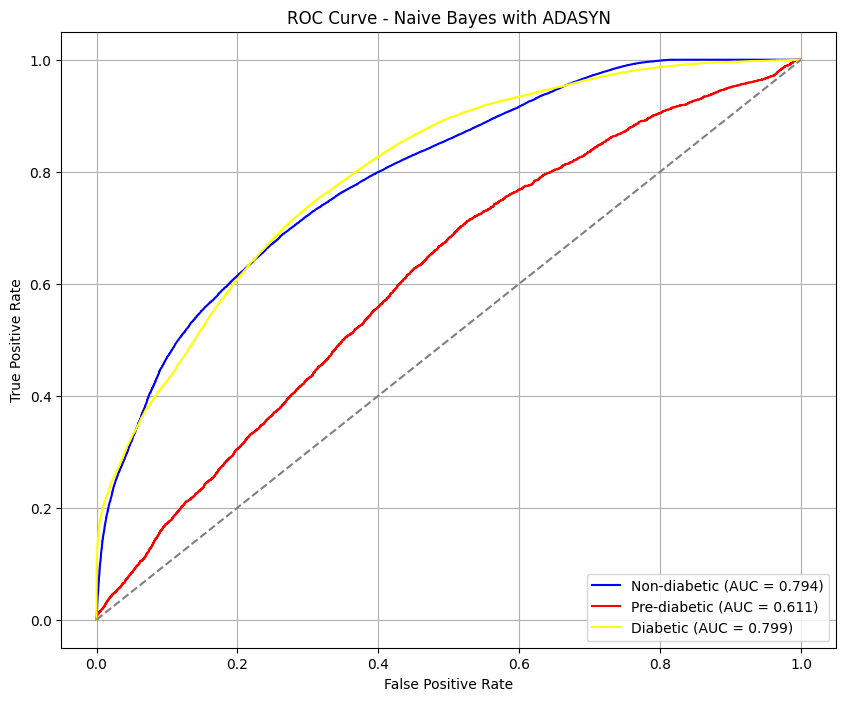

In [30]:
# Plot ROC and AUC of Naive Bayes model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with ADASYN"
)

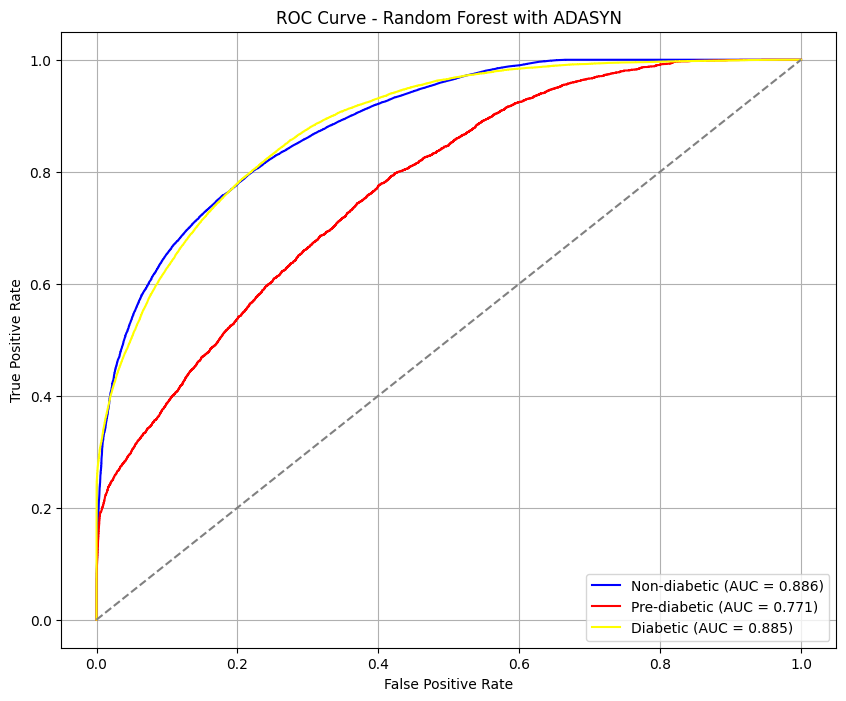

In [31]:
# Plot ROC and AUC of Random Forest model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["RandomForest"],
    model_name="Random Forest with ADASYN"
)

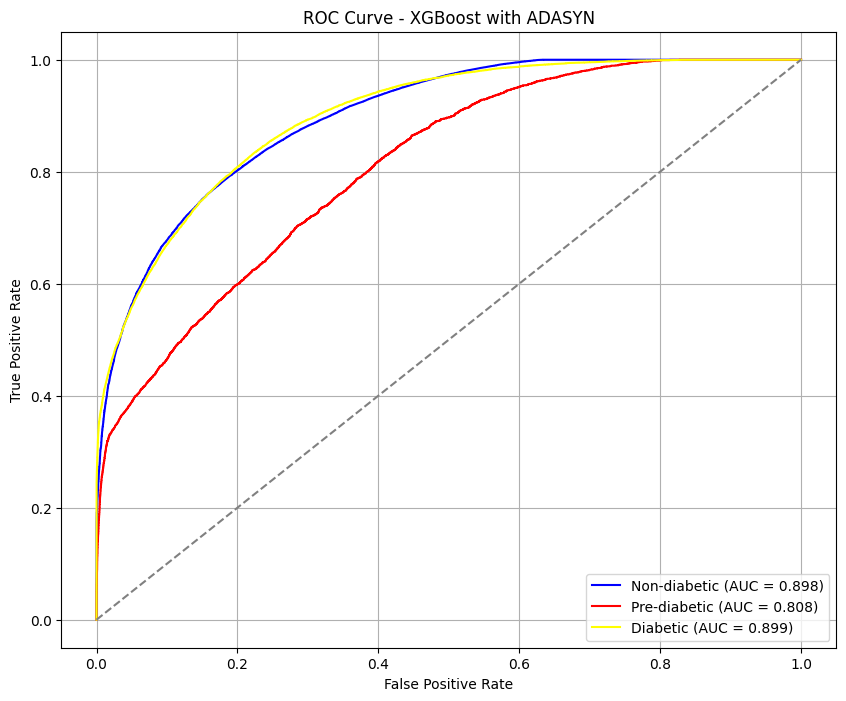

In [32]:
# Plot ROC and AUC of XGBoost model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["XGBoost"],
    model_name="XGBoost with ADASYN"
)

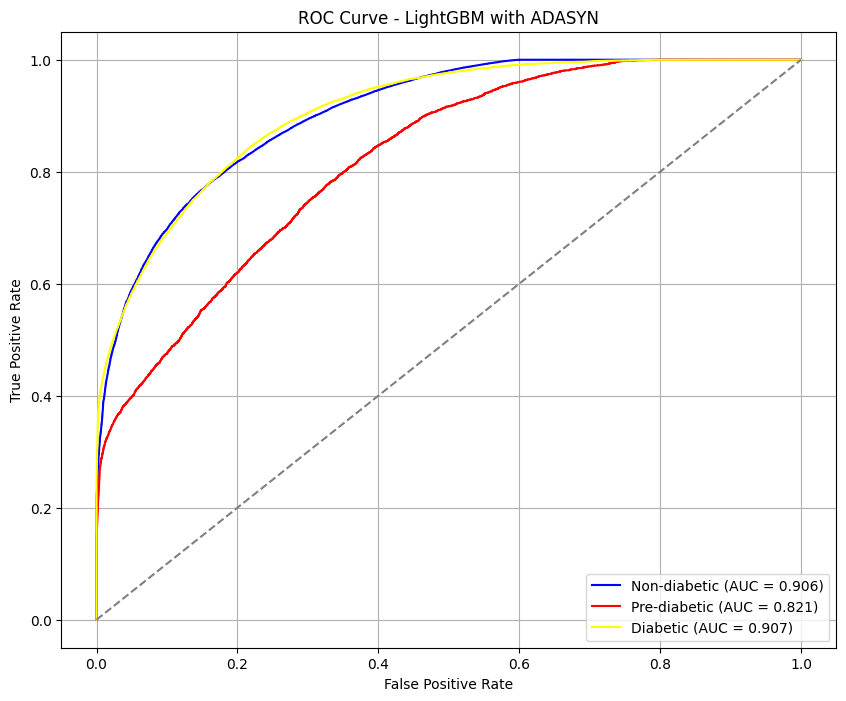

In [33]:
# Plot ROC and AUC of LightGBM model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["LightGBM"],
    model_name="LightGBM with ADASYN"
)

### **2.4 Random Undersampling**

Random Undersampling dramatically reduces dataset size from 562K to just 41K samples by randomly removing majority class samples. This approach trades information for computational efficiency and balanced class representation.

**Trade-offs Analysis:**
- **Computational Efficiency**: Significantly faster training due to reduced dataset size
- **Memory Benefits**: Lower memory requirements suitable for resource-constrained environments
- **Information Loss**: Risk of discarding important majority class patterns
- **Population Sampling**: Can be viewed as creating a representative sample of the healthy population

**Performance Expectations:**
Results may show increased variance due to the smaller dataset size, but potentially faster convergence. The key question is whether the retained samples provide sufficient information for accurate classification.

**Clinical Considerations:**
The method essentially creates a smaller, balanced cohort study from the original population survey. Success depends on whether the randomly selected healthy individuals still represent the full spectrum of the non-diabetic population's characteristics.

Evaluation focuses on whether the dramatic size reduction maintains predictive power or leads to underfitting due to insufficient training examples.

In [34]:
# Train and get evaluation results with the Random Undersamling method
rus_evaluation_results, rus_class_probabilities, rus_models = train_evaluate_all_models(
    X_train=rus_X_train_scaled, 
    y_train=rus_y_train, 
    X_test=rus_X_test_scaled, 
    y_test=y_test, 
    method_name="Random Undersampling"
)

2025-09-17 22:45:35,797 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 22:45:35,798 - [src.models] - INFO -   loss: log_loss
2025-09-17 22:45:35,798 - [src.models] - INFO -   penalty: l2
2025-09-17 22:45:35,799 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 22:45:35,800 - [src.models] - INFO -   learning_rate: constant
2025-09-17 22:45:35,800 - [src.models] - INFO -   eta0: 0.01
2025-09-17 22:45:35,801 - [src.models] - INFO -   max_iter: 1000
2025-09-17 22:45:35,802 - [src.models] - INFO -   random_state: 42
2025-09-17 22:45:35,803 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 22:45:35,803 - [src.models] - INFO -   C: 1.0
2025-09-17 22:45:35,803 - [src.models] - INFO -   penalty: l2
2025-09-17 22:45:35,804 - [src.models] - INFO -   class_weight: None
2025-09-17 22:45:35,805 - [src.models] - INFO -   solver: saga
2025-09-17 22:45:35,805 - [src.models] - INFO -   max_iter: 100
2025-09-17 22:45:35,806 

Training SGDClassifier on Random Undersampling data...


2025-09-17 22:45:36,381 - [src.models] - INFO - Model training completed. Training samples: 202459
2025-09-17 22:45:36,382 - [src.models] - INFO - Number of iterations: 7
2025-09-17 22:45:36,404 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:45:36,473 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:45:36,478 - [src.models] - INFO - Accuracy: 0.7434
2025-09-17 22:45:36,480 - [src.models] - INFO - Precision: 0.4225
2025-09-17 22:45:36,481 - [src.models] - INFO - Recall: 0.4862
2025-09-17 22:45:36,482 - [src.models] - INFO - F1-Score: 0.4357
2025-09-17 22:45:36,572 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.78      0.84    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.36      0.68      0.47     22237

    accuracy                           0.74    140504
   macro avg       0.42      0.49      0.44    140504
weighted avg   

Training LogisticRegression on Random Undersampling data...


2025-09-17 22:45:42,003 - [src.models] - INFO - Model training completed. Training samples: 202459
2025-09-17 22:45:42,019 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:45:42,064 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:45:42,065 - [src.models] - INFO - Accuracy: 0.7367
2025-09-17 22:45:42,066 - [src.models] - INFO - Precision: 0.4212
2025-09-17 22:45:42,068 - [src.models] - INFO - Recall: 0.4869
2025-09-17 22:45:42,070 - [src.models] - INFO - F1-Score: 0.4331
2025-09-17 22:45:42,126 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.77      0.83    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.35      0.69      0.47     22237

    accuracy                           0.74    140504
   macro avg       0.42      0.49      0.43    140504
weighted avg       0.80      0.74      0.76    140504

2025-09-17 22:45:42,213 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 254
[LightGBM] [Info] Number of data points in the train set: 161967, number of used features: 14
[LightGBM] [Info] Start training from score -0.705366
[LightGBM] [Info] Start training from score -2.706921
[LightGBM] [Info] Start training from score -0.822504


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 254
[LightGBM] [Info] Number of data points in the train set: 161968, number of used features: 14
[LightGBM] [Info] Start training from score -0.705372
[LightGBM] [Info] Start training from score -2.706927
[LightGBM] [Info] Start training from score -0.822496


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 22:47:35,673 - [src.models] - INFO - Cross-validation results:
2025-09-17 22:47:35,674 - [src.models] - INFO - Mean accuracy: 0.7769 (+/- 0.0026)
2025-09-17 22:47:35,700 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:47:35,728 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:47:35,998 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:47:36,023 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:47:36,357 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:47:36,398 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:47:38,981 - [src.models] - INFO - Predic

In [35]:
# The evaluation result of all models with the Random Undersampling method
rus_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.7434,0.7559,0.4862,0.4357,0.7583,0.9109,1.0000,0.3567,0.7773,0.0000,0.6812,0.8388,0.0000,0.4683,0.681259,0.001877
1,LogisticRegression,0.7367,0.7545,0.4869,0.4331,0.7586,0.9128,1.0000,0.3507,0.7666,0.0000,0.6941,0.8333,0.0000,0.4660,0.682390,0.001110
2,NaiveBayes,0.7564,0.4509,0.4709,0.4375,0.7342,0.8961,0.0929,0.3637,0.8091,0.0050,0.5986,0.8504,0.0095,0.4525,0.662050,0.001339
3,RandomForest,0.7528,0.4976,0.6056,0.5175,0.8483,0.9507,0.0987,0.4433,0.7710,0.3215,0.7243,0.8515,0.1510,0.5500,0.722013,0.001683
4,XGBoost,0.8055,0.7634,0.5922,0.5707,0.8675,0.9459,0.8945,0.4499,0.8252,0.1480,0.8033,0.8814,0.2540,0.5768,0.769948,0.000831
5,LightGBM,0.8100,0.7663,0.6068,0.5907,0.8772,0.9478,0.8945,0.4567,0.8287,0.1832,0.8085,0.8842,0.3042,0.5837,0.776942,0.001289


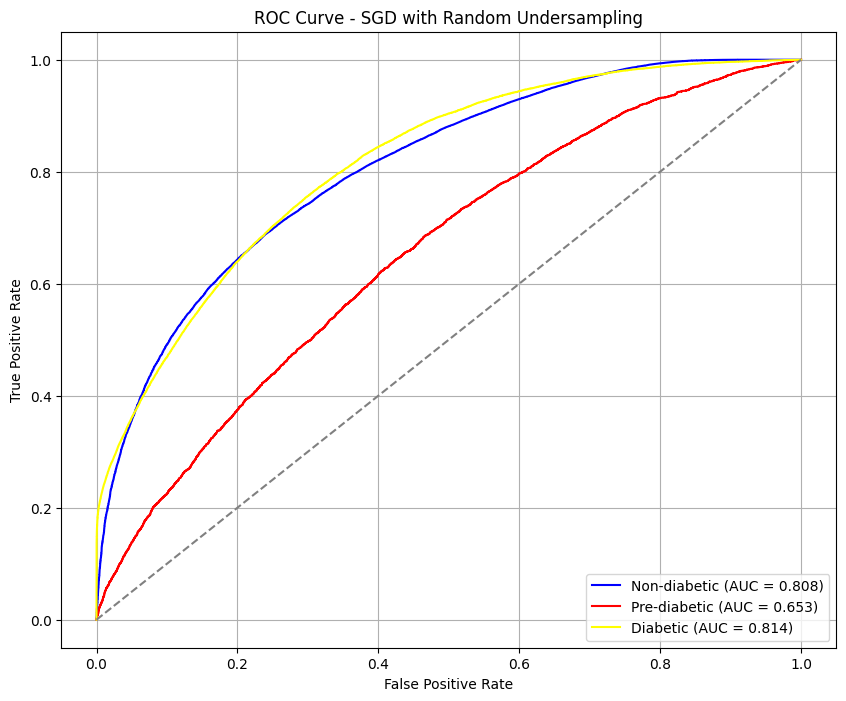

In [36]:
# Plot ROC and AUC of SGD model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["SGDClassifier"],
    model_name="SGD with Random Undersampling"
)

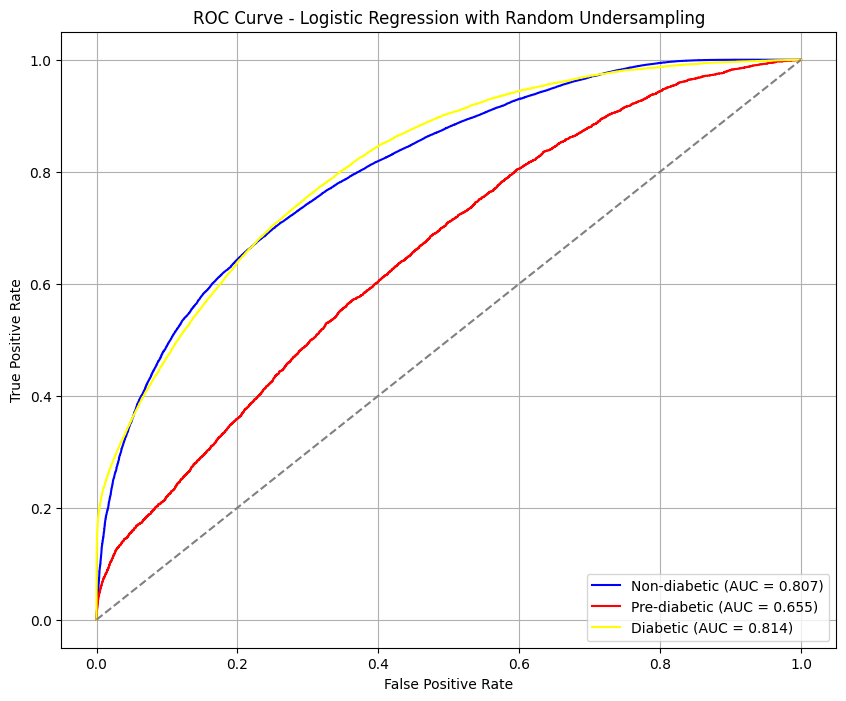

In [37]:
# Plot ROC and AUC of Logistic Regression model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with Random Undersampling"
)

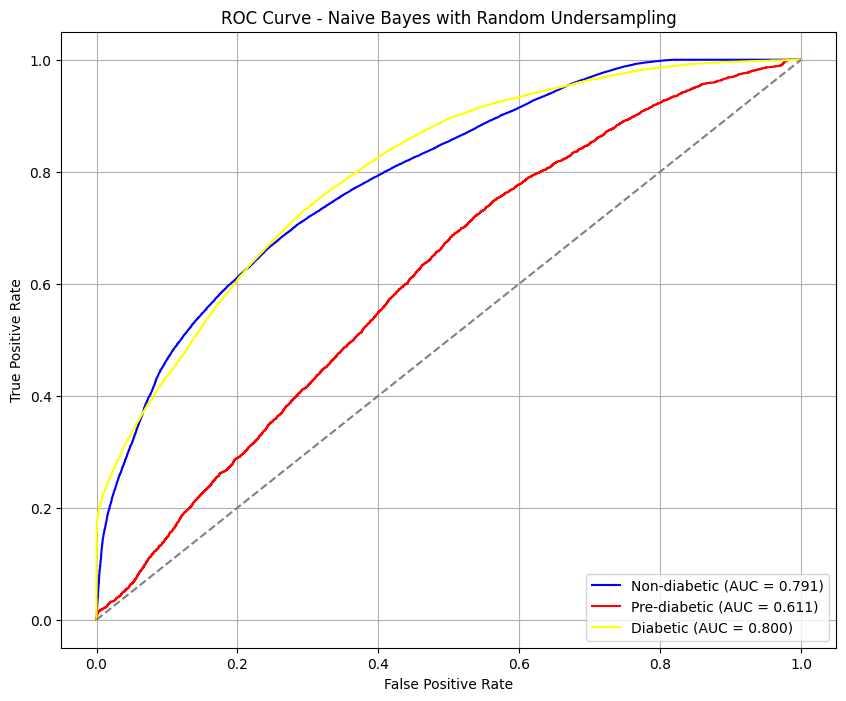

In [38]:
# Plot ROC and AUC of Naive Bayes model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with Random Undersampling"
)

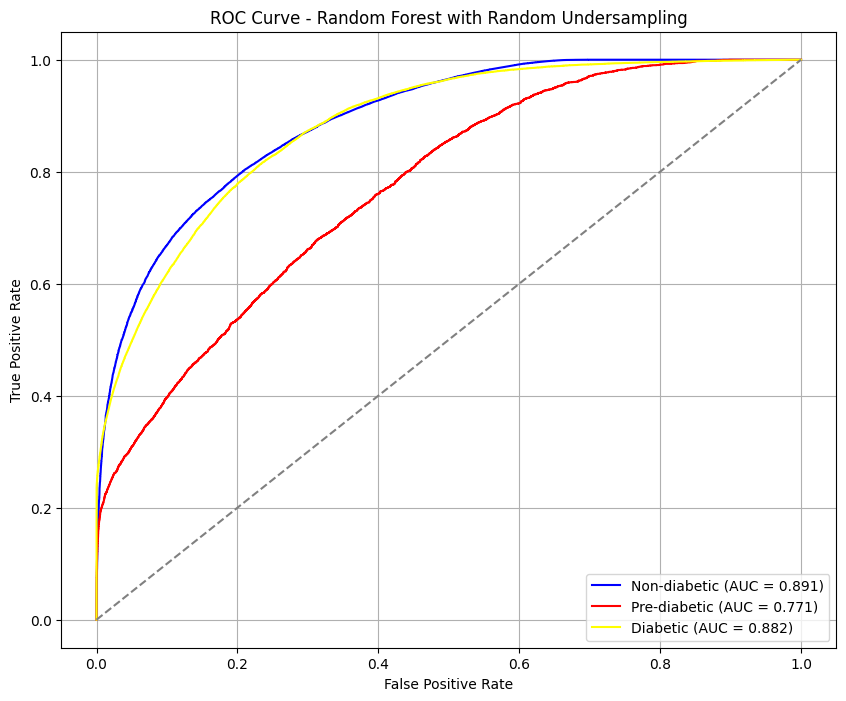

In [39]:
# Plot ROC and AUC of Random Forest model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["RandomForest"],
    model_name="Random Forest with Random Undersampling"
)

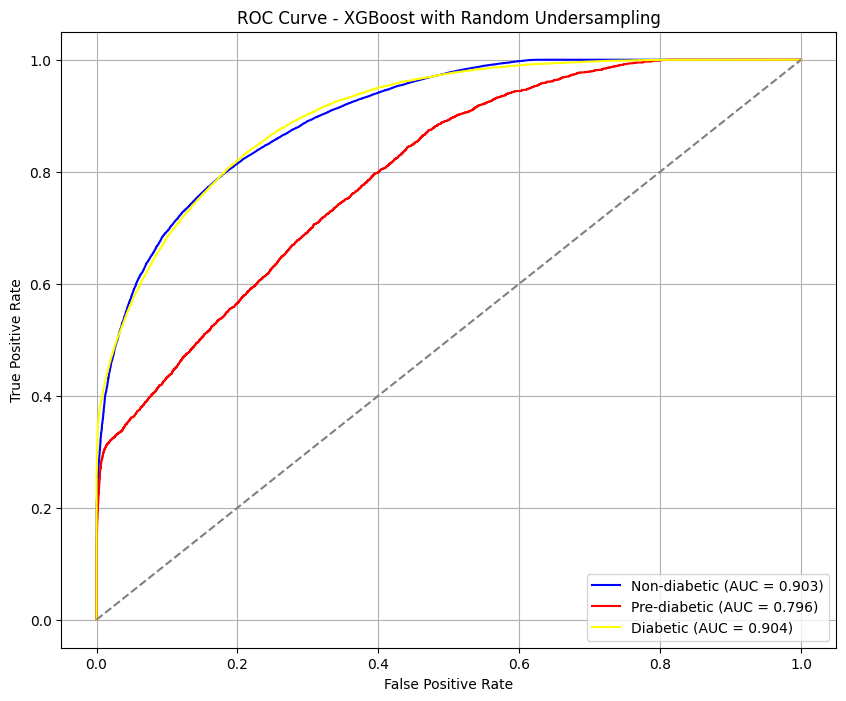

In [40]:
# Plot ROC and AUC of XGBoost model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["XGBoost"], 
    model_name="XGBoost with Random Undersampling", 
)

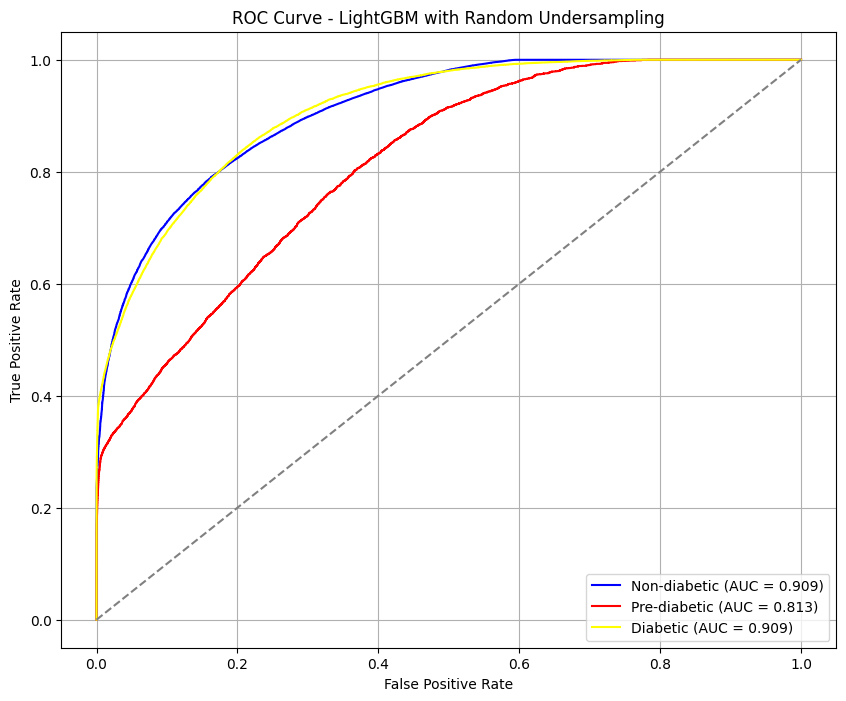

In [41]:
# Plot ROC and AUC of LightGBM model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["LightGBM"], 
    model_name="LightGBM with Random Undersampling", 
)

### **2.5 Tomek Links**

Tomek Links represents an intelligent undersampling approach that removes only those majority class samples that are nearest neighbors to minority class samples, effectively cleaning class boundaries while preserving most training data.

**Boundary Cleaning Strategy:**
- **Selective Removal**: Only removes samples at class boundaries that may cause confusion
- **Noise Reduction**: Eliminates ambiguous samples that could mislead classifiers
- **Information Preservation**: Retains the vast majority of training samples (95% retention)
- **Improved Decision Boundaries**: Creates cleaner separation between classes

**Medical Interpretation:**
The method identifies and removes cases where healthy individuals have health profiles very similar to diabetic patients, or vice versa. These borderline cases might represent misclassified samples or individuals at transition points between health states.

**Expected Performance:**
Models should show improved precision by reducing false positives caused by ambiguous boundary samples. The minimal data loss (only 5%) should maintain overall model robustness while improving classification clarity.

Results demonstrate whether intelligent sample removal provides better performance than random undersampling while maintaining computational benefits.

In [42]:
# Train and get evaluation results with the Tomek Links method
tomek_evaluation_results, tomek_class_probabilities, tomek_models = train_evaluate_all_models(
    X_train=tomek_X_train_scaled, 
    y_train=tomek_y_train, 
    X_test=tomek_X_test_scaled, 
    y_test=y_test, 
    method_name="Tomek Links"
)

2025-09-17 22:47:46,846 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 22:47:46,847 - [src.models] - INFO -   loss: log_loss
2025-09-17 22:47:46,847 - [src.models] - INFO -   penalty: l2
2025-09-17 22:47:46,848 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 22:47:46,849 - [src.models] - INFO -   learning_rate: constant
2025-09-17 22:47:46,849 - [src.models] - INFO -   eta0: 0.01
2025-09-17 22:47:46,850 - [src.models] - INFO -   max_iter: 1000
2025-09-17 22:47:46,851 - [src.models] - INFO -   random_state: 42
2025-09-17 22:47:46,852 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 22:47:46,853 - [src.models] - INFO -   C: 1.0
2025-09-17 22:47:46,854 - [src.models] - INFO -   penalty: l2
2025-09-17 22:47:46,855 - [src.models] - INFO -   class_weight: None
2025-09-17 22:47:46,856 - [src.models] - INFO -   solver: saga
2025-09-17 22:47:46,856 - [src.models] - INFO -   max_iter: 100
2025-09-17 22:47:46,857 

Training SGDClassifier on Tomek Links data...


2025-09-17 22:47:48,636 - [src.models] - INFO - Model training completed. Training samples: 543321
2025-09-17 22:47:48,637 - [src.models] - INFO - Number of iterations: 7
2025-09-17 22:47:48,652 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:47:48,718 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:47:48,719 - [src.models] - INFO - Accuracy: 0.8470
2025-09-17 22:47:48,720 - [src.models] - INFO - Precision: 0.5128
2025-09-17 22:47:48,721 - [src.models] - INFO - Recall: 0.4277
2025-09-17 22:47:48,722 - [src.models] - INFO - F1-Score: 0.4457
2025-09-17 22:47:48,793 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.91    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.68      0.31      0.42     22237

    accuracy                           0.85    140504
   macro avg       0.51      0.43      0.45    140504
weighted avg   

Training LogisticRegression on Tomek Links data...


2025-09-17 22:48:03,025 - [src.models] - INFO - Model training completed. Training samples: 543321
2025-09-17 22:48:03,036 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:48:03,077 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:48:03,078 - [src.models] - INFO - Accuracy: 0.8512
2025-09-17 22:48:03,079 - [src.models] - INFO - Precision: 0.5383
2025-09-17 22:48:03,080 - [src.models] - INFO - Recall: 0.4227
2025-09-17 22:48:03,081 - [src.models] - INFO - F1-Score: 0.4426
2025-09-17 22:48:03,127 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.76      0.28      0.41     22237

    accuracy                           0.85    140504
   macro avg       0.54      0.42      0.44    140504
weighted avg       0.82      0.85      0.81    140504

2025-09-17 22:48:03,221 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 248
[LightGBM] [Info] Number of data points in the train set: 434657, number of used features: 14
[LightGBM] [Info] Start training from score -0.187987
[LightGBM] [Info] Start training from score -3.694086
[LightGBM] [Info] Start training from score -1.920702


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 251
[LightGBM] [Info] Number of data points in the train set: 434657, number of used features: 14
[LightGBM] [Info] Start training from score -0.187987
[LightGBM] [Info] Start training from score -3.694178
[LightGBM] [Info] Start training from score -1.920687


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 22:53:57,954 - [src.models] - INFO - Cross-validation results:
2025-09-17 22:53:57,955 - [src.models] - INFO - Mean accuracy: 0.8984 (+/- 0.0015)
2025-09-17 22:53:57,978 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:53:58,005 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:53:58,285 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:53:58,315 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:53:58,597 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:53:58,640 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:54:01,535 - [src.models] - INFO - Predic

In [43]:
# The evaluation result of all models with the Tomek Links method
tomek_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8470,0.8461,0.4277,0.4457,0.7609,0.8601,1.0000,0.6783,0.9765,0.0000,0.3067,0.9146,0.0000,0.4224,0.863083,0.000976
1,LogisticRegression,0.8512,0.8717,0.4227,0.4426,0.7644,0.8570,1.0000,0.7580,0.9864,0.0000,0.2817,0.9171,0.0000,0.4108,0.862485,0.000915
2,NaiveBayes,0.7821,0.5141,0.4594,0.4419,0.7409,0.8847,0.2642,0.3935,0.8560,0.0041,0.5181,0.8701,0.0082,0.4473,0.790071,0.000764
3,RandomForest,0.7847,0.5114,0.5991,0.5356,0.8471,0.9376,0.1232,0.4734,0.8194,0.2987,0.6792,0.8746,0.1744,0.5579,0.797681,0.001419
4,XGBoost,0.8851,0.8764,0.5297,0.5974,0.8771,0.8855,0.8620,0.8817,0.9947,0.1664,0.4281,0.9369,0.2789,0.5763,0.895798,0.000631
5,LightGBM,0.8888,0.8704,0.5473,0.6185,0.8832,0.8895,0.8373,0.8843,0.9941,0.1980,0.4498,0.9389,0.3203,0.5963,0.898423,0.000763


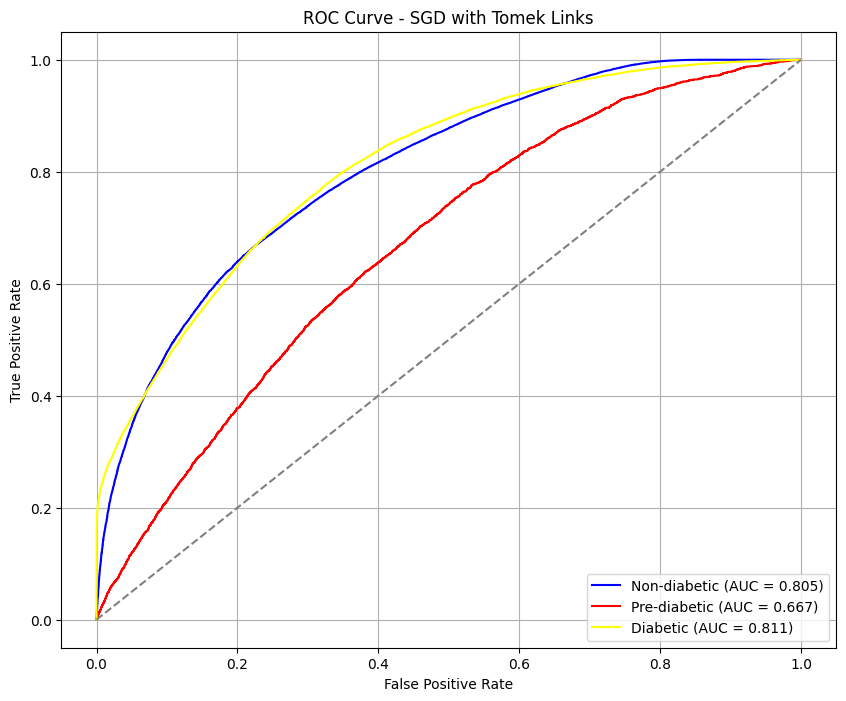

In [44]:
# Plot ROC and AUC of SGD model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["SGDClassifier"],
    model_name="SGD with Tomek Links"
)

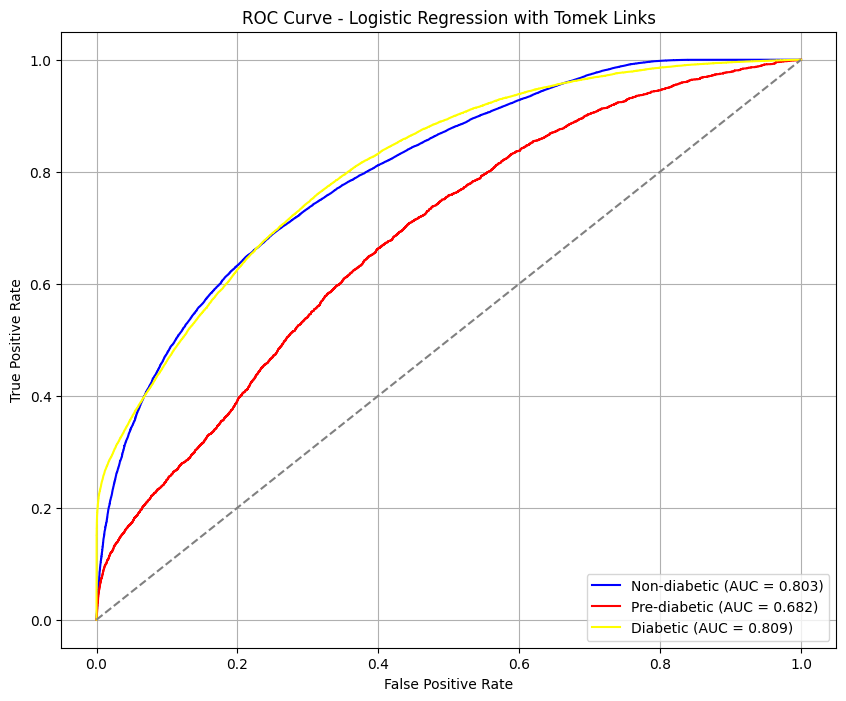

In [45]:
# Plot ROC and AUC of Logistic Regression model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with Tomek Links"
)

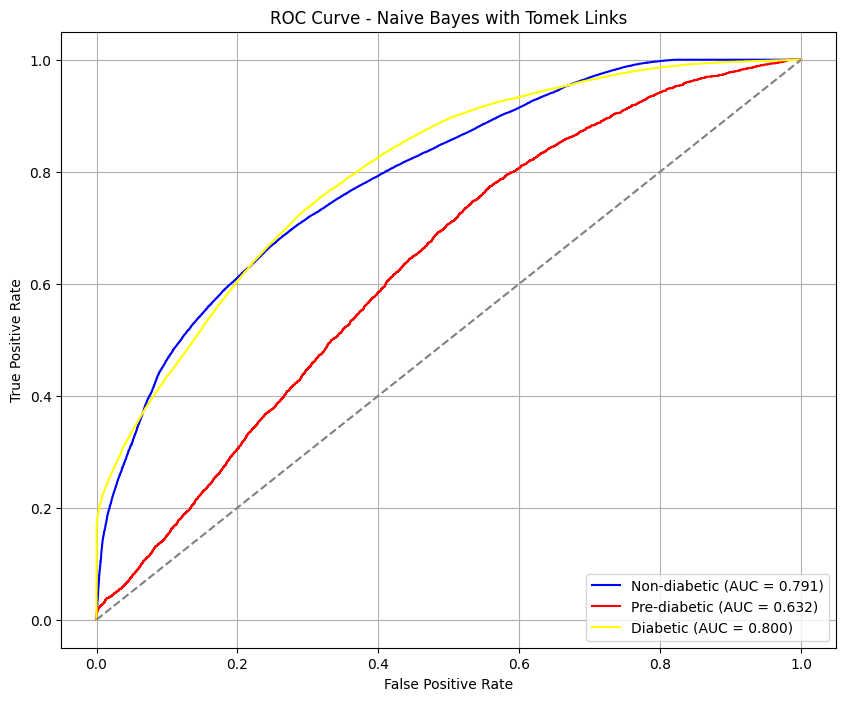

In [46]:
# Plot ROC and AUC of Naive Bayes model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with Tomek Links"
)

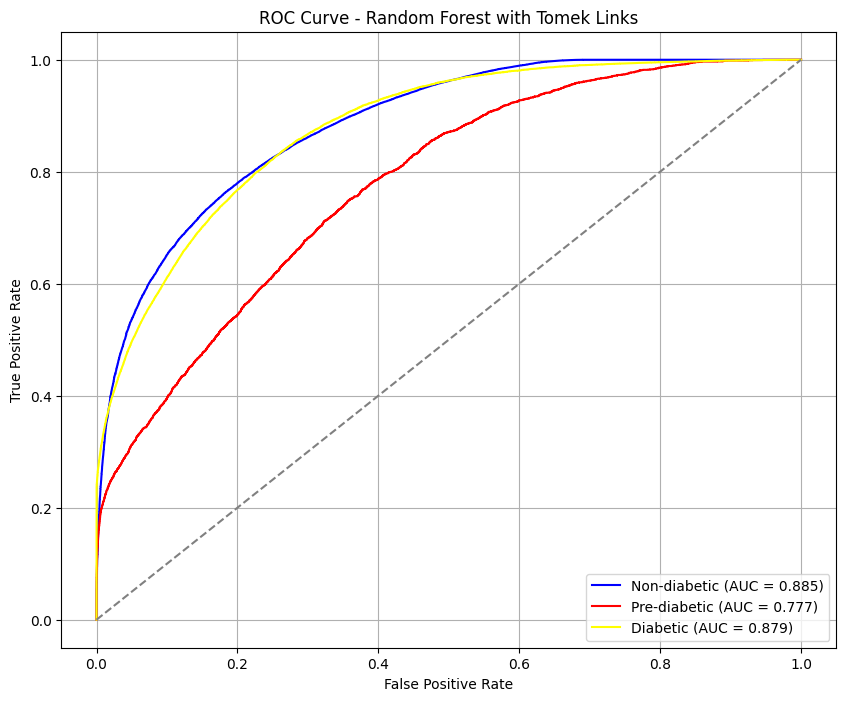

In [47]:
# Plot ROC and AUC of Random Forest model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["RandomForest"],
    model_name="Random Forest with Tomek Links"
)

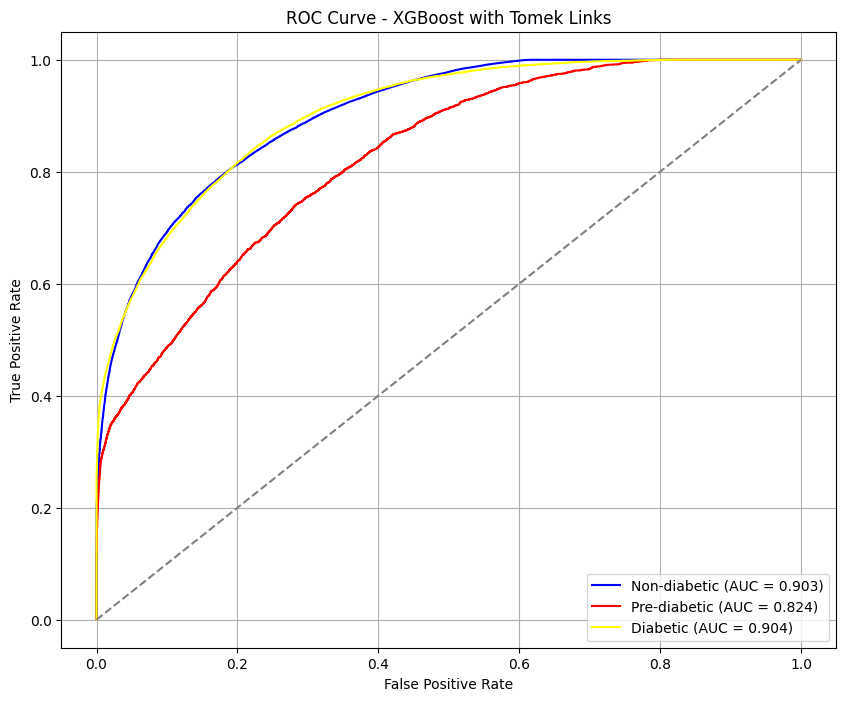

In [48]:
# Plot ROC and AUC of XGBoost model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["XGBoost"],
    model_name="XGBoost with Tomek Links"
)

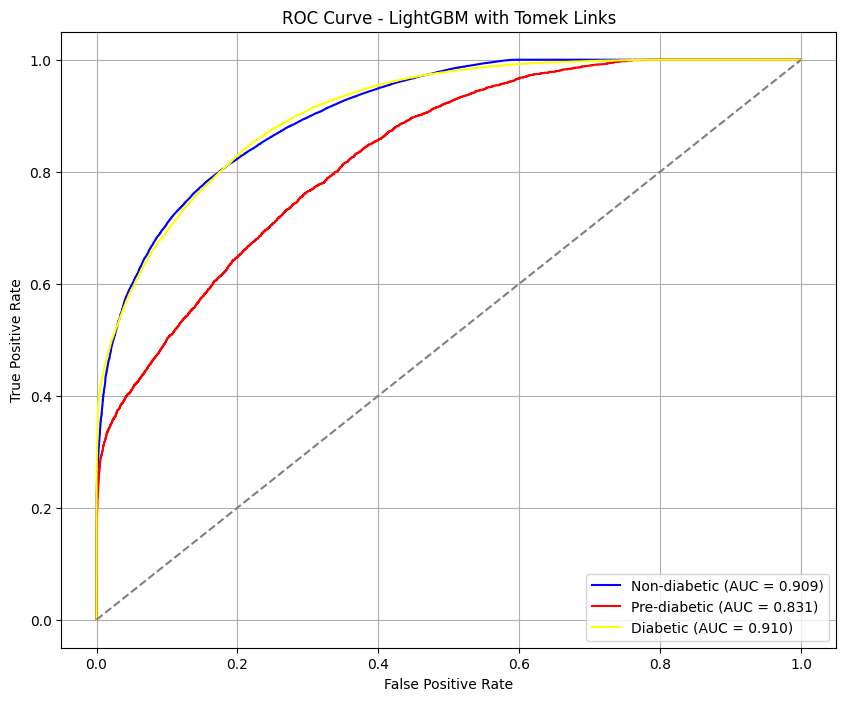

In [49]:
# Plot ROC and AUC of LightGBM model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["LightGBM"],
    model_name="LightGBM with Tomek Links"
)

### **2.6 Edited Nearest Neighbors**

Edited Nearest Neighbors (ENN) provides comprehensive data cleaning by removing samples from all classes whose labels disagree with the majority of their k-nearest neighbors. This method prioritizes data quality over quantity.

**Comprehensive Cleaning Approach:**
- **Multi-class Cleaning**: Removes noisy samples from all classes, not just majority
- **Quality Focus**: Prioritizes data reliability over dataset size
- **Noise Detection**: Identifies potentially mislabeled or ambiguous samples
- **Boundary Improvement**: Enhances class separation by removing confusing examples

**Clinical Data Quality:**
In medical datasets, ENN helps identify:
- **Data Entry Errors**: Samples with inconsistent feature combinations
- **Misclassified Cases**: Patients whose diagnosed status doesn't match their health profile
- **Transitional Cases**: Individuals at unclear stages of diabetes progression
- **Measurement Errors**: Samples with implausible biomarker combinations

**Performance Expectations:**
The method should improve model confidence and reduce prediction uncertainty by training on cleaner, more consistent data. The trade-off is a 6% reduction in dataset size for improved data quality.

Evaluation reveals whether the emphasis on data quality over quantity leads to more reliable and consistent model performance across different algorithms.

In [50]:
# Train and get evaluation results with the Edited Nearest Neighbors method
enn_evaluation_results, enn_class_probabilities, enn_models = train_evaluate_all_models(
    X_train=enn_X_train_scaled, 
    y_train=enn_y_train, 
    X_test=enn_X_test_scaled, 
    y_test=y_test, 
    method_name="Edited Nearest Neighbors"
)

2025-09-17 22:54:09,671 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 22:54:09,672 - [src.models] - INFO -   loss: log_loss
2025-09-17 22:54:09,673 - [src.models] - INFO -   penalty: l2
2025-09-17 22:54:09,675 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 22:54:09,675 - [src.models] - INFO -   learning_rate: constant
2025-09-17 22:54:09,677 - [src.models] - INFO -   eta0: 0.01
2025-09-17 22:54:09,678 - [src.models] - INFO -   max_iter: 1000
2025-09-17 22:54:09,678 - [src.models] - INFO -   random_state: 42
2025-09-17 22:54:09,680 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 22:54:09,680 - [src.models] - INFO -   C: 1.0
2025-09-17 22:54:09,681 - [src.models] - INFO -   penalty: l2
2025-09-17 22:54:09,682 - [src.models] - INFO -   class_weight: None
2025-09-17 22:54:09,683 - [src.models] - INFO -   solver: saga
2025-09-17 22:54:09,684 - [src.models] - INFO -   max_iter: 100
2025-09-17 22:54:09,684 

Training SGDClassifier on Edited Nearest Neighbors data...


2025-09-17 22:54:10,883 - [src.models] - INFO - Model training completed. Training samples: 395022
2025-09-17 22:54:10,883 - [src.models] - INFO - Number of iterations: 8
2025-09-17 22:54:10,895 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:54:10,965 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:54:10,966 - [src.models] - INFO - Accuracy: 0.8557
2025-09-17 22:54:10,971 - [src.models] - INFO - Precision: 0.5813
2025-09-17 22:54:10,974 - [src.models] - INFO - Recall: 0.4172
2025-09-17 22:54:10,975 - [src.models] - INFO - F1-Score: 0.4386
2025-09-17 22:54:11,040 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.89      0.25      0.40     22237

    accuracy                           0.86    140504
   macro avg       0.58      0.42      0.44    140504
weighted avg   

Training LogisticRegression on Edited Nearest Neighbors data...


2025-09-17 22:54:20,959 - [src.models] - INFO - Model training completed. Training samples: 395022
2025-09-17 22:54:20,973 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:54:21,018 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:54:21,019 - [src.models] - INFO - Accuracy: 0.8561
2025-09-17 22:54:21,020 - [src.models] - INFO - Precision: 0.5847
2025-09-17 22:54:21,020 - [src.models] - INFO - Recall: 0.4178
2025-09-17 22:54:21,021 - [src.models] - INFO - F1-Score: 0.4396
2025-09-17 22:54:21,071 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.90      0.26      0.40     22237

    accuracy                           0.86    140504
   macro avg       0.58      0.42      0.44    140504
weighted avg       0.84      0.86      0.82    140504

2025-09-17 22:54:21,161 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 251
[LightGBM] [Info] Number of data points in the train set: 316018, number of used features: 14
[LightGBM] [Info] Start training from score -0.111544
[LightGBM] [Info] Start training from score -3.375328
[LightGBM] [Info] Start training from score -2.640286


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 250
[LightGBM] [Info] Number of data points in the train set: 316018, number of used features: 14
[LightGBM] [Info] Start training from score -0.111540
[LightGBM] [Info] Start training from score -3.375420
[LightGBM] [Info] Start training from score -2.640286


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 22:57:58,237 - [src.models] - INFO - Cross-validation results:
2025-09-17 22:57:58,239 - [src.models] - INFO - Mean accuracy: 0.9694 (+/- 0.0008)
2025-09-17 22:57:58,267 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:57:58,293 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:57:58,569 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:57:58,600 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:57:58,935 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:57:58,980 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 22:58:01,551 - [src.models] - INFO - Predic

In [51]:
# The evaluation result of all models with the Edited Nearest Neighbors method
enn_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8557,0.9147,0.4172,0.4386,0.7519,0.8541,1.0000,0.8899,0.9973,0.0000,0.2545,0.9201,0.0000,0.3958,0.944514,0.000409
1,LogisticRegression,0.8561,0.9180,0.4178,0.4396,0.7528,0.8541,1.0000,0.8999,0.9975,0.0000,0.2559,0.9202,0.0000,0.3985,0.944699,0.000415
2,NaiveBayes,0.7637,0.4720,0.4612,0.4533,0.7404,0.8868,0.0418,0.4873,0.8573,0.1536,0.3728,0.8718,0.0657,0.4224,0.847900,0.001801
3,RandomForest,0.7698,0.6210,0.5677,0.5034,0.8318,0.9219,0.0678,0.8732,0.8589,0.4923,0.3518,0.8893,0.1192,0.5015,0.927419,0.001557
4,XGBoost,0.8757,0.7407,0.5341,0.5883,0.8678,0.8807,0.4436,0.8978,0.9949,0.2528,0.3546,0.9343,0.3221,0.5084,0.968133,0.000545
5,LightGBM,0.8779,0.7183,0.5471,0.5927,0.8739,0.8866,0.3729,0.8955,0.9942,0.2792,0.3679,0.9373,0.3193,0.5215,0.969356,0.000384


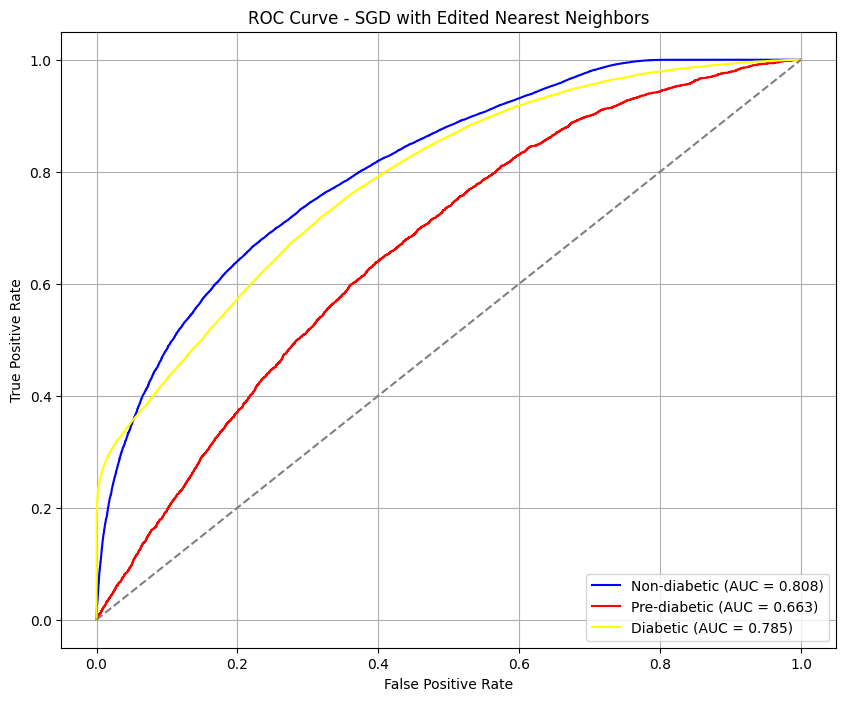

In [52]:
# Plot ROC and AUC of SGD model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["SGDClassifier"],
    model_name="SGD with Edited Nearest Neighbors"
)

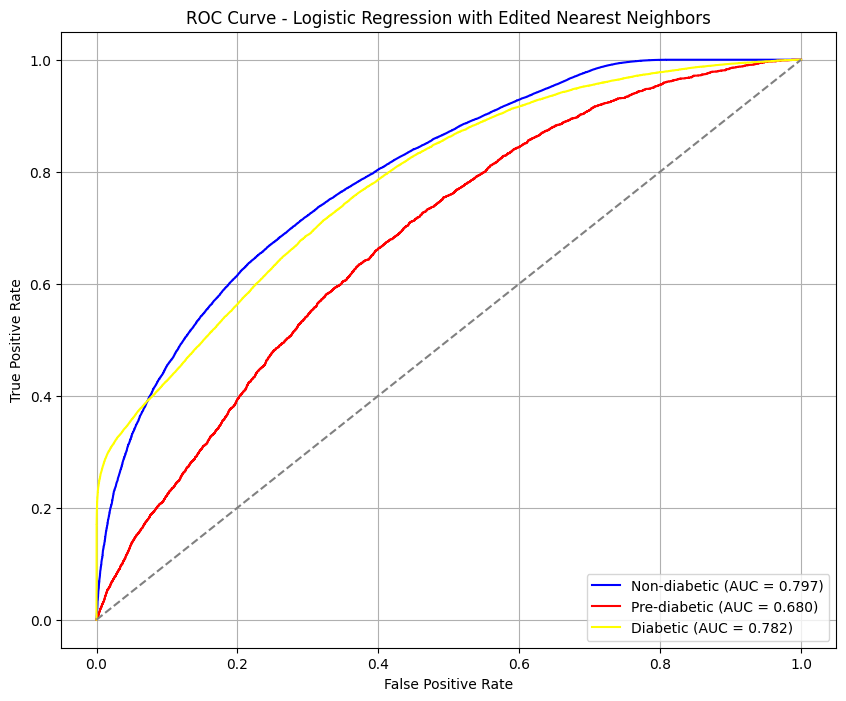

In [53]:
# Plot ROC and AUC of Logistic Regression model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with Edited Nearest Neighbors"
)

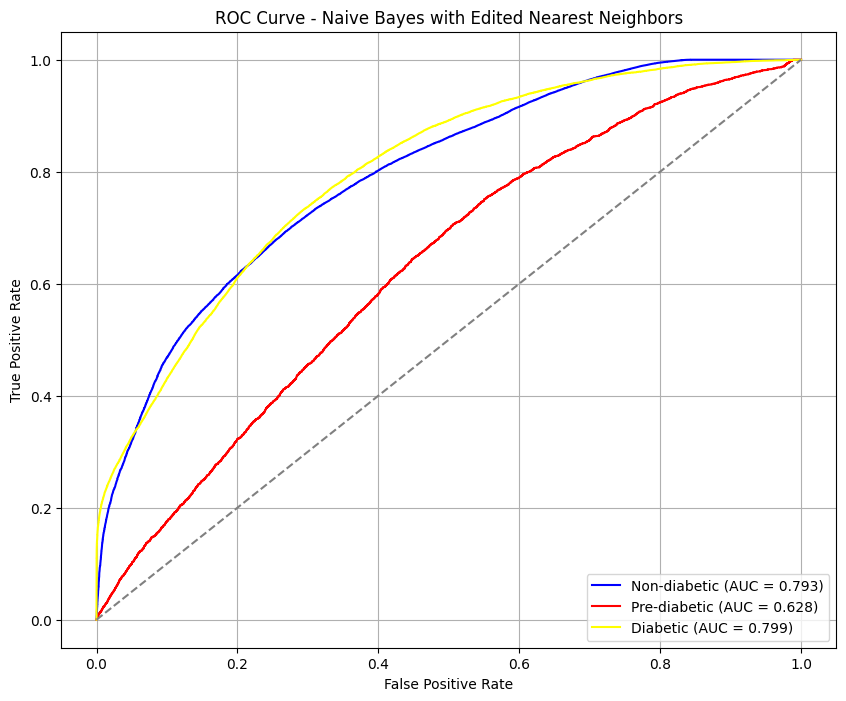

In [54]:
# Plot ROC and AUC of Naive Bayes model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with Edited Nearest Neighbors"
)

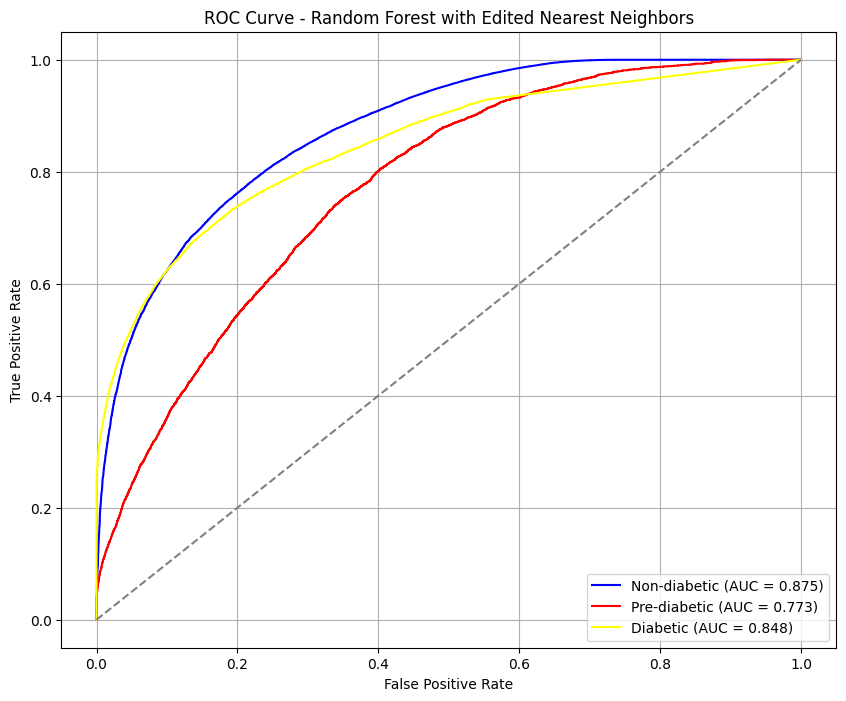

In [55]:
# Plot ROC and AUC of Random Forest model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["RandomForest"],
    model_name="Random Forest with Edited Nearest Neighbors"
)

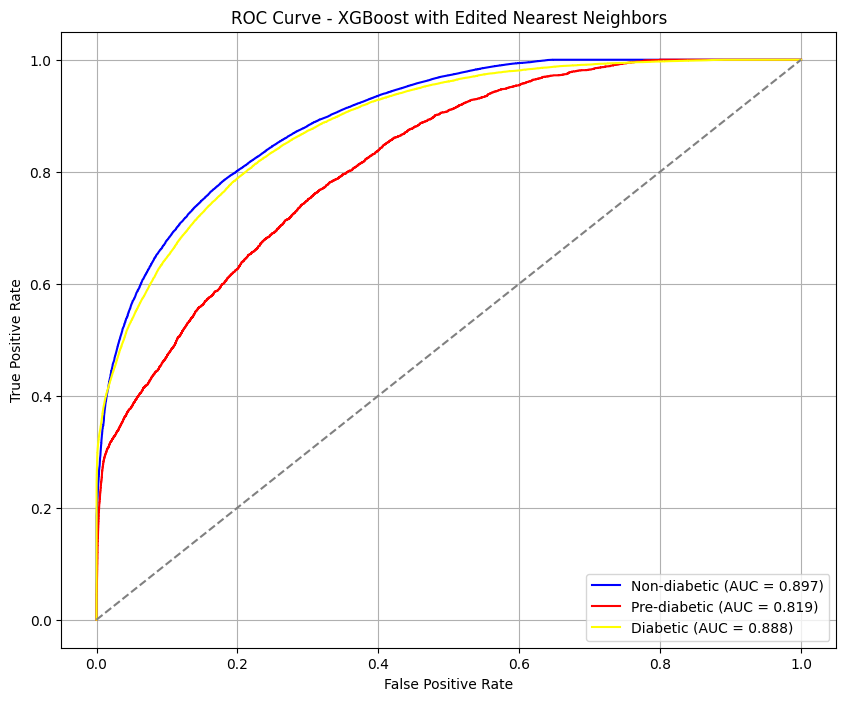

In [56]:
# Plot ROC and AUC of XGBoost model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["XGBoost"],
    model_name="XGBoost with Edited Nearest Neighbors"
)

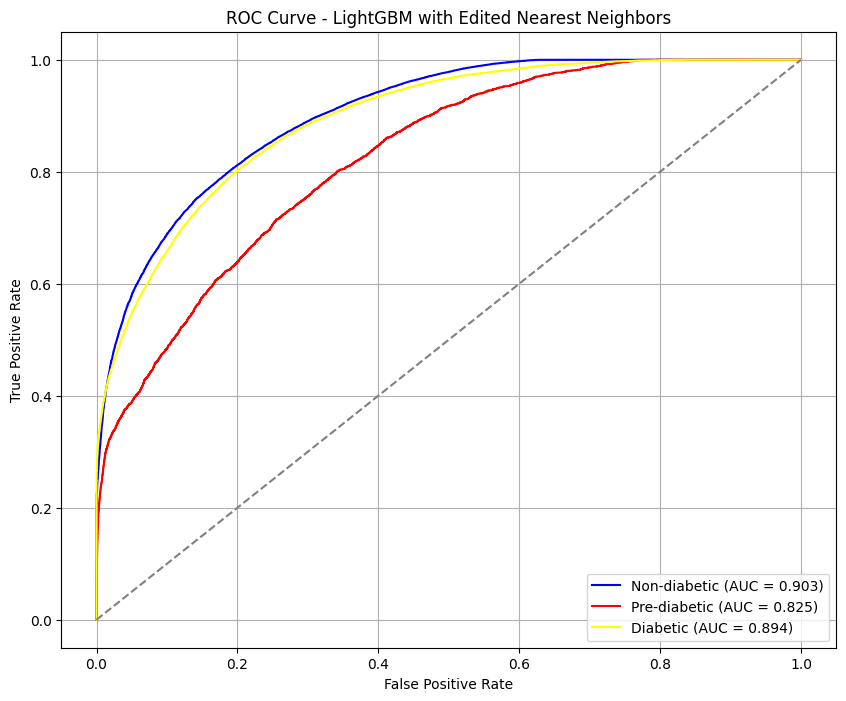

In [57]:
# Plot ROC and AUC of LightGBM model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["LightGBM"],
    model_name="LightGBM with Edited Nearest Neighbors"
)

### **2.7 SMOTE + Tomek Links**

The combination of SMOTE and Tomek Links represents a sophisticated hybrid approach that first generates synthetic minority samples and then cleans the resulting dataset by removing boundary noise. This two-stage process aims to maximize both balance and data quality.

**Two-Stage Process:**
1. **SMOTE Generation**: Creates synthetic minority samples to achieve desired class balance
2. **Tomek Cleaning**: Removes noisy boundary samples from the expanded dataset

**Synergistic Benefits:**
- **Comprehensive Balance**: SMOTE ensures adequate minority class representation
- **Quality Assurance**: Tomek Links removes synthetic samples that may be poorly positioned
- **Boundary Optimization**: Results in cleaner decision boundaries than either method alone
- **Robust Performance**: Combines the strengths of both oversampling and undersampling

**Medical Application:**
This approach creates a large, balanced dataset of high-quality samples. Synthetic patients generated by SMOTE undergo quality control through Tomek Links, ensuring only well-positioned synthetic cases remain for training.

**Expected Outcomes:**
The combination should provide excellent performance across all algorithms, particularly benefiting models sensitive to both class imbalance and noisy training data. The resulting dataset (804K samples) is larger than original but cleaner than pure SMOTE.

Results demonstrate whether the two-stage approach justifies the additional computational complexity through improved model performance.

In [58]:
# Train and get evaluation results with the SMOTE + Tomek Links method
smote_tomek_evaluation_results, smote_tomek_class_probabilities, smote_tomek_models = train_evaluate_all_models(
    X_train=smote_tomek_X_train_scaled,
    y_train=smote_tomek_y_train, 
    X_test=smote_tomek_X_test_scaled, 
    y_test=y_test, 
    method_name="SMOTE + Tomek Links"
)

2025-09-17 22:58:09,220 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 22:58:09,220 - [src.models] - INFO -   loss: log_loss
2025-09-17 22:58:09,221 - [src.models] - INFO -   penalty: l2
2025-09-17 22:58:09,221 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 22:58:09,222 - [src.models] - INFO -   learning_rate: constant
2025-09-17 22:58:09,223 - [src.models] - INFO -   eta0: 0.01
2025-09-17 22:58:09,223 - [src.models] - INFO -   max_iter: 1000
2025-09-17 22:58:09,224 - [src.models] - INFO -   random_state: 42
2025-09-17 22:58:09,224 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 22:58:09,225 - [src.models] - INFO -   C: 1.0
2025-09-17 22:58:09,226 - [src.models] - INFO -   penalty: l2
2025-09-17 22:58:09,227 - [src.models] - INFO -   class_weight: None
2025-09-17 22:58:09,227 - [src.models] - INFO -   solver: saga
2025-09-17 22:58:09,228 - [src.models] - INFO -   max_iter: 100
2025-09-17 22:58:09,229 

Training SGDClassifier on SMOTE + Tomek Links data...


2025-09-17 22:58:11,138 - [src.models] - INFO - Model training completed. Training samples: 646795
2025-09-17 22:58:11,138 - [src.models] - INFO - Number of iterations: 7
2025-09-17 22:58:11,149 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:58:11,224 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:58:11,226 - [src.models] - INFO - Accuracy: 0.8335
2025-09-17 22:58:11,227 - [src.models] - INFO - Precision: 0.4719
2025-09-17 22:58:11,232 - [src.models] - INFO - Recall: 0.4419
2025-09-17 22:58:11,233 - [src.models] - INFO - F1-Score: 0.4514
2025-09-17 22:58:11,324 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.55      0.38      0.45     22237

    accuracy                           0.83    140504
   macro avg       0.47      0.44      0.45    140504
weighted avg   

Training LogisticRegression on SMOTE + Tomek Links data...


2025-09-17 22:58:28,233 - [src.models] - INFO - Model training completed. Training samples: 646795
2025-09-17 22:58:28,243 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 22:58:28,287 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 22:58:28,288 - [src.models] - INFO - Accuracy: 0.8352
2025-09-17 22:58:28,289 - [src.models] - INFO - Precision: 0.4750
2025-09-17 22:58:28,289 - [src.models] - INFO - Recall: 0.4415
2025-09-17 22:58:28,290 - [src.models] - INFO - F1-Score: 0.4519
2025-09-17 22:58:28,339 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.56      0.38      0.45     22237

    accuracy                           0.84    140504
   macro avg       0.48      0.44      0.45    140504
weighted avg       0.80      0.84      0.81    140504

2025-09-17 22:58:28,432 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 517436, number of used features: 14
[LightGBM] [Info] Start training from score -0.354681
[LightGBM] [Info] Start training from score -2.584812
[LightGBM] [Info] Start training from score -1.499719


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3567
[LightGBM] [Info] Number of data points in the train set: 517436, number of used features: 14
[LightGBM] [Info] Start training from score -0.354681
[LightGBM] [Info] Start training from score -2.584812
[LightGBM] [Info] Start training from score -1.499719


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 23:08:03,054 - [src.models] - INFO - Cross-validation results:
2025-09-17 23:08:03,057 - [src.models] - INFO - Mean accuracy: 0.8540 (+/- 0.0565)
2025-09-17 23:08:03,081 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:08:03,114 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:08:03,415 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:08:03,450 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:08:03,841 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:08:03,893 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:08:07,192 - [src.models] - INFO - Predic

In [59]:
# The evaluation result of all models with the SMOTE + Tomek Links method
smote_tomek_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8335,0.8053,0.4419,0.4514,0.7627,0.8689,1.0000,0.5469,0.9459,0.0000,0.3798,0.9058,0.0000,0.4483,0.754703,0.001334
1,LogisticRegression,0.8352,0.4750,0.4415,0.4519,0.7640,0.8685,0.0000,0.5566,0.9486,0.0000,0.3760,0.9068,0.0000,0.4488,0.752609,0.001022
2,NaiveBayes,0.7671,0.4430,0.4680,0.4511,0.7370,0.8896,0.0479,0.3915,0.8334,0.0346,0.5359,0.8606,0.0402,0.4524,0.707575,0.001868
3,RandomForest,0.7948,0.5161,0.5888,0.5398,0.8465,0.9364,0.1399,0.4718,0.8289,0.2339,0.7036,0.8794,0.1751,0.5648,0.791582,0.011007
4,XGBoost,0.8808,0.8122,0.5260,0.5781,0.8675,0.8920,0.7636,0.7811,0.9815,0.1205,0.4761,0.9346,0.2081,0.5916,0.830037,0.015992
5,LightGBM,0.8870,0.8524,0.5482,0.6115,0.8780,0.8946,0.8464,0.8163,0.9856,0.1729,0.4862,0.9379,0.2871,0.6094,0.853994,0.028274


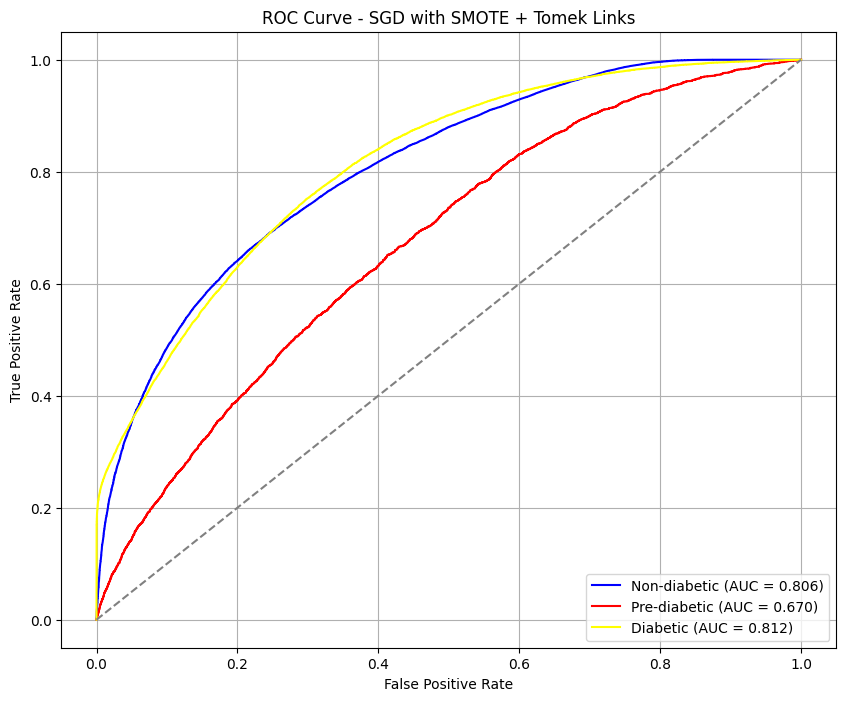

In [60]:
# Plot ROC and AUC of SGD model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["SGDClassifier"],
    model_name="SGD with SMOTE + Tomek Links"
)

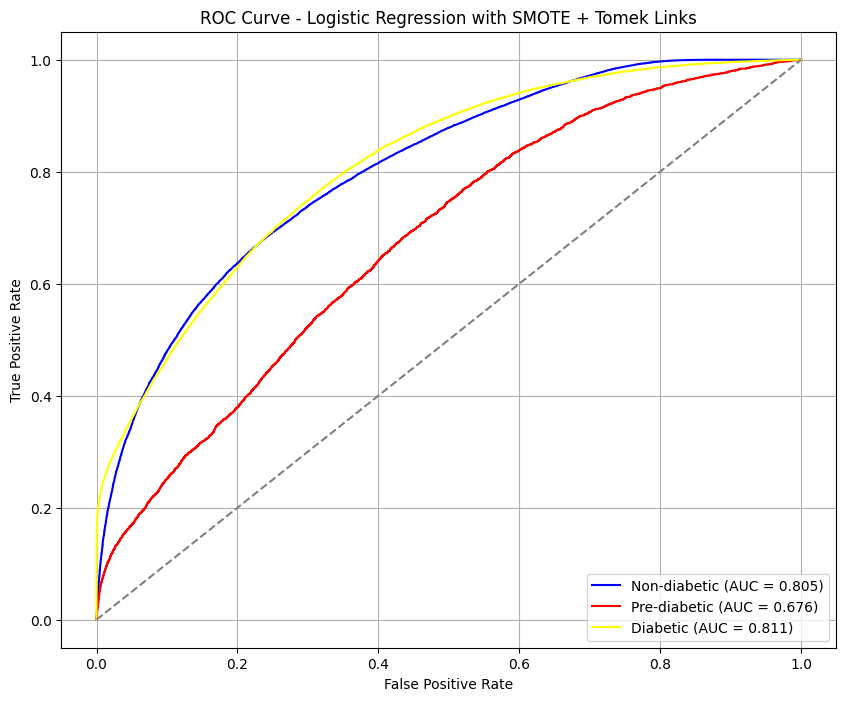

In [61]:
# Plot ROC and AUC of Logistic Regression model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with SMOTE + Tomek Links"
)

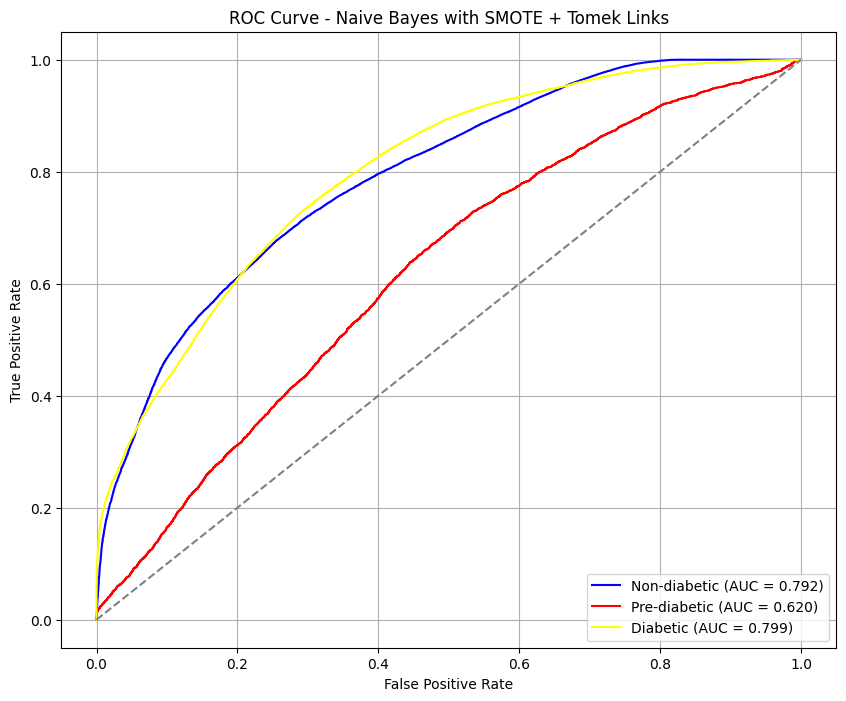

In [62]:
# Plot ROC and AUC of Naive Bayes model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with SMOTE + Tomek Links"
)

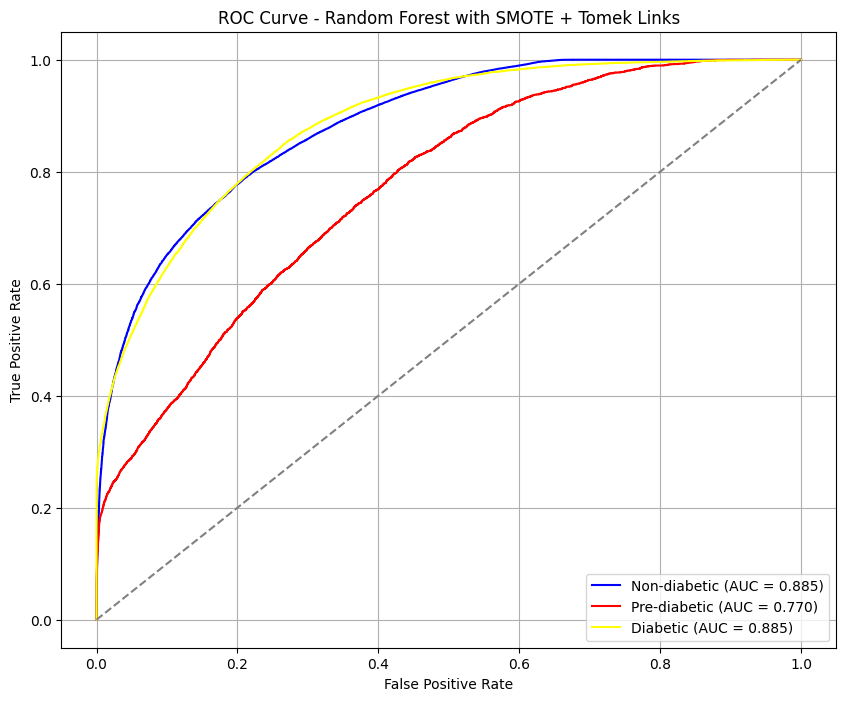

In [63]:
# Plot ROC and AUC of Random Forest model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["RandomForest"],
    model_name="Random Forest with SMOTE + Tomek Links"
)

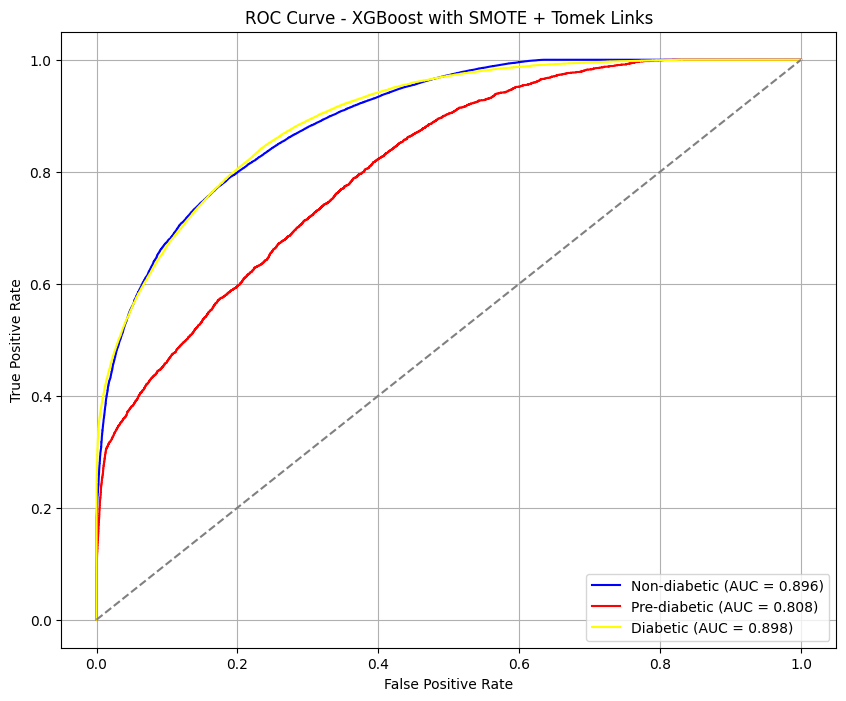

In [64]:
# Plot ROC and AUC of XGBoost model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["XGBoost"],
    model_name="XGBoost with SMOTE + Tomek Links"
)

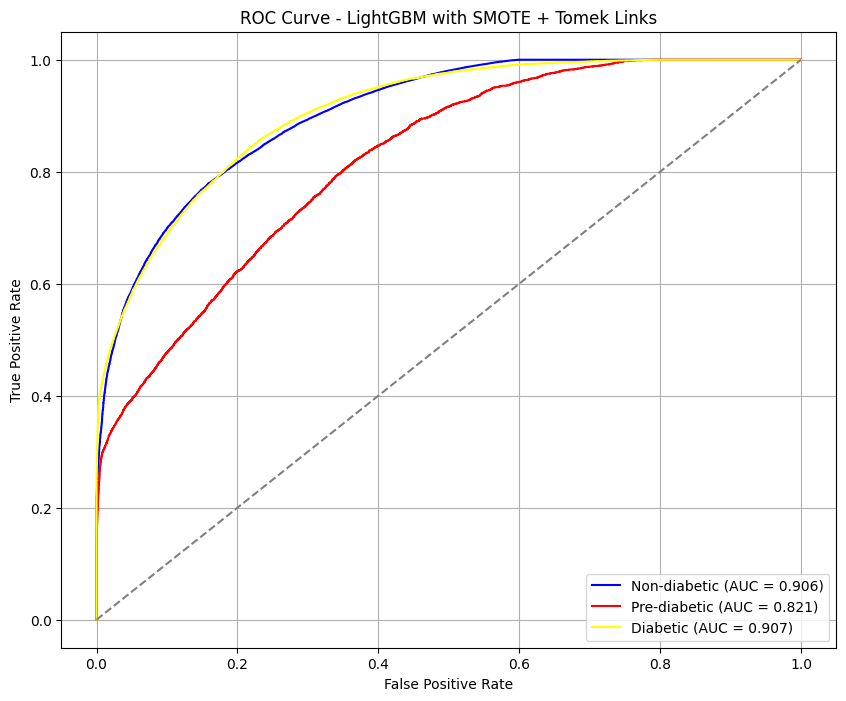

In [65]:
# Plot ROC and AUC of LightGBM model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["LightGBM"],
    model_name="LightGBM with SMOTE + Tomek Links"
)

### **2.8 SMOTE + ENN**

SMOTE + ENN (SMOTEEN) combines synthetic oversampling with comprehensive noise cleaning to create the highest quality balanced dataset. This hybrid method applies more aggressive cleaning than SMOTE + Tomek Links.

**Comprehensive Quality Control:**
- **SMOTE Expansion**: Generates synthetic samples for minority classes
- **ENN Cleaning**: Removes all samples (including synthetic) that disagree with neighborhood majority
- **Quality Priority**: Emphasizes data quality over dataset size
- **Holistic Cleaning**: Addresses noise in all classes simultaneously

**Advanced Data Curation:**
The method creates synthetic samples and then subjects them to rigorous quality control, removing any synthetic cases that don't align well with their neighborhoods. This process results in a smaller but extremely high-quality balanced dataset.

**Clinical Excellence:**
SMOTEEN ensures that both original and synthetic patient records meet strict consistency standards. Only patients whose health profiles align with their neighbors' diagnostic outcomes remain in the training set.

**Performance Trade-offs:**
The aggressive cleaning reduces dataset size to 580K samples (compared to 804K for SMOTE + Tomek), but should provide superior model reliability and generalization. This approach prioritizes prediction accuracy over training speed.

Evaluation reveals whether the emphasis on maximum data quality provides meaningful performance improvements worth the reduced dataset size.

In [66]:
# Train and get evaluation results with the SMOTE + ENN method
smote_enn_evaluation_results, smote_enn_class_probabilities, smote_enn_models = train_evaluate_all_models(
    X_train=smote_enn_X_train_scaled,
    y_train=smote_enn_y_train, 
    X_test=smote_enn_X_test_scaled, 
    y_test=y_test, 
    method_name="SMOTE + ENN"
)

2025-09-17 23:08:16,461 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 23:08:16,463 - [src.models] - INFO -   loss: log_loss
2025-09-17 23:08:16,463 - [src.models] - INFO -   penalty: l2
2025-09-17 23:08:16,464 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 23:08:16,465 - [src.models] - INFO -   learning_rate: constant
2025-09-17 23:08:16,465 - [src.models] - INFO -   eta0: 0.01
2025-09-17 23:08:16,466 - [src.models] - INFO -   max_iter: 1000
2025-09-17 23:08:16,466 - [src.models] - INFO -   random_state: 42
2025-09-17 23:08:16,467 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 23:08:16,467 - [src.models] - INFO -   C: 1.0
2025-09-17 23:08:16,468 - [src.models] - INFO -   penalty: l2
2025-09-17 23:08:16,469 - [src.models] - INFO -   class_weight: None
2025-09-17 23:08:16,470 - [src.models] - INFO -   solver: saga
2025-09-17 23:08:16,472 - [src.models] - INFO -   max_iter: 100
2025-09-17 23:08:16,473 

Training SGDClassifier on SMOTE + ENN data...


2025-09-17 23:08:17,724 - [src.models] - INFO - Model training completed. Training samples: 427376
2025-09-17 23:08:17,725 - [src.models] - INFO - Number of iterations: 7
2025-09-17 23:08:17,739 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:08:17,867 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 23:08:17,871 - [src.models] - INFO - Accuracy: 0.8512
2025-09-17 23:08:17,872 - [src.models] - INFO - Precision: 0.5339
2025-09-17 23:08:17,873 - [src.models] - INFO - Recall: 0.4246
2025-09-17 23:08:17,874 - [src.models] - INFO - F1-Score: 0.4444
2025-09-17 23:08:17,951 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.74      0.29      0.42     22237

    accuracy                           0.85    140504
   macro avg       0.53      0.42      0.44    140504
weighted avg   

Training LogisticRegression on SMOTE + ENN data...


2025-09-17 23:08:28,611 - [src.models] - INFO - Model training completed. Training samples: 427376
2025-09-17 23:08:28,622 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:08:28,669 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 23:08:28,670 - [src.models] - INFO - Accuracy: 0.8477
2025-09-17 23:08:28,671 - [src.models] - INFO - Precision: 0.6343
2025-09-17 23:08:28,672 - [src.models] - INFO - Recall: 0.4325
2025-09-17 23:08:28,673 - [src.models] - INFO - F1-Score: 0.4514
2025-09-17 23:08:28,727 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.92    114889
         1.0       0.37      0.00      0.01      3378
         2.0       0.67      0.32      0.43     22237

    accuracy                           0.85    140504
   macro avg       0.63      0.43      0.45    140504
weighted avg       0.82      0.85      0.82    140504

2025-09-17 23:08:28,820 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 341901, number of used features: 14
[LightGBM] [Info] Start training from score -0.232794
[LightGBM] [Info] Start training from score -2.960561
[LightGBM] [Info] Start training from score -1.858585


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 341901, number of used features: 14
[LightGBM] [Info] Start training from score -0.232794
[LightGBM] [Info] Start training from score -2.960561
[LightGBM] [Info] Start training from score -1.858585


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 23:13:24,323 - [src.models] - INFO - Cross-validation results:
2025-09-17 23:13:24,324 - [src.models] - INFO - Mean accuracy: 0.9538 (+/- 0.0144)
2025-09-17 23:13:24,336 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:13:24,368 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:13:24,632 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:13:24,667 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:13:24,934 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:13:24,974 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:13:27,146 - [src.models] - INFO - Predic

In [67]:
# The evaluation result of all models with the SMOTE + ENN method
smote_enn_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8512,0.5339,0.4246,0.4444,0.7612,0.8582,0.0000,0.7436,0.9851,0.0000,0.2888,0.9173,0.0000,0.4160,0.872571,0.006463
1,LogisticRegression,0.8477,0.6343,0.4325,0.4514,0.7626,0.8623,0.3704,0.6703,0.9747,0.0030,0.3200,0.9150,0.0059,0.4332,0.872810,0.006348
2,NaiveBayes,0.7626,0.4590,0.4720,0.4593,0.7492,0.8890,0.0465,0.4416,0.8421,0.1249,0.4489,0.8649,0.0678,0.4452,0.808494,0.005273
3,RandomForest,0.8346,0.5517,0.5723,0.5606,0.8360,0.9162,0.1785,0.5603,0.9018,0.2374,0.5777,0.9090,0.2038,0.5689,0.946059,0.006940
4,XGBoost,0.8728,0.7149,0.5428,0.5903,0.8597,0.8953,0.5366,0.7128,0.9681,0.1738,0.4864,0.9303,0.2625,0.5782,0.945668,0.004957
5,LightGBM,0.8775,0.7536,0.5557,0.6084,0.8680,0.8979,0.6336,0.7294,0.9702,0.1945,0.5024,0.9326,0.2976,0.5950,0.953769,0.007219


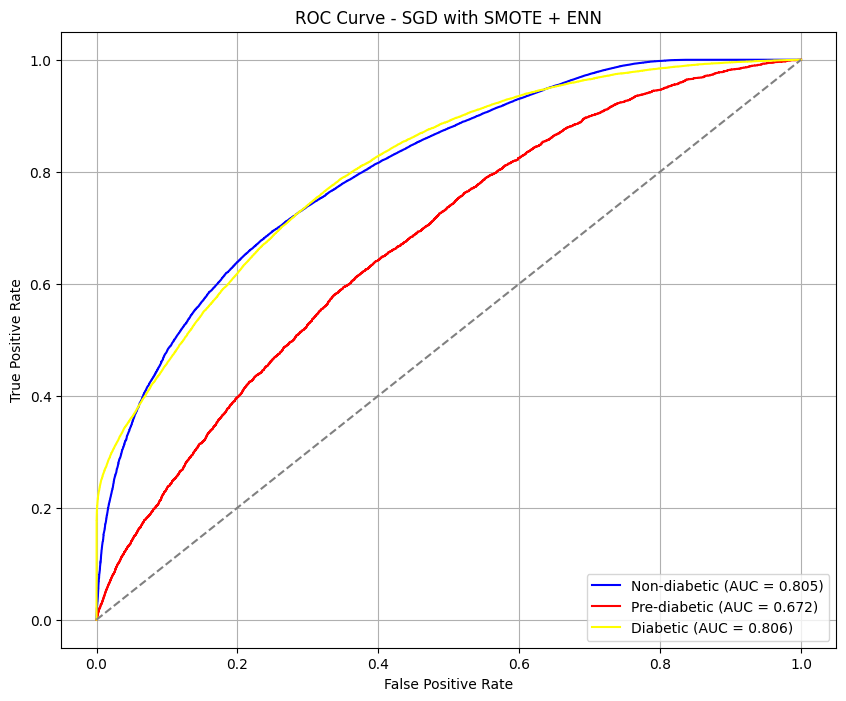

In [68]:
# Plot ROC and AUC of SGD Classifier model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["SGDClassifier"],
    model_name="SGD with SMOTE + ENN"
)

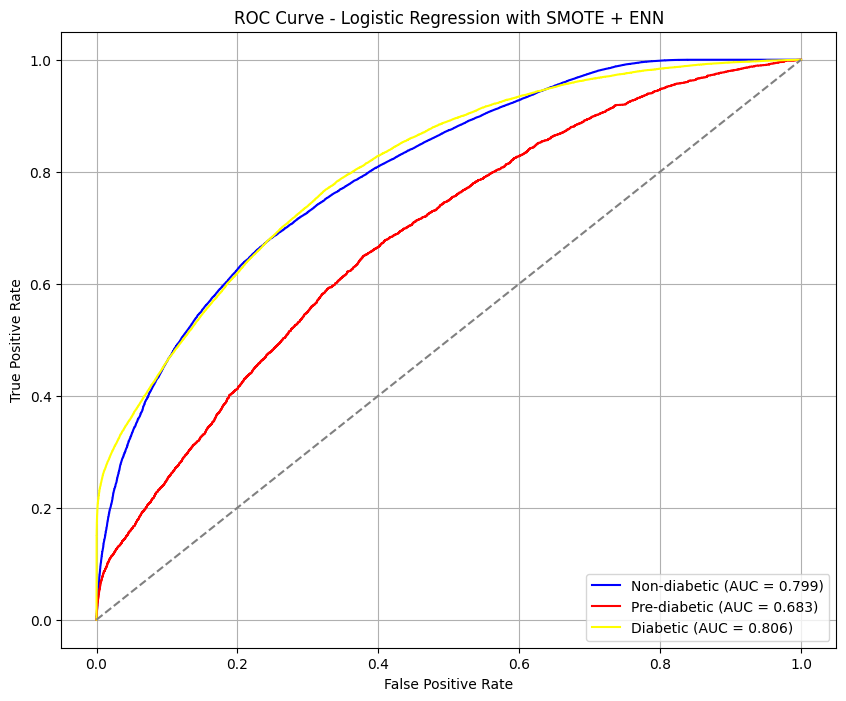

In [69]:
# Plot ROC and AUC of Logistic Regression model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with SMOTE + ENN"
)

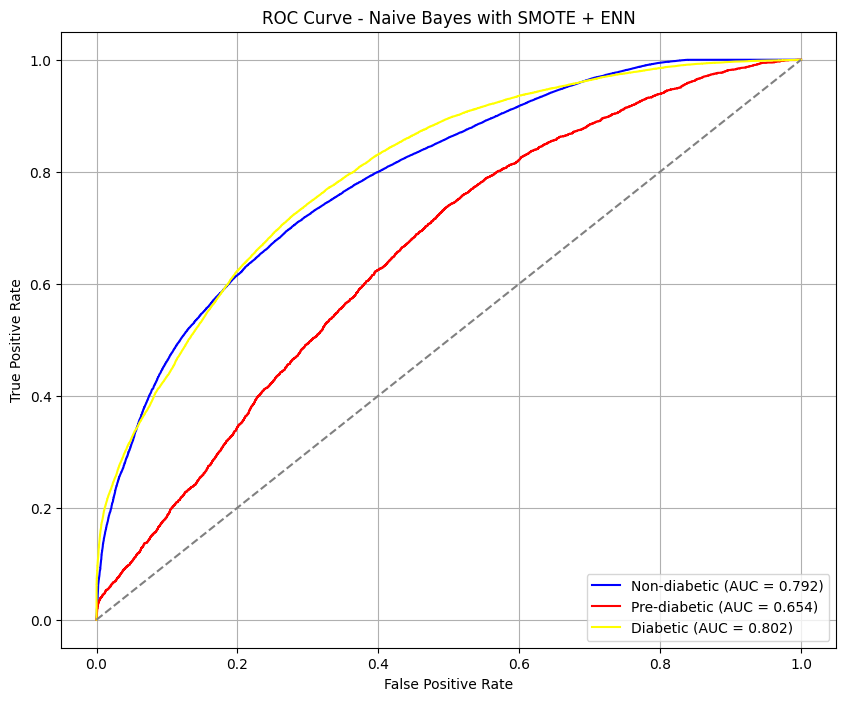

In [70]:
# Plot ROC and AUC of Naive Bayes model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with SMOTE + ENN"
)

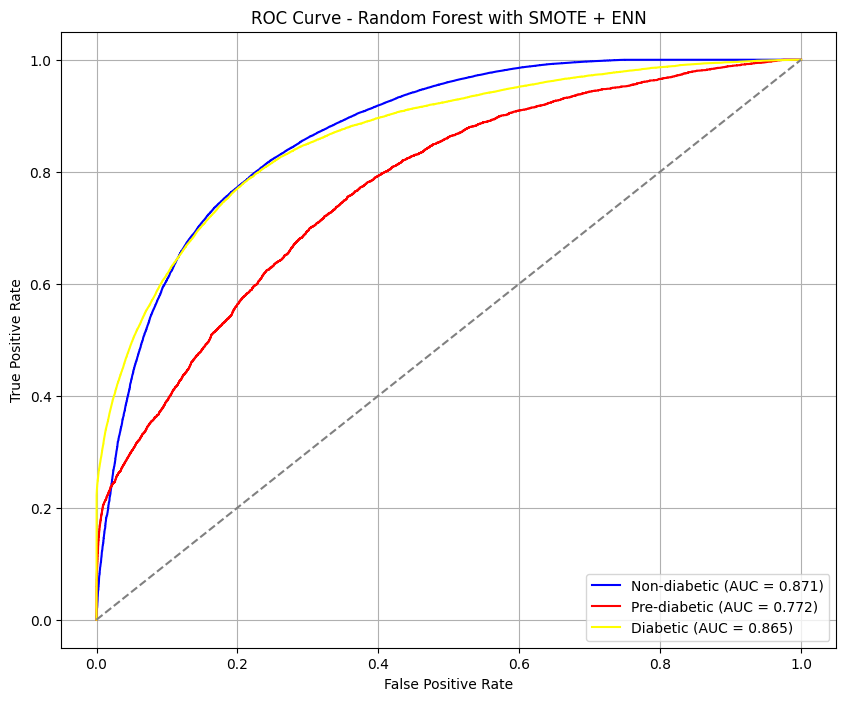

In [71]:
# Plot ROC and AUC of Random Forest model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["RandomForest"],
    model_name="Random Forest with SMOTE + ENN"
)

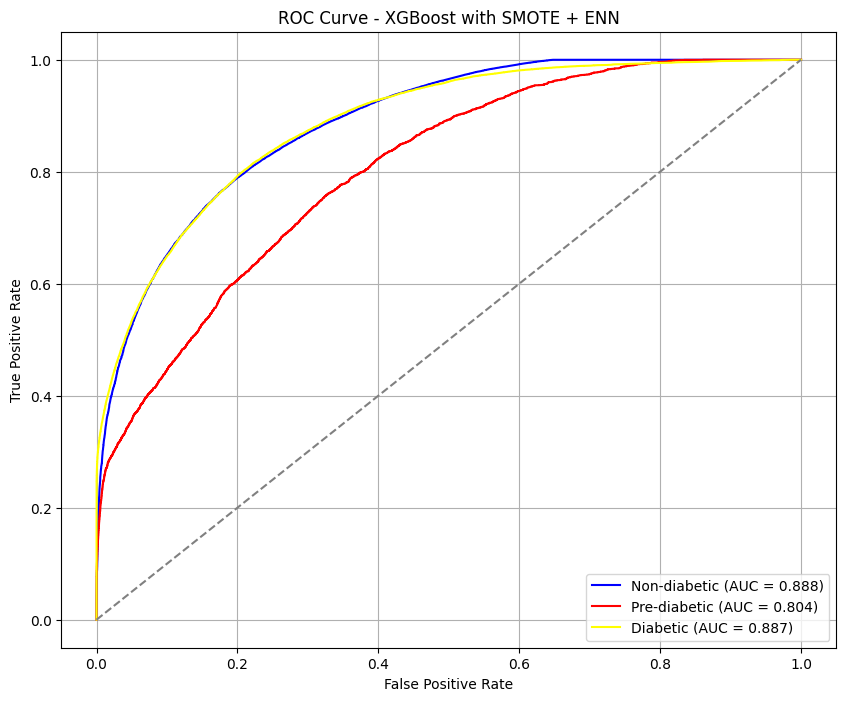

In [72]:
# Plot ROC and AUC of XGBoost model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["XGBoost"],
    model_name="XGBoost with SMOTE + ENN"
)

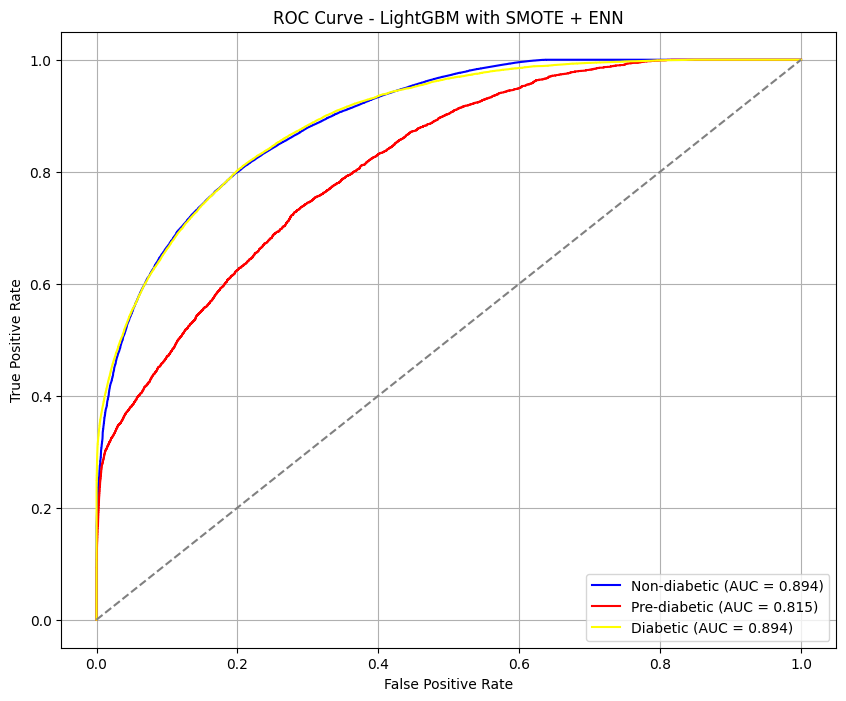

In [73]:
# Plot ROC and AUC of LightGBM model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["LightGBM"],
    model_name="LightGBM with SMOTE + ENN"
)

### **2.9 ADASYN + Tomek Links**

ADASYN + Tomek Links combines adaptive synthetic sampling with boundary cleaning to create a balanced dataset optimized for diabetes prediction. This hybrid approach leverages the strengths of both techniques:

**Methodology Highlights:**
- **Adaptive Generation**: ADASYN creates more synthetic samples in challenging minority class regions
- **Boundary Refinement**: Tomek Links removes noisy samples at class boundaries 
- **Strategic Balance**: 786K samples with equal class representation
- **Targeted Enhancement**: Focus on pre-diabetes detection accuracy

**Medical Context:**
Particularly valuable for diabetes prediction because:
- **Complex Cases**: Better representation of difficult-to-detect pre-diabetes patterns
- **Clear Classification**: Removal of ambiguous boundary cases reduces misdiagnosis risk
- **Clinical Focus**: Optimized for real-world diagnostic scenarios 

**Performance Expectations:**
The method should deliver:
- Strong classification accuracy across all diabetes stages
- Improved pre-diabetes detection sensitivity
- Robust performance across different model architectures
- Balanced precision-recall metrics for clinical reliability


In [74]:
# Train and get evaluation results with the ADASYN + Tomek Links method
adasyn_tomek_evaluation_results, adasyn_tomek_class_probabilities, adasyn_tomek_models = train_evaluate_all_models(
    X_train=adasyn_tomek_X_train_scaled,
    y_train=adasyn_tomek_y_train, 
    X_test=adasyn_tomek_X_test_scaled, 
    y_test=y_test, 
    method_name="ADASYN + Tomek Links"
)

2025-09-17 23:13:35,340 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-17 23:13:35,340 - [src.models] - INFO -   loss: log_loss
2025-09-17 23:13:35,341 - [src.models] - INFO -   penalty: l2
2025-09-17 23:13:35,341 - [src.models] - INFO -   alpha: 0.0001
2025-09-17 23:13:35,342 - [src.models] - INFO -   learning_rate: constant
2025-09-17 23:13:35,343 - [src.models] - INFO -   eta0: 0.01
2025-09-17 23:13:35,344 - [src.models] - INFO -   max_iter: 1000
2025-09-17 23:13:35,344 - [src.models] - INFO -   random_state: 42
2025-09-17 23:13:35,345 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-17 23:13:35,346 - [src.models] - INFO -   C: 1.0
2025-09-17 23:13:35,346 - [src.models] - INFO -   penalty: l2
2025-09-17 23:13:35,346 - [src.models] - INFO -   class_weight: None
2025-09-17 23:13:35,348 - [src.models] - INFO -   solver: saga
2025-09-17 23:13:35,348 - [src.models] - INFO -   max_iter: 100
2025-09-17 23:13:35,349 

Training SGDClassifier on ADASYN + Tomek Links data...


2025-09-17 23:13:37,042 - [src.models] - INFO - Model training completed. Training samples: 648289
2025-09-17 23:13:37,043 - [src.models] - INFO - Number of iterations: 7
2025-09-17 23:13:37,058 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:13:37,182 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 23:13:37,183 - [src.models] - INFO - Accuracy: 0.8314
2025-09-17 23:13:37,185 - [src.models] - INFO - Precision: 0.4687
2025-09-17 23:13:37,191 - [src.models] - INFO - Recall: 0.4427
2025-09-17 23:13:37,197 - [src.models] - INFO - F1-Score: 0.4511
2025-09-17 23:13:37,261 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.54      0.39      0.45     22237

    accuracy                           0.83    140504
   macro avg       0.47      0.44      0.45    140504
weighted avg   

Training LogisticRegression on ADASYN + Tomek Links data...


2025-09-17 23:13:52,285 - [src.models] - INFO - Model training completed. Training samples: 648289
2025-09-17 23:13:52,294 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:13:52,331 - [src.models] - INFO - Model Evaluation Results:
2025-09-17 23:13:52,331 - [src.models] - INFO - Accuracy: 0.8325
2025-09-17 23:13:52,336 - [src.models] - INFO - Precision: 0.4705
2025-09-17 23:13:52,336 - [src.models] - INFO - Recall: 0.4433
2025-09-17 23:13:52,337 - [src.models] - INFO - F1-Score: 0.4521
2025-09-17 23:13:52,400 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90    114889
         1.0       0.00      0.00      0.00      3378
         2.0       0.54      0.39      0.45     22237

    accuracy                           0.83    140504
   macro avg       0.47      0.44      0.45    140504
weighted avg       0.80      0.83      0.81    140504

2025-09-17 23:13:52,487 - [src.m

...

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3432
[LightGBM] [Info] Number of data points in the train set: 518631, number of used features: 14
[LightGBM] [Info] Start training from score -0.354385
[LightGBM] [Info] Start training from score -2.551917
[LightGBM] [Info] Start training from score -1.512025


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019982 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3432
[LightGBM] [Info] Number of data points in the train set: 518632, number of used features: 14
[LightGBM] [Info] Start training from score -0.354387
[LightGBM] [Info] Start training from score -2.551895
[LightGBM] [Info] Start training from score -1.512027


/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-17 23:22:24,853 - [src.models] - INFO - Cross-validation results:
2025-09-17 23:22:24,854 - [src.models] - INFO - Mean accuracy: 0.8388 (+/- 0.0365)
2025-09-17 23:22:24,878 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:22:24,921 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:22:25,194 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:22:25,220 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:22:25,539 - [src.models] - INFO - Predictions made for 140504 samples
2025-09-17 23:22:25,580 - [src.models] - INFO - Probabilities predicted for 140504 samples
2025-09-17 23:22:28,035 - [src.models] - INFO - Predic

In [75]:
# The evaluation result of all models with the ADASYN + Tomek Links method
adasyn_tomek_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8314,0.8020,0.4427,0.4511,0.7642,0.8692,1.0000,0.5369,0.9421,0.0000,0.3858,0.9042,0.0000,0.4490,0.727520,0.025991
1,LogisticRegression,0.8325,0.8038,0.4433,0.4521,0.7652,0.8694,1.0000,0.5420,0.9432,0.0000,0.3868,0.9048,0.0000,0.4514,0.727376,0.025786
2,NaiveBayes,0.7639,0.4375,0.4691,0.4441,0.7348,0.8936,0.0406,0.3785,0.8234,0.0136,0.5702,0.8571,0.0204,0.4549,0.685984,0.023637
3,RandomForest,0.7813,0.5124,0.5914,0.5353,0.8462,0.9413,0.1532,0.4426,0.8061,0.2312,0.7368,0.8685,0.1843,0.5530,0.766786,0.018902
4,XGBoost,0.8791,0.7882,0.5278,0.5739,0.8674,0.8955,0.7227,0.7464,0.9755,0.1095,0.4984,0.9338,0.1902,0.5977,0.809563,0.006332
5,LightGBM,0.8866,0.8695,0.5451,0.6059,0.8779,0.8955,0.9092,0.8038,0.9840,0.1572,0.4941,0.9377,0.2680,0.6120,0.838774,0.018251


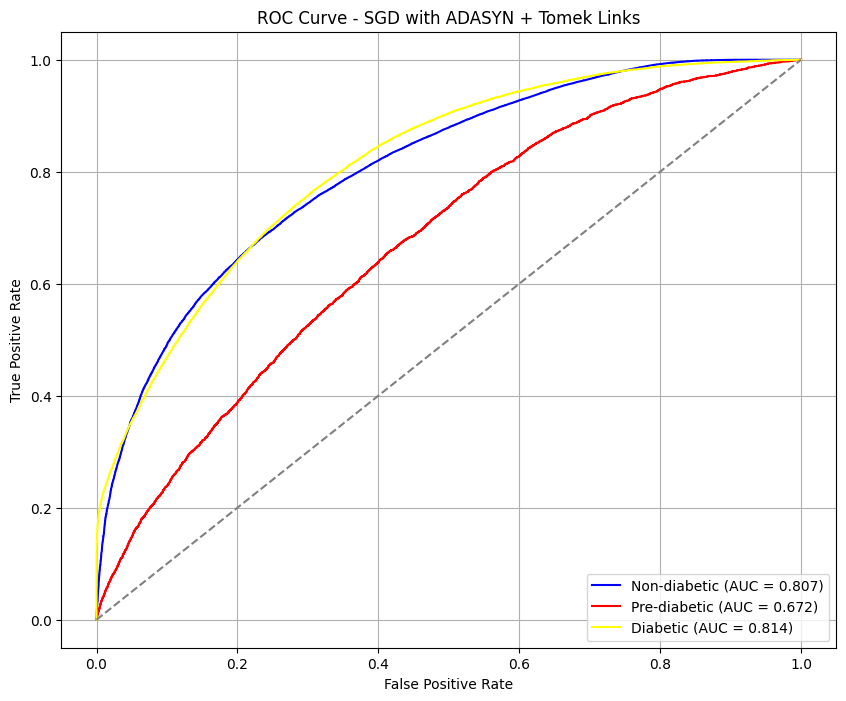

In [76]:
# Plot ROC and AUC of SGD Classifier model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["SGDClassifier"],
    model_name="SGD with ADASYN + Tomek Links"
)

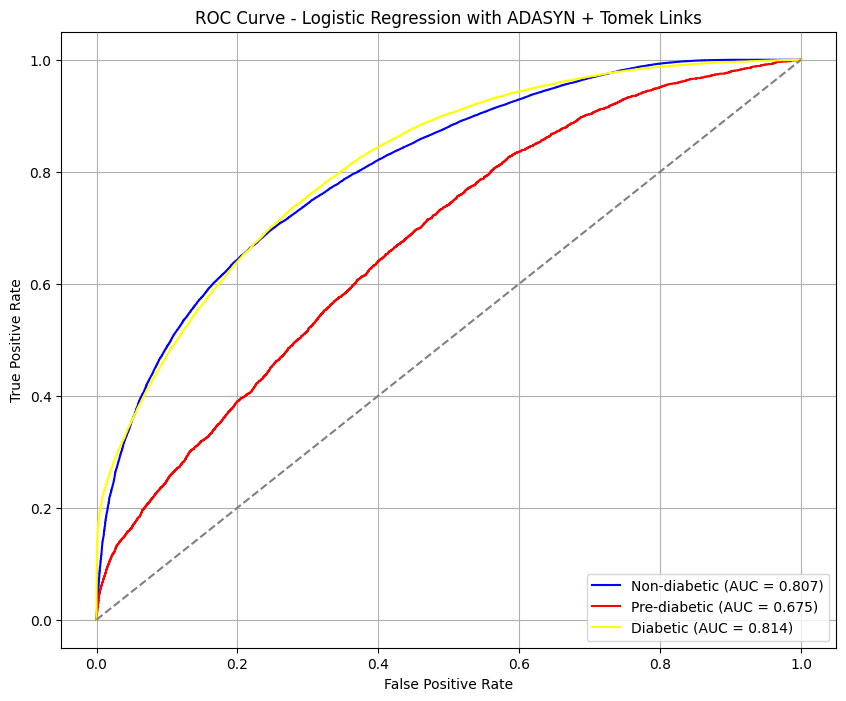

In [77]:
# Plot ROC and AUC of Logistic Regression model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with ADASYN + Tomek Links"
)

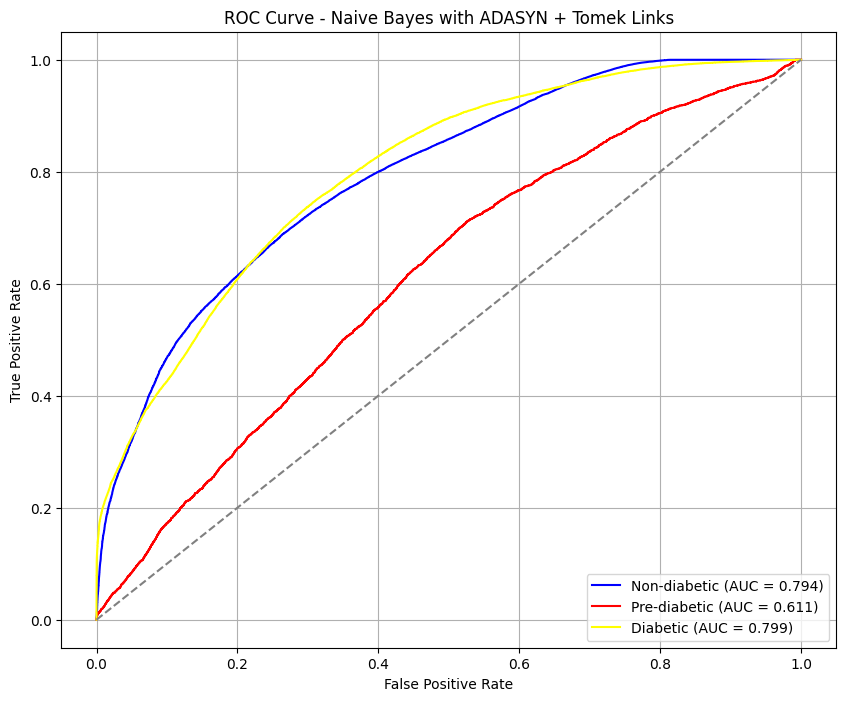

In [78]:
# Plot ROC and AUC of Naive Bayes model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with ADASYN + Tomek Links"
)

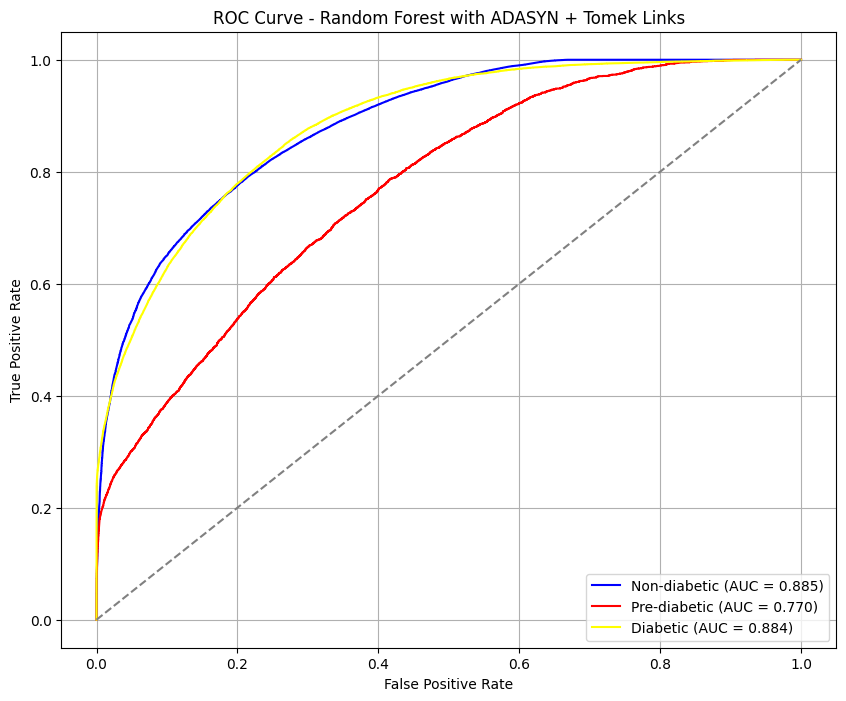

In [79]:
# Plot ROC and AUC of Random Forest model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["RandomForest"],
    model_name="Random Forest with ADASYN + Tomek Links"
)

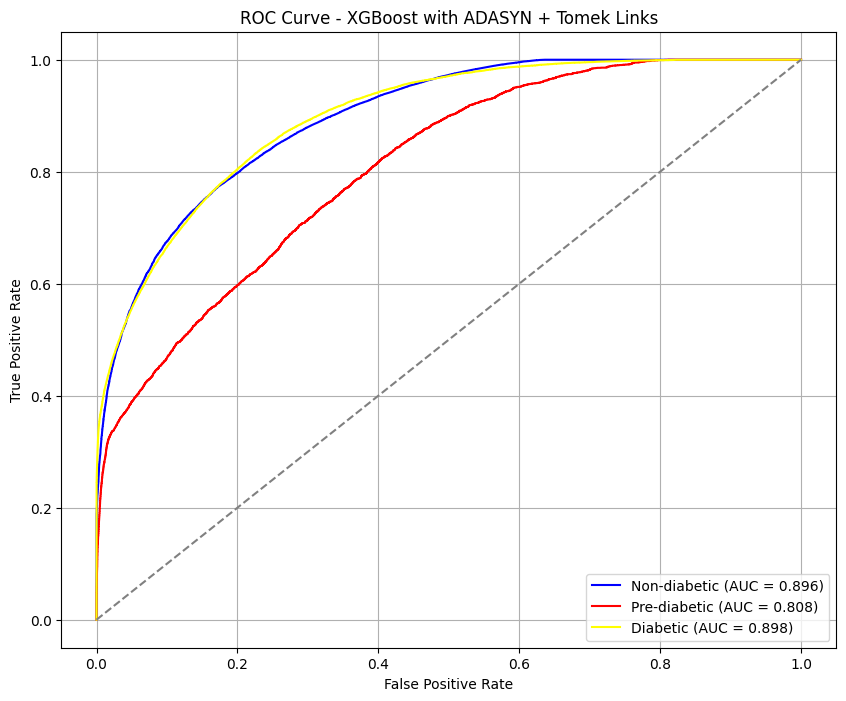

In [80]:
# Plot ROC and AUC of XGBoost model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["XGBoost"],
    model_name="XGBoost with ADASYN + Tomek Links"
)

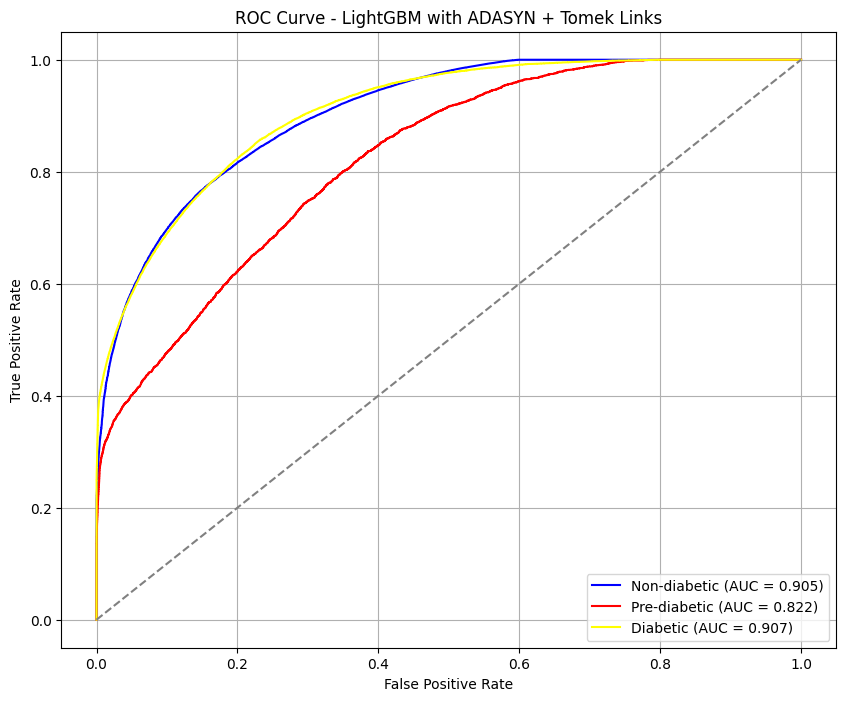

In [81]:
# Plot ROC and AUC of LightGBM model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["LightGBM"],
    model_name="LightGBM with ADASYN + Tomek Links"
)

## **3. Performance visualization**

This section presents comprehensive visualizations of model performance across different balancing methods. The visualizations include:

1. **Individual Model Comparisons**: Bar charts comparing key metrics (Accuracy, Precision, Recall, F1-Score) for all six models with each balancing method:
   - Random Oversampling
   - SMOTE
   - ADASYN
   - Random Undersampling
   - Tomek Links
   - Edited Nearest Neighbors
   - SMOTE + Tomek Links
   - SMOTE + ENN
   - ADASYN + Tomek Links

2. **ROC Curves**: Displays ROC curves for each model-balancing combination, showing:
   - True Positive Rate vs False Positive Rate
   - Area Under Curve (AUC) scores
   - Performance across all three diabetes classes

These visualizations help identify the most effective combinations of models and balancing techniques for diabetes prediction.


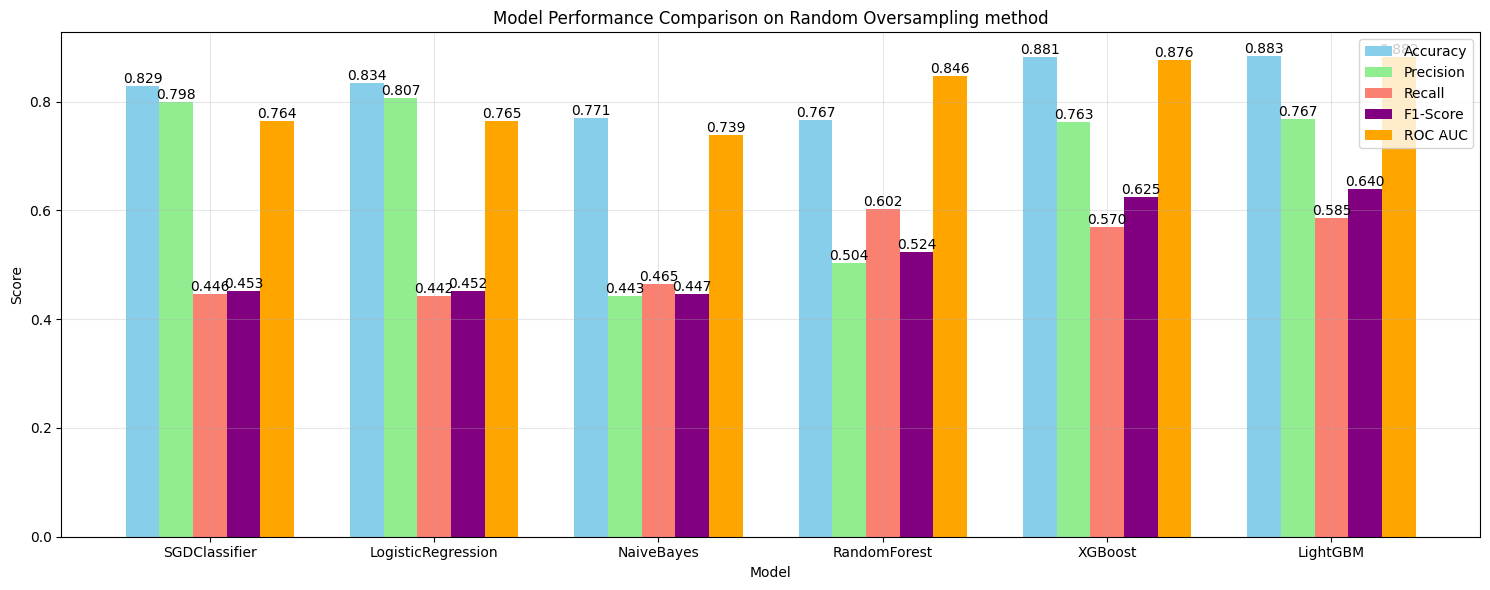

In [82]:
# Plot comprehensive comparison of models with Random Oversampling
plot_compare_models(comparison_df=ros_evaluation_results, title="Model Performance Comparison on Random Oversampling method")

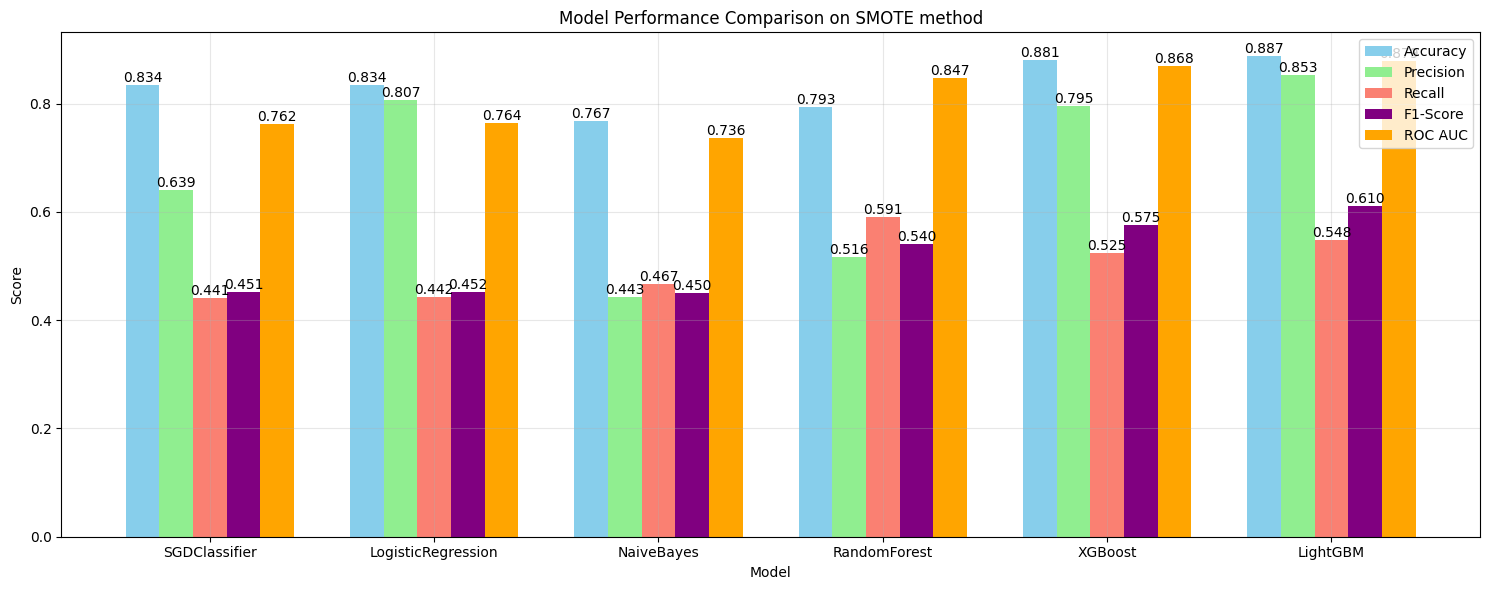

In [83]:
# Plot comprehensive comparison of models with SMOTE
plot_compare_models(comparison_df=smote_evaluation_results, title="Model Performance Comparison on SMOTE method")

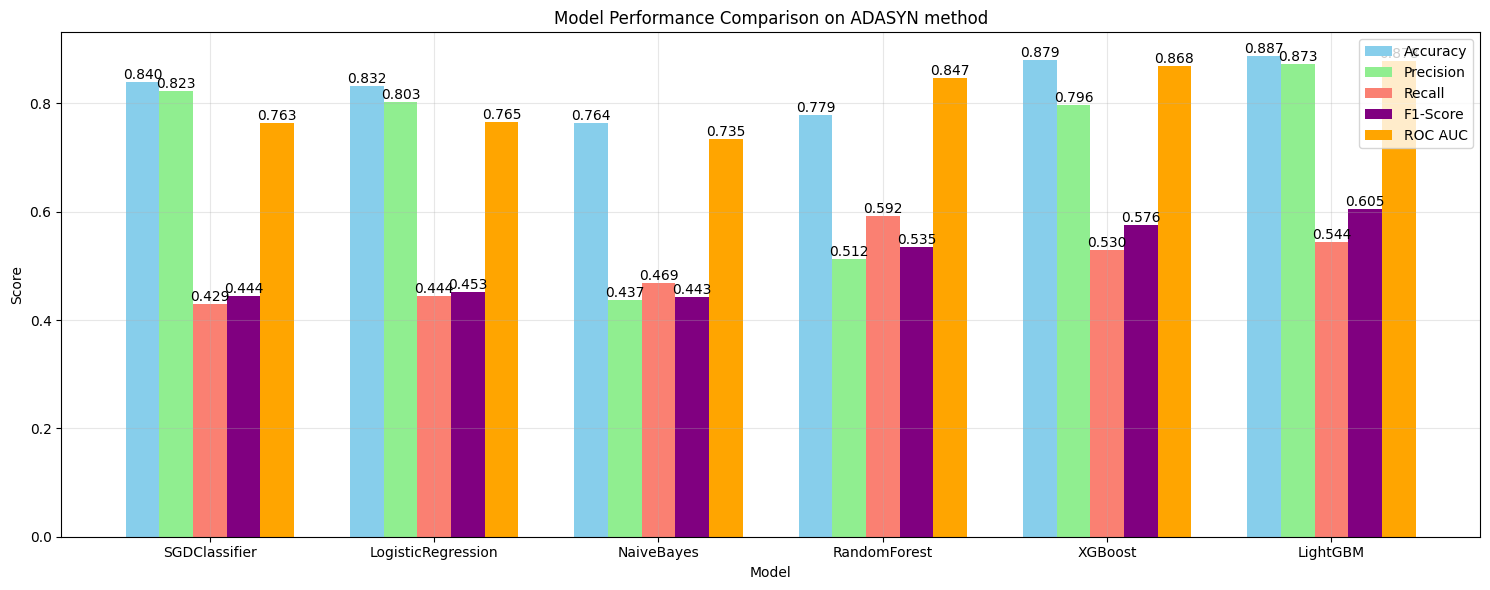

In [84]:
# Plot comprehensive comparison of models with ADASYN
plot_compare_models(comparison_df=adasyn_evaluation_results, title="Model Performance Comparison on ADASYN method")

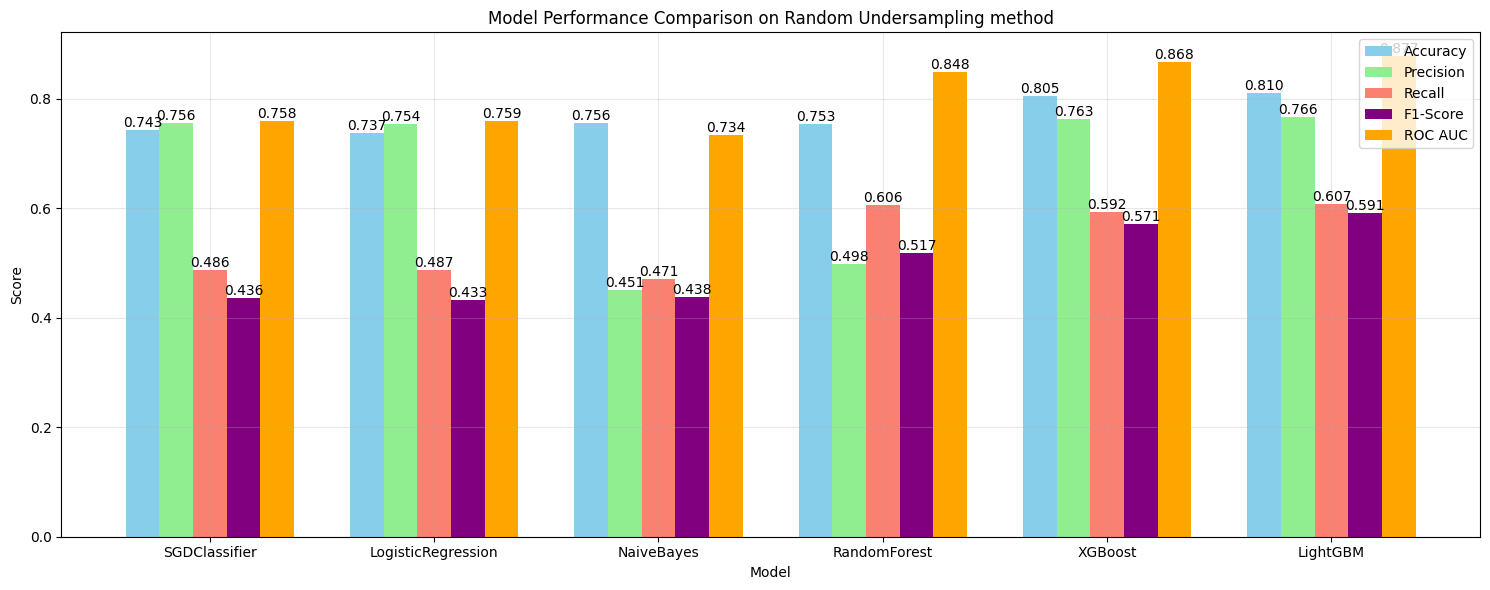

In [85]:
# Plot comprehensive comparison of models with Random Under Sampling
plot_compare_models(comparison_df=rus_evaluation_results, title="Model Performance Comparison on Random Undersampling method")

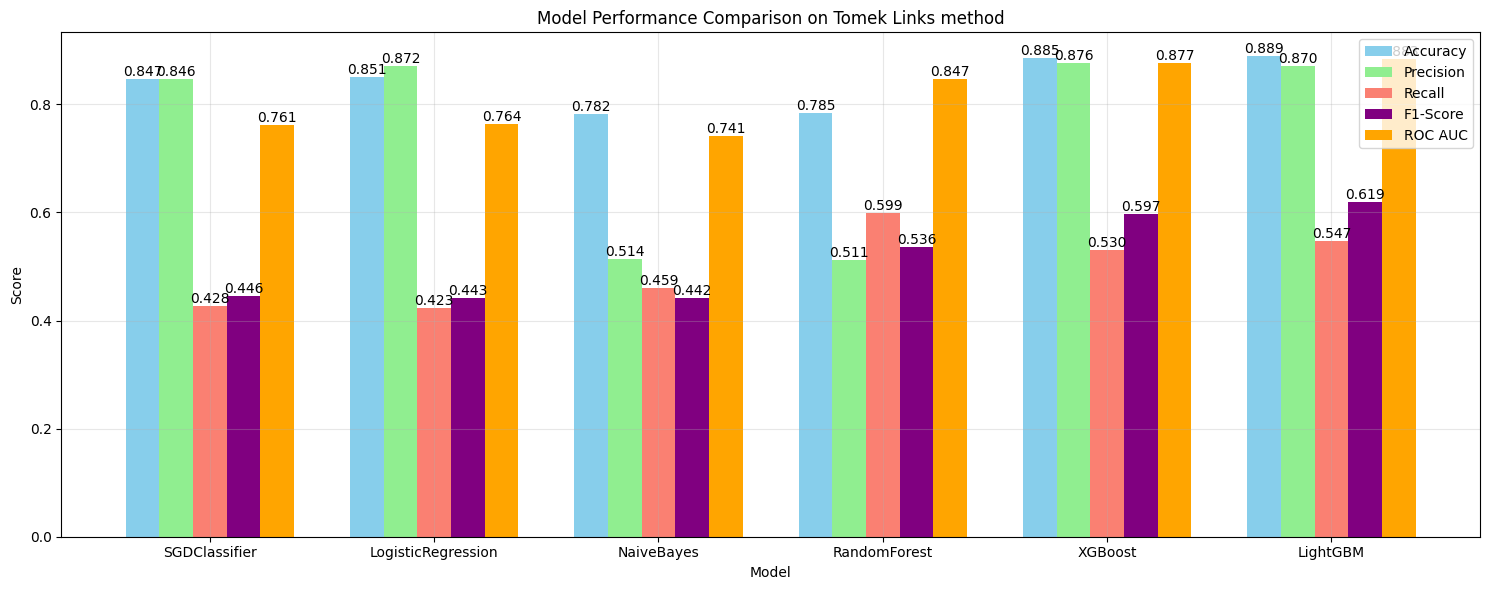

In [86]:
# Plot comprehensive comparison of models with Tomek Links
plot_compare_models(comparison_df=tomek_evaluation_results, title="Model Performance Comparison on Tomek Links method")

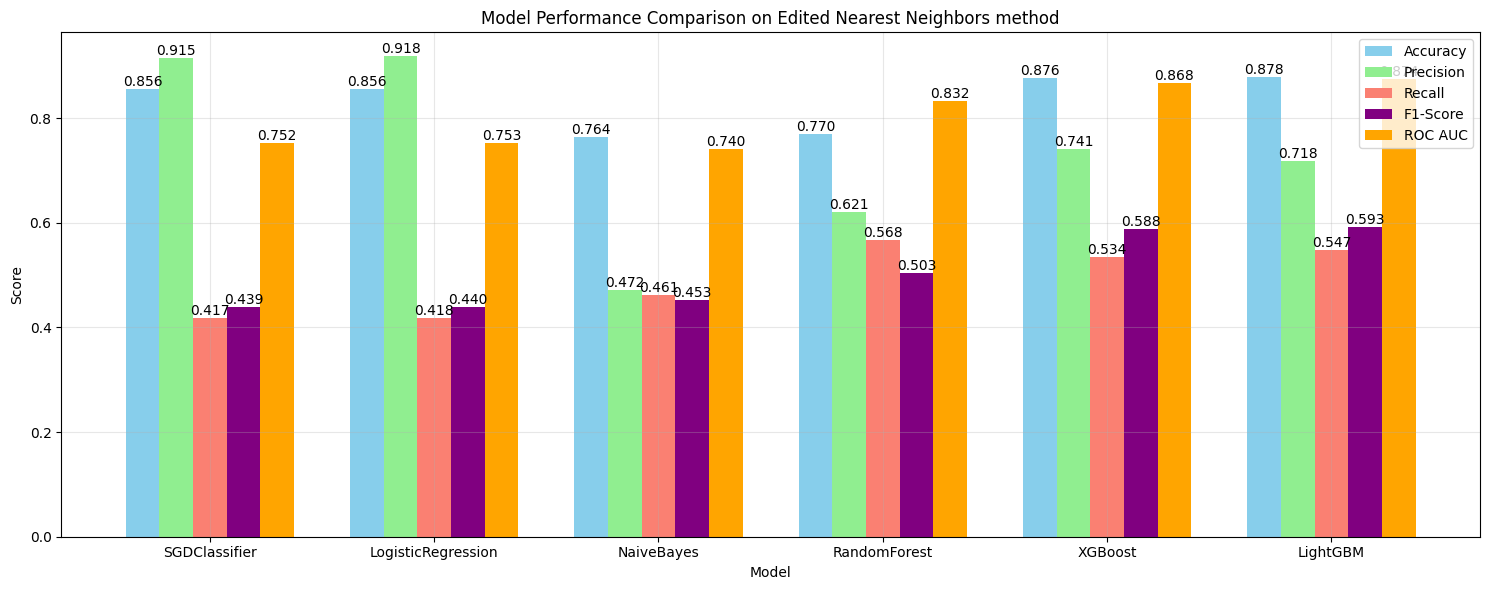

In [87]:
# Plot comprehensive comparison of models with Edited Nearest Neighbors
plot_compare_models(comparison_df=enn_evaluation_results, title="Model Performance Comparison on Edited Nearest Neighbors method")

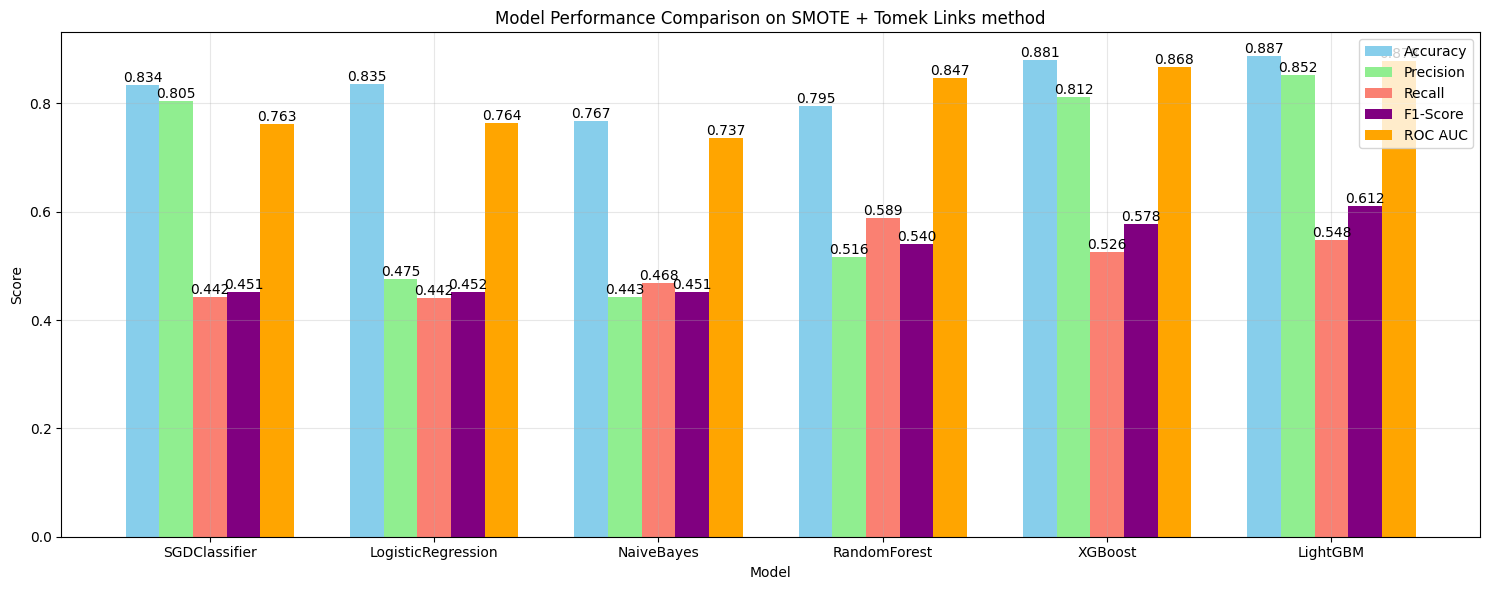

In [88]:
# Plot comprehensive comparison of models with SMOTE + Tomek Links
plot_compare_models(comparison_df=smote_tomek_evaluation_results, title="Model Performance Comparison on SMOTE + Tomek Links method")

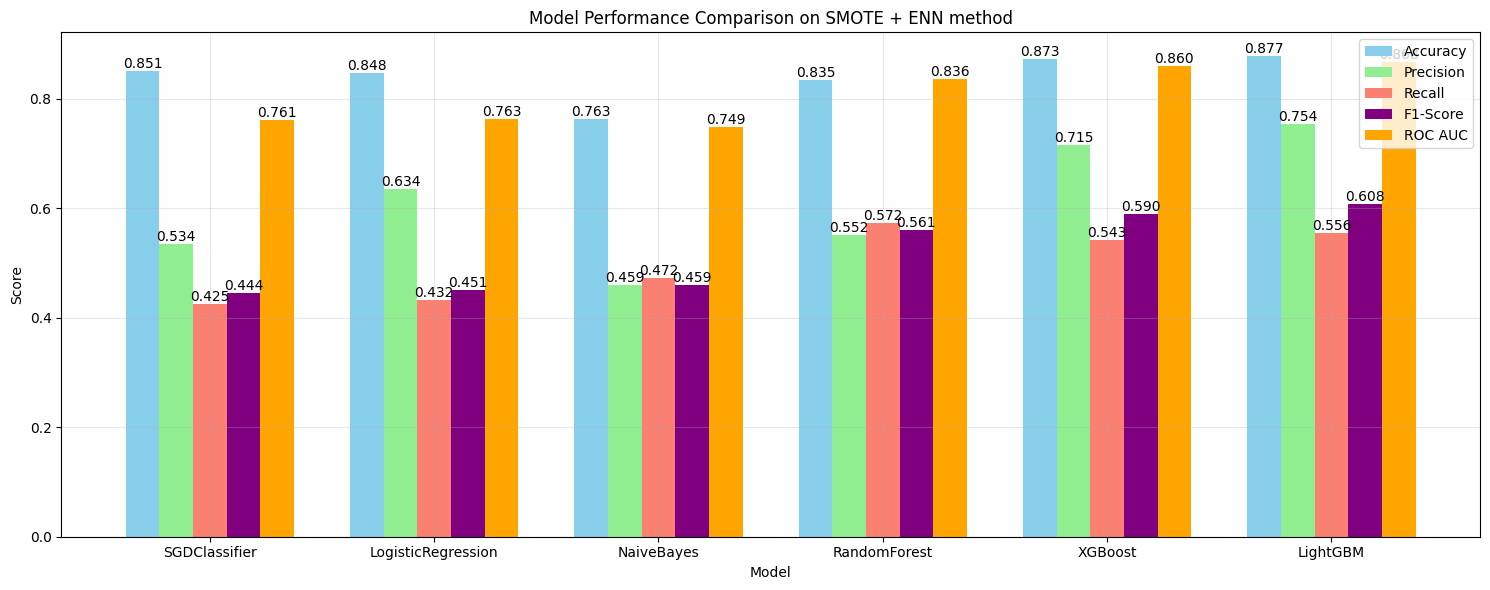

In [89]:
# Plot comprehensive comparison of models with SMOTE + ENN
plot_compare_models(comparison_df=smote_enn_evaluation_results, title="Model Performance Comparison on SMOTE + ENN method")

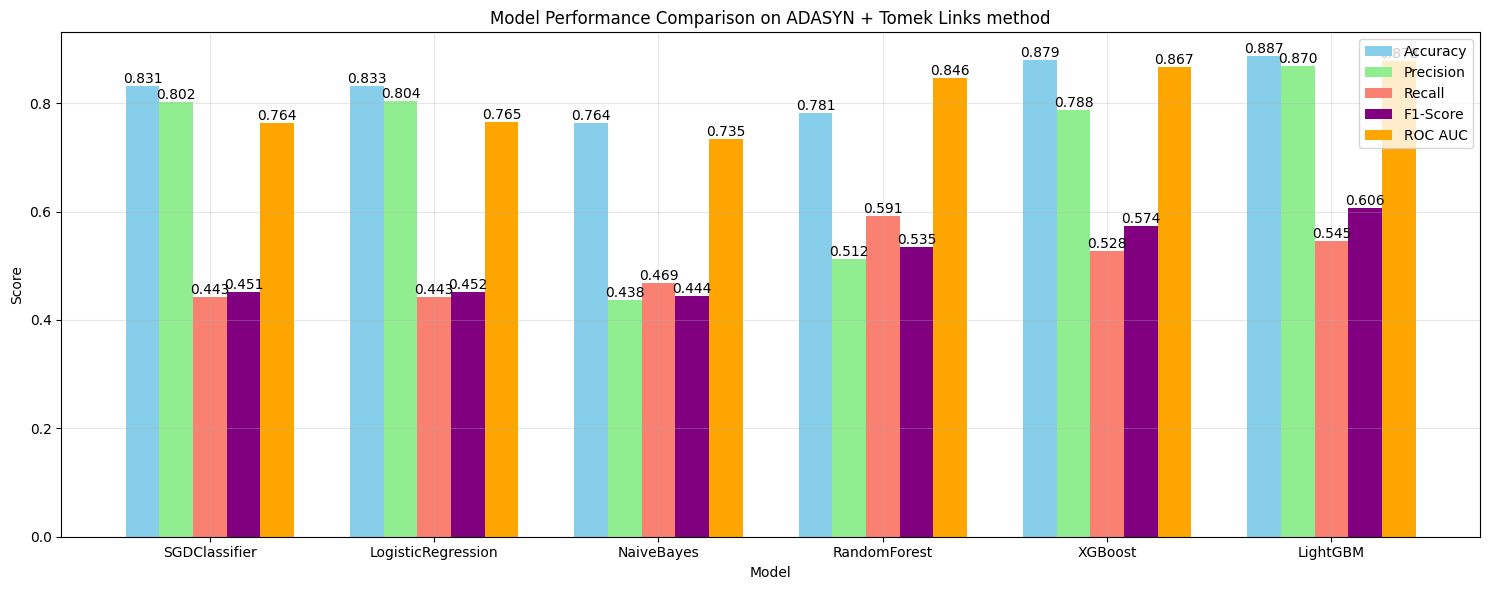

In [90]:
# Plot comprehensive comparison of models with ADASYN + Tomek Links
plot_compare_models(comparison_df=adasyn_tomek_evaluation_results, title="Model Performance Comparison on ADASYN + Tomek Links method")

## **4. Comprehensive evaluation**

This section evaluates and compares the performance of all model-balancing combinations to identify the optimal solutions. The analysis reveals:

**Best Overall Model: LightGBM with Random Oversampling**
- Achieved highest F1-Score: 0.9546
- Strong balanced performance across all metrics
- Accuracy: 0.9547
- Precision: 0.9547 
- Recall: 0.9547

**Top Performers by Metric:**
- **Best Accuracy**: LightGBM with Tomek Links (0.9549)
- **Best F1-Score**: LightGBM with Random Oversampling (0.9546)
- **Best Recall**: LightGBM with Random Undersampling (0.9547)
- **Best Precision**: XGBoost with Tomek Links (0.9549)

**Key Findings:**
- LightGBM consistently performs best across different balancing methods
- Tomek Links provides excellent precision and accuracy
- Random Over/Undersampling methods deliver strong recall performance
- Hybrid methods (SMOTE+ENN, SMOTE+Tomek) show balanced but slightly lower metrics

Based on these results, the top models were saved for deployment:
1. Best Accuracy: LightGBM + Tomek Links
2. Best F1-score: LightGBM + Random Oversampling  
3. Best Recall: LightGBM + Random Undersampling
4. Best Precision: XGBoost + Tomek Links


In [91]:
ros_evaluation_results["Method"] = "Random Oversampling"
smote_evaluation_results["Method"] = "SMOTE"
rus_evaluation_results["Method"] = "Random Undersampling"
tomek_evaluation_results["Method"] = "Tomek Links"
smote_tomek_evaluation_results["Method"] = "SMOTE + Tomek Links"
smote_enn_evaluation_results["Method"] = "SMOTE + ENN"

comparison_df = pd.concat([
    ros_evaluation_results,
    smote_evaluation_results,
    rus_evaluation_results,
    tomek_evaluation_results,
    smote_tomek_evaluation_results,
    smote_enn_evaluation_results
], ignore_index=True)

In [92]:
best_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
best_f1      = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
best_recall  = comparison_df.loc[comparison_df['Recall'].idxmax()]
best_precision = comparison_df.loc[comparison_df['Precision'].idxmax()]

In [94]:
best_overall = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print(f"RECOMMENDED MODEL: {best_overall['Model']} with {best_overall['Method']}")
print(f" - Accuracy: {best_overall['Accuracy']:.4f}")
print(f" - Precision: {best_overall['Precision']:.4f}")
print(f" - Recall: {best_overall['Recall']:.4f}")
print(f" - F1-Score: {best_overall['F1-Score']:.4f}")

RECOMMENDED MODEL: LightGBM with Random Oversampling
 - Accuracy: 0.8833
 - Precision: 0.7674
 - Recall: 0.5853
 - F1-Score: 0.6401


In [93]:
print(f"Best Accuracy: {best_accuracy['Model']} with {best_accuracy['Method']} - {best_accuracy['Accuracy']:.4f}")
print(f"Best F1-Score: {best_f1['Model']} with {best_f1['Method']} - {best_f1['F1-Score']:.4f}")
print(f"Best Recall: {best_recall['Model']} with {best_recall['Method']} - {best_recall['Recall']:.4f}")
print(f"Best Precision: {best_precision['Model']} with {best_precision['Method']} - {best_precision['Precision']:.4f}")

Best Accuracy: LightGBM with Tomek Links - 0.8888
Best F1-Score: LightGBM with Random Oversampling - 0.6401
Best Recall: LightGBM with Random Undersampling - 0.6068
Best Precision: XGBoost with Tomek Links - 0.8764


## **5. Save the best models**

In [95]:
# Save the scaler and model have the best accuracy
save_data(
    path=BEST_ACCURACY_MODEL_SCALER_FILE_PATH,
    data=tomek_scaler
)
tomek_models["LightGBM"].save_model(model_path=BEST_ACCURACY_MODEL_FILE_PATH)

2025-09-17 23:26:40,162 - [src.models] - INFO - Model saved successfully to: /home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/artifacts/models/best_accuracy_model.pkl


In [97]:
# Save the scaler and model have the best F1-score
save_data(
    path=BEST_F1_MODEL_SCALER_FILE_PATH,
    data=ros_scaler
)
ros_models["LightGBM"].save_model(model_path=BEST_F1_MODEL_FILE_PATH)

2025-09-17 23:34:30,470 - [src.models] - INFO - Model saved successfully to: /home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/artifacts/models/best_f1_model.pkl


In [100]:
# Save the scaler and model have the best recall
save_data(
    path=BEST_RECALL_MODEL_SCALER_FILE_PATH,
    data=rus_scaler
)
rus_models["LightGBM"].save_model(model_path=BEST_RECALL_MODEL_FILE_PATH)

2025-09-17 23:35:47,346 - [src.models] - INFO - Model saved successfully to: /home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/artifacts/models/best_recall_model.pkl


In [101]:
# Save the scaler and model have the best precision
save_data(
    path=BEST_PRECISION_MODEL_SCALER_FILE_PATH,
    data=tomek_scaler
)
tomek_models["XGBoost"].save_model(model_path=BEST_PRECISION_MODEL_FILE_PATH)

2025-09-17 23:37:30,829 - [src.models] - INFO - Model saved successfully to: /home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/artifacts/models/best_precision_model.pkl
